# Notebook 5 - AC adaptation

This notebook translates city-level AC penetration and electricity projections into gridded adaptation scenarios, quantifies their mortality benefits, and prepares the AC inputs reused later in the EWS, vegetation, and CBA notebooks. The common workflow is city-agnostic: load the year-specific impact functions from `NB04`, infer current zone-level AC coverage from city-level NUTS penetration using income, define alternative AC policies, compute avoided deaths, examine equity, estimate electricity and costs, quantify waste-heat feedback, and export the resulting tables and maps.

For Athens, AC is downscaled from Greek NUTS IDs `EL30` and `EL3` averaged where both are available to Dimoi (municipalities) because the Athens income input is a raster layer that is spatially joined to admin-level 7 municipalities. This choice follows the geography of the available income data rather than an abstract preference for one administrative level. Athens does not use a separate region layer in the config, so zones and policy regions coincide. Baseline impacts in this notebook are **not** a no-AC world: the year-specific IFs from `NB04` are attenuated by the current AC coverage map, and that current-AC state becomes the main reference against which the policy scenarios are compared. The notebook also calibrates and exports the deaths-based EWS trigger inputs used in `NB06`, and prepares the waste-heat feedback time series consumed by `NB08`.


## 1. DATA LOADING (bootstrap, grid, population, hazard, IF, income, AC data)

### 1.1 Bootstrap and Configuration

In [1]:
import os
os.environ["CITY"] = "Athens"   # pick the city here
os.environ["WP_ISO3"] = "GRC"
os.environ["WP_COUNTRY"] = "Greece"

In [2]:
# Bootstrap repo paths and the city-specific YAML configuration.
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Resolve the city slug from notebook globals or environment.
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: athens  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim


In [3]:
# Extract the city config and the key file paths used later in NB05.
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB02.
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# Quick path checks before loading the heavy inputs.
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: athens Athens
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/gvi/gvi_356_cities.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/athens_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/CoolingEff/coefs_GVI_lst.csv


### 1.2 Reference Grid and Masks  

In [4]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio as rio, pandas as pd

# Template grid and city mask
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"

with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    ref_transform = src.transform
    ref_crs = src.crs
    HGT, WDT = src.height, src.width

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

# Analysis mask (pixels with valid data)
ref_data = np.where(CITY_MASK, 0.0, np.nan).astype("float32")
HAZ_MASK = np.isfinite(ref_data)

# FUA vector
fua_gp = OUT / f"{SLUG}_fua.gpkg"
if not fua_gp.exists():
    raise FileNotFoundError(f"Missing FUA GeoPackage: {fua_gp} — re-run Notebook 2.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

print(f"Reference grid: {HGT}×{WDT} | CRS: {ref_crs}")

Reference grid: 301×301 | CRS: EPSG:3035


### 1.3 Population and Age Data

In [5]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

# Baseline + multi-year age/pop grids
expo_manifest_path = INT / "exposure_manifest.json"
if not expo_manifest_path.exists():
    raise FileNotFoundError(f"Missing exposure manifest: {expo_manifest_path}. Re-run Notebook 2.")

with open(expo_manifest_path, "r") as f:
    expo_manifest = json.load(f)

direct_worldpop = expo_manifest.get("direct_worldpop", {})

if direct_worldpop:
    # New manifest format: direct_worldpop contains year→{age_npz, pop_npz}
    BASE_POP_YEAR = min(map(int, direct_worldpop.keys()))
    print(f"Using baseline WorldPop year: {BASE_POP_YEAR}")

    age_npz = Path(direct_worldpop[str(BASE_POP_YEAR)]["age_npz"])
    pop_npz = Path(direct_worldpop[str(BASE_POP_YEAR)]["pop_npz"])
else:
    # Legacy manifest format: load age_on_ref_{SLUG}.npz / pop_on_ref_{SLUG}.npz directly
    # Use first AC year (typically 2020) as baseline — worldpop_year_base is just metadata
    BASE_POP_YEAR = int(cfg.get("ac", {}).get("years", [2020])[0])
    print(f"[Legacy manifest] Using baseline year: {BASE_POP_YEAR}")

    age_npz = INT / f"age_on_ref_{SLUG}.npz"
    if not age_npz.exists():
        age_npz = INT / "age_on_ref.npz"

    pop_npz = INT / f"pop_on_ref_{SLUG}.npz"
    if not pop_npz.exists():
        pop_npz = INT / "pop_on_ref.npz"

if not age_npz.exists():
    raise FileNotFoundError(f"Missing baseline age grid: {age_npz}")
if not pop_npz.exists():
    raise FileNotFoundError(f"Missing baseline population grid: {pop_npz}")

# Load baseline age/pop rasters
agez = np.load(age_npz)
age_on_ref = {
    "<15":   agez["lt15"].astype("float32"),
    "15-64": agez["a15_64"].astype("float32"),
    "65+":   agez["g65"].astype("float32"),
}
pop_on_ref = np.load(pop_npz)["pop"].astype("float32")

# Keep baseline copies
age_on_ref_base = {k: v.copy() for k, v in age_on_ref.items()}
pop_on_ref_base = pop_on_ref.copy()

print(f"Baseline pop sum on ref grid: {float(np.nansum(pop_on_ref)):,.0f}")

# Build AGE_GRID / POP_GRID for all available years
AGE_GRID = {}
POP_GRID = {}

# First load direct WorldPop years (typically 2020 and 2030)
for year_str, rec in direct_worldpop.items():
    y = int(year_str)
    ages_npz_y = np.load(rec["age_npz"])
    pop_npz_y  = np.load(rec["pop_npz"])

    AGE_GRID[y] = {
        "<15":   ages_npz_y["lt15"].astype("float32"),
        "15-64": ages_npz_y["a15_64"].astype("float32"),
        "65+":   ages_npz_y["g65"].astype("float32"),
    }
    POP_GRID[y] = pop_npz_y["pop"].astype("float32")

# If legacy manifest had no direct_worldpop, seed AGE_GRID/POP_GRID with baseline
if not direct_worldpop:
    AGE_GRID[BASE_POP_YEAR] = {k: v.copy() for k, v in age_on_ref.items()}
    POP_GRID[BASE_POP_YEAR] = pop_on_ref.copy()

# Then load future scenario years
scen_dict = expo_manifest.get("scenarios", {})

EXP_SCENARIO = cfg.get("exp_scenario")
if not EXP_SCENARIO:
    ac_cfg = cfg.get("ac", {})
    ssp = ac_cfg.get("ssp", None)
    if ssp is not None:
        cand = f"SSP{ssp}"
        if cand in scen_dict:
            EXP_SCENARIO = cand

if not EXP_SCENARIO or EXP_SCENARIO not in scen_dict:
    if scen_dict:
        EXP_SCENARIO = sorted(scen_dict.keys())[0]
    else:
        EXP_SCENARIO = None

if EXP_SCENARIO is not None:
    print(f"Using demographic scenario: {EXP_SCENARIO}")
    for year_str, rec in scen_dict[EXP_SCENARIO].items():
        y = int(year_str)
        ages_npz_y = np.load(rec["age_npz"])
        pop_npz_y  = np.load(rec["pop_npz"])

        AGE_GRID[y] = {
            "<15":   ages_npz_y["lt15"].astype("float32"),
            "15-64": ages_npz_y["a15_64"].astype("float32"),
            "65+":   ages_npz_y["g65"].astype("float32"),
        }
        POP_GRID[y] = pop_npz_y["pop"].astype("float32")

print(f"POP_GRID years: {sorted(POP_GRID.keys())}")
print(f"AGE_GRID years: {sorted(AGE_GRID.keys())}")

Using baseline WorldPop year: 2020
Baseline pop sum on ref grid: 3,424,648
Using demographic scenario: SSP2
POP_GRID years: [2020, 2030, 2040, 2050]
AGE_GRID years: [2020, 2030, 2040, 2050]


### 1.4 Hazard Data

**Daily `T2M` hazard (CLIMADA format)**

This is the event-level heat hazard produced in `NB03`. It is the object used for the mortality calculations below, where one event corresponds to one day and each grid cell carries its own daily mean outdoor temperature.

In [6]:
from climada.hazard import Hazard

def _pick_existing(cands, what):
    for p in cands:
        if p and Path(p).exists():
            return Path(p)
    raise FileNotFoundError(f"Missing {what}")

haz_candidates = [
    INT / f"hazard_T2M_daily_{SLUG}.h5",
    OUT / f"hazard_T2M_daily_{SLUG}.h5",
    INT / f"hazard_HEAT_{SLUG}.h5",
]
haz_path = _pick_existing(haz_candidates, "hazard .h5")

try:
    H = Hazard.from_hdf5(haz_path)
except Exception:
    H = Hazard()
    H.read_hdf5(haz_path)

n_ev = H.intensity.shape[0]

# Set hazard metadata
if not getattr(H, "haz_type", None):
    H.haz_type = "T2M"
if not getattr(H, "units", None):
    H.units = "degC (daily mean)"

# Load event dates from CSV if needed
if not hasattr(H, "date") or len(getattr(H, "date", [])) != n_ev:
    try:
        ev = pd.read_csv(INT / f"hazard_T2M_daily_events_{SLUG}.csv", parse_dates=["date"])
        if len(ev) == n_ev:
            H.date = ev["date"].to_numpy("datetime64[ns]")
            H.event_id = ev["event_id"].to_numpy(int)
    except Exception:
        pass

if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n_ev:
    H.frequency = np.ones(n_ev, dtype=float)

# Grid check
n_cells = H.intensity.shape[-1]
assert n_cells == HGT * WDT, f"Hazard grid mismatch: {n_cells} vs {HGT*WDT}"

print(f"Loaded daily hazard: {haz_path.name}")
print(f"  Events: {n_ev}, Grid cells: {n_cells}")

Loaded daily hazard: hazard_T2M_daily_athens.h5
  Events: 1462, Grid cells: 90601


**Annual `T2M` stack (for electricity and feedback analysis)**

The annual stack is used only in the sections that need yearly spatial summaries rather than daily event calculations, especially the electricity downscaling and waste-heat feedback diagnostics.

In [7]:
t2m_npz_candidates = [
    INT / f"t2m_hazard_2030_2100_{SLUG}.npz",
    INT / f"t2m_hazard_2030_2050_{SLUG}.npz",
    INT / "t2m_hazard_2030_2100.npz",
    INT / "t2m_hazard_2030_2050.npz",
]

t2m_npz_path = None
for p in t2m_npz_candidates:
    if p.exists():
        t2m_npz_path = p
        break

if t2m_npz_path is not None:
    npz = np.load(t2m_npz_path)
    YEARS = npz["years"].astype(int)
    DATA = npz["data"].astype("float32")
    assert DATA.shape[1:] == (HGT, WDT), f"T2M stack grid mismatch: {DATA.shape[1:]} vs {(HGT, WDT)}"
    print(f"Loaded T2M stack: {t2m_npz_path.name} | years: {YEARS.tolist()}")
else:
    # robust fallback: rebuild annual mean stack directly from daily hazard H
    print("T2M annual stack not found on disk — rebuilding from daily hazard H")
    years_from_H = pd.to_datetime(H.date).year.to_numpy().astype(int)
    uniq_years = np.unique(years_from_H)

    DATA = np.empty((len(uniq_years), HGT, WDT), dtype="float32")
    for k, yr in enumerate(uniq_years):
        mask_y = (years_from_H == yr)
        arr_1d = np.asarray(H.intensity[mask_y].mean(axis=0)).ravel().astype("float32")
        DATA[k] = arr_1d.reshape(HGT, WDT)

    YEARS = uniq_years.astype(int)
    print(f"Rebuilt T2M stack from H | years: {YEARS.tolist()}")

T2M annual stack not found on disk — rebuilding from daily hazard H


Rebuilt T2M stack from H | years: [2020, 2030, 2040, 2050]


### 1.5 Impact functions

The notebook reuses the year-specific impact functions exported by `NB04`. Those IFs already contain the age structure and the baseline-mortality scaling by year. `NB05` does not recalibrate them; it applies AC as an attenuation factor on top of the `mdd(T)` response.

In [8]:
# Load the year-specific impact functions exported by NB04.
class _IF:
    """impact function container."""
    def __init__(self, intensity, mdd, name=None, fid=None):
        self.intensity = np.asarray(intensity, float)
        self.mdd = np.asarray(mdd, float)
        self.name = name
        self.id = fid

def load_impact_functions(INT, SLUG):
    """Load year-specific impact functions."""
    new_path = Path(INT) / f"if_curves_by_year_{SLUG}.json"
    legacy_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
    
    if new_path.exists():
        with open(new_path) as f:
            data = json.load(f)
        
        ref_year = data["reference_year"]
        ifs_by_year = {}
        
        for year_str, year_dict in data["ifs_by_year"].items():
            year = int(year_str)
            ifs_by_year[year] = {}
            for age_lbl, if_data in year_dict.items():
                ifs_by_year[year][age_lbl] = _IF(
                    intensity=if_data["intensity"],
                    mdd=if_data["mdd"],
                    name=if_data.get("name"),
                    fid=if_data.get("id"),
                )
        
        print(f" Loaded year-specific IFs: {sorted(ifs_by_year.keys())}")
        print(f"  Reference year: {ref_year}")
        return ifs_by_year, ref_year
    
    elif legacy_path.exists():
        print(f" Using legacy IF file: {legacy_path}")
        with open(legacy_path) as f:
            data = json.load(f)
        age_ifs = {}
        for age_lbl, if_data in data.items():
            age_ifs[age_lbl] = _IF(
                intensity=if_data["intensity"],
                mdd=if_data["mdd"],
            )
        return {y: age_ifs for y in [2020, 2030, 2040, 2050]}, 2020
    
    else:
        raise FileNotFoundError(f"No IF file found in {INT}")

age_ifs_by_year, MDD_REF_YEAR = load_impact_functions(INT, SLUG)

def get_age_ifs(year):
    """Get IFs for a specific year, with fallback to nearest."""
    if year in age_ifs_by_year:
        return age_ifs_by_year[year]
    available = sorted(age_ifs_by_year.keys())
    nearest = min(available, key=lambda y: abs(y - year))
    return age_ifs_by_year[nearest]

age_ifs = age_ifs_by_year[MDD_REF_YEAR]

# AC Efficacy scenarios
import os
EFF_SCENARIO = os.environ.get("EFF_SCENARIO", "moderate")
scenarios = cfg.get("efficacy_scenarios", {}) or {}

if EFF_SCENARIO in scenarios:
    EFF_BUCKETS = {k: float(v) for k, v in scenarios[EFF_SCENARIO].items()}
    EFF_DEFAULT = float(cfg.get("efficacy", {}).get("default", 0.30))
else:
    eff_map = cfg.get("efficacy", {}) or {}
    EFF_DEFAULT = float(eff_map.get("default", 0.30))
    EFF_BUCKETS = {k: float(v) for k, v in eff_map.items() if k != "default"}

for k in ["<15", "15-64", "65+"]:
    EFF_BUCKETS.setdefault(k, EFF_DEFAULT)

print(f"Efficacy scenario: {EFF_SCENARIO}")
print(f"EFF_BUCKETS: {EFF_BUCKETS}")

 Loaded year-specific IFs: [2020, 2030, 2040, 2050]
  Reference year: 2020
Efficacy scenario: moderate
EFF_BUCKETS: {'<15': 0.2, '15-64': 0.3, '65+': 0.4}


### 1.6 Income data

Income is a structural input in `NB05` because it determines the geography on which AC penetration is downscaled from the city-level NUTS series to local zones.

For Athens, the income dataset is raster-based, so income points are spatially joined to the municipal zone polygons and then averaged within each Dimos. The notebook then combines this income information with gridded population, so the model operates on exposed residents rather than on the raw row counts of the income table itself.

The zone layer is chosen here because it is the geography at which income exists, not because it is always the city's preferred administrative layer for all later analysis.

### 1.7 Zone geometry and AC coverage data

The zone layer loaded here is the local geography used for the AC downscaling model. In this notebook, the zone is chosen by the geography at which income exists, not by a generic preference for one administrative level over another.

For Athens, that means Dimoi (municipalities) because the Athens income input is a raster layer that is spatially joined to admin-level 7 municipalities.

In [9]:
# Load the zone layer tied to the income dataset used for AC downscaling (Dimoi in Athens, because the raster income layer is spatially joined to municipalities).
# Zone boundaries — config-driven (OSM or shapefile)
# "zone" = income spatial unit (CAP / freguesia / IRIS / buurt / etc.)
import numpy as np
import geopandas as gpd
import osmnx as ox
import pandas as pd
import unicodedata
import re
from rasterio.features import rasterize
from shapely.ops import unary_union

ox.settings.use_cache = True
ox.settings.log_console = False

def norm_name(s):
    s = "" if pd.isna(s) else str(s)
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def to_cap5(s):
    """Normalise a CAP/postal code to a 5-digit string (or np.nan)."""
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\D", "", s)
    return np.nan if not s else s.zfill(5)[-5:]

def _make_valid(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.copy()
    try:
        from shapely import make_valid as _mv
        gdf["geometry"] = gdf.geometry.apply(lambda g: _mv(g) if g is not None else g)
    except Exception:
        try:
            from shapely.validation import make_valid as _mv
            gdf["geometry"] = gdf.geometry.apply(lambda g: _mv(g) if g is not None else g)
        except Exception:
            gdf["geometry"] = gdf.geometry.buffer(0)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    return gdf

# Read zone config 
zones_cfg = cfg.get("zones", {})
zone_source = zones_cfg.get("source", "osm")
zone_match  = zones_cfg.get("match_by", "name")
inc_cfg     = cfg.get("income", {})
inc_format  = inc_cfg.get("format", "tabular")  # "tabular" or "raster"

print(f"[Zones] source={zone_source}, match_by={zone_match}, income_format={inc_format}")

# Load income CSV 
files = cfg.get("files", {})
income_csv = P(files["income_csv"])
assert Path(income_csv).exists(), f"Missing income CSV: {income_csv}"

inc_cols = inc_cfg.get("columns", {})
col_city     = inc_cols.get("city", "municipality")
col_zone_id  = inc_cols.get("zone_id", None)
col_zone_nm  = inc_cols.get("zone_name", None)
col_income   = inc_cols.get("income", "income_main_eur")
col_count    = inc_cols.get("count", None)
col_year     = inc_cols.get("year", None)
aggregation  = inc_cfg.get("aggregation", "mean")

df_inc = pd.read_csv(income_csv, sep=None, engine="python")

# Filter by city aliases
city_aliases = [c.upper() for c in inc_cfg.get("city_aliases", [CITY])]
df_inc[col_city] = df_inc[col_city].astype(str)
city_mask = df_inc[col_city].str.upper().isin(city_aliases)
if not city_mask.any():
    for alias in city_aliases:
        city_mask |= df_inc[col_city].str.upper().str.contains(alias, na=False)
inc_city = df_inc[city_mask].copy()

# Filter by latest year if year column exists
if col_year and col_year in inc_city.columns:
    inc_city[col_year] = pd.to_numeric(inc_city[col_year], errors="coerce")
    latest_year = int(inc_city[col_year].max())
    inc_city = inc_city[inc_city[col_year] == latest_year].copy()
    print(f"[Income] Filtered to latest year: {latest_year}")

inc_city[col_income] = pd.to_numeric(inc_city[col_income], errors="coerce")
if col_count and col_count in inc_city.columns:
    inc_city[col_count] = pd.to_numeric(inc_city[col_count], errors="coerce")
inc_city = inc_city.dropna(subset=[col_income])

print(f"Income CSV → {income_csv}")
print(f"[{SLUG}] Income rows after filtering: {len(inc_city)}")

# BRANCH A: Tabular income (Rome / Lisbon) — build inc_agg first,
#           then load zones with optional income name filtering
if inc_format != "raster":
    # Build zone_code column for matching
    if zone_match == "name" and col_zone_nm and col_zone_nm in inc_city.columns:
        inc_city["zone_code"] = inc_city[col_zone_nm].map(norm_name)
    elif col_zone_id and col_zone_id in inc_city.columns:
        inc_city["zone_code"] = inc_city[col_zone_id].map(to_cap5)
        inc_city = inc_city.dropna(subset=["zone_code"])
    else:
        raise ValueError("No zone_id or zone_name column found in income data")

    # Aggregate income to zone level
    if aggregation == "weighted" and col_count and col_count in inc_city.columns:
        inc_city = inc_city[inc_city[col_count] > 0].copy()
        inc_agg = (
            inc_city.groupby("zone_code", as_index=False)
            .agg(_count=(col_count, "sum"), _inc_sum=(col_income, "sum"))
        )
        inc_agg["inc_mean"] = inc_agg["_inc_sum"] / inc_agg["_count"]
        inc_agg = inc_agg.drop(columns=["_count", "_inc_sum"])
    else:
        inc_agg = (
            inc_city.groupby("zone_code", as_index=False)[col_income]
            .mean()
            .rename(columns={col_income: "inc_mean"})
        )

    lo, hi = inc_agg["inc_mean"].quantile([0.01, 0.99])
    inc_agg["inc_w"] = inc_agg["inc_mean"].clip(lo, hi)
    income_names = set(inc_agg["zone_code"].tolist()) if zone_match == "name" else None

    print(f"[{SLUG}] Mean income (EUR): {inc_agg['inc_mean'].mean():,.0f}")

# BRANCH B: Raster income (Athens) — load zones first,
#           then spatial-join income points → zones → inc_agg
# ──────────────────────────────────────────────────────────────────
else:
    # inc_agg will be built AFTER zone loading (see below)
    income_names = None  # no name-based filtering for raster income

# Load zone boundaries
if zone_source == "shapefile":
    # ── SHAPEFILE path (e.g. Rome CAP zones) ──
    from shapely import set_precision
    shp_path = P(zones_cfg.get("shapefile", files.get("cap_shp", "CAPZONE/CAPZONE.shp")))
    shp_col  = zones_cfg.get("shapefile_zone_col", "CAP")
    assert shp_path.exists(), f"Missing zone shapefile: {shp_path}"

    def pick_col(cols, *cands):
        low = {c.lower(): c for c in cols}
        for cand in cands:
            for k, v in low.items():
                if cand.lower() in k:
                    return v
        raise KeyError(f"None of {cands} found in columns: {list(cols)}")

    cap = gpd.read_file(shp_path)
    cap = cap.set_crs("EPSG:4326", allow_override=True) if cap.crs is None else cap.to_crs("EPSG:4326")

    cap_col = pick_col(cap.columns, shp_col, "cap", "CAP", "codice", "cod_cap", "zip", "postal", "postcode")
    cap["zone_code"] = cap[cap_col].map(to_cap5)
    cap = cap[cap["zone_code"].notna()].copy()

    cap = cap.set_geometry(cap.geometry.buffer(0))
    cap = cap[~cap.geometry.is_empty]
    cap = cap.set_geometry(set_precision(cap.geometry, grid_size=1e-9))

    zone_4326 = (cap[["zone_code", "geometry"]]
                 .dissolve(by="zone_code", as_index=False))

    # Clip to FUA
    fua_4326 = fua.to_crs("EPSG:4326")[["geometry"]]
    zone_4326 = gpd.overlay(zone_4326, fua_4326, how="intersection")
    zone_4326 = zone_4326[~zone_4326.geometry.is_empty].reset_index(drop=True)

    zone_4326["zone_id"] = np.arange(1, len(zone_4326) + 1, dtype=int)
    zone_ref = zone_4326.to_crs(ref_meta["crs"])

    shapes = [(geom, int(zid)) for geom, zid in zip(zone_ref.geometry, zone_ref["zone_id"])]
    zone_on_ref = rasterize(
        shapes=shapes,
        out_shape=ref_data.shape,
        transform=ref_meta["transform"],
        fill=0, dtype="int32",
        all_touched=False
    )
    print(f"[{SLUG}] Zone pixels in hazard: {int(((zone_on_ref>0) & np.isfinite(ref_data)).sum()):,}")

else:
    # ── OSM source (e.g. Lisbon freguesias, Athens dimoi) ──
    osm_admin_level = str(zones_cfg.get("osm_admin_level", 8))
    cache_name = zones_cfg.get("cache_file", f"zones_{SLUG}.gpkg")
    zone_cache_path = INT / cache_name

    use_cache = False
    if zone_cache_path.exists():
        cached = gpd.read_file(zone_cache_path)
        if 5 <= len(cached) <= 500:
            zone_gdf = cached.copy()
            if "cap_code" in zone_gdf.columns and "zone_code" not in zone_gdf.columns:
                zone_gdf = zone_gdf.rename(columns={"cap_code": "zone_code"})
            if "zone_code" not in zone_gdf.columns:
                for c in zone_gdf.columns:
                    if c != "geometry" and zone_gdf[c].dtype == object:
                        zone_gdf["zone_code"] = zone_gdf[c].map(norm_name)
                        break
            use_cache = True
            print(f"Loaded cached zones: {len(zone_gdf)}")
        else:
            print(f"[WARN] Cache has {len(cached)} rows. Re-querying OSM...")
            try:
                zone_cache_path.unlink()
            except Exception:
                pass

    if not use_cache:
        # Use FUA polygon as search area (more robust than geocoding city name)
        fua_4326_search = fua.to_crs("EPSG:4326")
        city_poly = fua_4326_search.geometry.union_all() if hasattr(fua_4326_search.geometry, "union_all") else fua_4326_search.geometry.unary_union

        raw = ox.features_from_polygon(city_poly, tags={"boundary": "administrative"})
        raw = raw[raw.geometry.type.isin(["Polygon", "MultiPolygon"])].copy().to_crs("EPSG:4326")

        for col in ("admin_level", "boundary", "name", "ref"):
            if col not in raw.columns:
                raw[col] = None

        picked = raw[
            (raw["boundary"] == "administrative") &
            (raw["admin_level"].astype(str) == osm_admin_level)
        ].copy()

        if picked.empty:
            raise RuntimeError(f"No admin_level={osm_admin_level} OSM polygons found for '{osm_query}'.")

        # Build zone_code for matching
        if zone_match == "name" and income_names is not None:
            picked["zone_code"] = picked["name"].astype(str).str.strip().map(norm_name)
            picked = picked[picked["zone_code"].isin(income_names)].copy()
        elif zone_match == "spatial_join":
            # No filtering — keep all zones; income will be spatial-joined later
            # Use original name (norm_name strips non-Latin scripts like Greek)
            picked["zone_code"] = picked["name"].astype(str).str.strip()
        else:
            picked["zone_code"] = picked.get("ref", picked["name"]).map(to_cap5)
            picked = picked[picked["zone_code"].notna()].copy()

        if picked.empty:
            raise RuntimeError("After filtering, no zone polygons remained.")

        zone_gdf = picked.dissolve(by="zone_code", as_index=False, aggfunc="first").reset_index(drop=True)
        zone_gdf = zone_gdf[["zone_code", "geometry"]].copy()
        zone_gdf["zone_name"] = zone_gdf["zone_code"]

        zone_gdf.to_file(zone_cache_path, driver="GPKG")
        print(f"Fetched and cached {len(zone_gdf)} zones")

    print("Zones:", sorted(zone_gdf["zone_code"].tolist()[:20]), "..." if len(zone_gdf) > 20 else "")

    # Rasterize on ref grid
    zone_ref = _make_valid(zone_gdf.to_crs(ref_crs))
    zone_ref = zone_ref[zone_ref.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
    zone_ref = zone_ref.reset_index(drop=True)
    zone_ref["zone_id"] = np.arange(1, len(zone_ref) + 1, dtype=int)

    zone_4326 = zone_gdf.to_crs("EPSG:4326").copy().reset_index(drop=True)
    zone_4326["zone_id"] = zone_ref["zone_id"].values

    # Clip to FUA
    fua_ref = gpd.read_file(fua_gp, layer="fua").to_crs(ref_crs)
    fua_ref = _make_valid(fua_ref)

    try:
        zone_clip = gpd.clip(zone_ref, fua_ref)
    except Exception:
        zone_clip = gpd.overlay(zone_ref, fua_ref[["geometry"]], how="intersection")
    zone_clip = _make_valid(zone_clip)
    zone_clip = zone_clip.dissolve(by="zone_id", as_index=False, aggfunc="first")
    zone_clip = zone_clip.sort_values("zone_id").reset_index(drop=True)

    shapes = [(geom, int(zid)) for geom, zid in zip(zone_clip.geometry, zone_clip["zone_id"])]
    zone_on_ref = rasterize(
        shapes,
        out_shape=(HGT, WDT),
        transform=ref_transform,
        fill=0, dtype="int32",
        all_touched=True,
    )

    zone_union = unary_union(list(zone_clip.geometry))
    zone_cov_mask = rasterize(
        [(zone_union, 1)],
        out_shape=(HGT, WDT),
        transform=ref_transform,
        fill=0, dtype="uint8",
        all_touched=False,
    ).astype(bool)

    zone_on_ref = np.where(zone_cov_mask, zone_on_ref, 0).astype("int32")
    zone_ref = zone_clip.copy()

# BRANCH B (continued): Raster income → spatial join to zones
if inc_format == "raster":
    col_lon = inc_cols.get("lon", "lon")
    col_lat = inc_cols.get("lat", "lat")

    inc_pts = gpd.GeoDataFrame(
        inc_city,
        geometry=gpd.points_from_xy(inc_city[col_lon], inc_city[col_lat]),
        crs="EPSG:4326",
    )

    # Use zone_4326 (or zone_gdf) for spatial join
    _zone_poly = zone_4326 if "zone_4326" in dir() else zone_gdf.to_crs("EPSG:4326")
    _zone_poly = _zone_poly[["zone_code", "zone_id", "geometry"]].copy()

    joined = gpd.sjoin(inc_pts, _zone_poly, how="inner", predicate="within")
    print(f"[Raster income] {len(joined)}/{len(inc_pts)} points matched to {joined['zone_code'].nunique()} zones")

    # Aggregate income per zone
    inc_agg = (
        joined.groupby("zone_code", as_index=False)[col_income]
        .mean()
        .rename(columns={col_income: "inc_mean"})
    )
    lo, hi = inc_agg["inc_mean"].quantile([0.01, 0.99])
    inc_agg["inc_w"] = inc_agg["inc_mean"].clip(lo, hi)

    print(f"[{SLUG}] Mean income (EUR): {inc_agg['inc_mean'].mean():,.0f}")

# Common: build masks and save
ZONE_PIX = CITY_MASK & (zone_on_ref > 0)
print(f"Zones loaded: {len(zone_ref)}")
print(f"Pixels assigned to zone geography: {int(ZONE_PIX.sum())}")

np.savez_compressed(
    INT / f"zone_on_ref_{SLUG}.npz",
    zone_on_ref=zone_on_ref,
)
print(f"✓ Saved: zone_on_ref_{SLUG}.npz")

[Zones] source=osm, match_by=spatial_join, income_format=raster


[Income] Filtered to latest year: 2013
Income CSV → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/income/df_gr_athens_income_raster_2013.csv
[athens] Income rows after filtering: 44380
Loaded cached zones: 61
Zones: ['nan', 'Δήμος Αγίας Βαρβάρας', 'Δήμος Αγίας Παρασκευής', 'Δήμος Αγίου Δημητρίου', 'Δήμος Αγίων Αναργύρων – Καματερού', 'Δήμος Αθηναίων', 'Δήμος Αιγάλεω', 'Δήμος Αλίμου', 'Δήμος Αμαρουσίου', 'Δήμος Ασπροπύργου', 'Δήμος Αχαρνών', 'Δήμος Βάρης - Βούλας - Βουλιαγμένης', 'Δήμος Βριλησσίων', 'Δήμος Βύρωνα', 'Δήμος Γαλατσίου', 'Δήμος Γλυφάδας', 'Δήμος Δάφνης - Υμηττού', 'Δήμος Διονύσου', 'Δήμος Ελευσίνας', 'Δήμος Ελληνικού - Αργυρούπολης'] ...


[Raster income] 43929/44380 points matched to 51 zones
[athens] Mean income (EUR): 15,820
Zones loaded: 61
Pixels assigned to zone geography: 60551
✓ Saved: zone_on_ref_athens.npz


In [10]:
# Income data is already loaded in the zone boundaries cell above.
# inc_agg has columns: zone_code, inc_mean, inc_w
# This cell only prints diagnostics for the already-built zone-income table.

print(f"Income CSV → {P(cfg['files']['income_csv'])}")
print(f"[{SLUG}] Zone rows: {len(inc_agg)}")
print(f"[{SLUG}] Unique zones: {inc_agg['zone_code'].nunique()}")
print(f"[{SLUG}] Mean income (EUR): {inc_agg['inc_mean'].mean():,.0f}")


Income CSV → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens/income/df_gr_athens_income_raster_2013.csv
[athens] Zone rows: 51
[athens] Unique zones: 51
[athens] Mean income (EUR): 15,820


In [11]:
# Merge zone geometry, gridded population, and zone-level income into one working table.
canon = zone_ref[["zone_id", "zone_code"]].drop_duplicates().copy()

df_zonegrid = pd.DataFrame({
    "zone_id": zone_on_ref[ZONE_PIX].ravel().astype(int),
    "pop":     pop_on_ref[ZONE_PIX].ravel().astype(float),
})
df_zonegrid = df_zonegrid[df_zonegrid["zone_id"] > 0]

zone_pop_grid = (
    df_zonegrid.groupby("zone_id", as_index=False)["pop"]
    .sum()
    .rename(columns={"pop": "pop_zone"})
)

zone_stats = (
    canon
    .merge(zone_pop_grid, on="zone_id", how="left")
    .merge(inc_agg[["zone_code", "inc_mean", "inc_w"]], on="zone_code", how="left")
    .fillna({"pop_zone": 0.0})
)

# If a populated modeled zone has no matched income, fill it with the city mean.
city_mean_income = float(inc_agg["inc_mean"].mean())
need_inc = (zone_stats["pop_zone"] > 0) & (~zone_stats["inc_mean"].notna())
zone_stats.loc[need_inc, "inc_mean"] = city_mean_income
zone_stats.loc[need_inc, "inc_w"] = city_mean_income

print(zone_stats.head(10))
print(f"Matched income units: {zone_stats['inc_mean'].notna().sum()} / {len(zone_stats)}")
print("Missing exact income matches:", int(zone_stats["inc_mean"].isna().sum()))


   zone_id                          zone_code       pop_zone      inc_mean  \
0        1                                nan       0.000000           NaN   
1        2               Δήμος Αγίας Βαρβάρας   23553.096147  11213.333333   
2        3             Δήμος Αγίας Παρασκευής   58001.212638  19869.565217   
3        4              Δήμος Αγίου Δημητρίου   63093.662376  13745.479204   
4        5  Δήμος Αγίων Αναργύρων – Καματερού   54556.452184  12496.482412   
5        6                     Δήμος Αθηναίων  619508.633650  14118.194658   
6        7                      Δήμος Αιγάλεω   65347.370987  11422.575977   
7        8                       Δήμος Αλίμου   44040.969090  17223.395931   
8        9                   Δήμος Αμαρουσίου   66614.027004  19853.260870   
9       10                  Δήμος Ασπροπύργου   27136.164057  12219.017927   

          inc_w  
0           NaN  
1  11317.954655  
2  19869.565217  
3  13745.479204  
4  12496.482412  
5  14118.194658  
6  11422.575977

In [12]:
# Diagnostics on the intersection between zone geometry and income-table identifiers.
osm_names = set(zone_ref["zone_code"].dropna().unique())
inc_names_set = set(inc_agg["zone_code"].dropna().unique())

print("Geo only:", sorted(list(osm_names - inc_names_set)[:20]))
print("Income only:", sorted(list(inc_names_set - osm_names)[:20]))
print("Intersection:", len(osm_names & inc_names_set), "/", len(inc_names_set))


Geo only: ['nan', 'Δήμος Ελευσίνας', 'Δήμος Λαυρεωτικής', 'Δήμος Μάνδρας - Ειδυλλίας', 'Δήμος Μαραθώνος', 'Δήμος Μαρκόπουλου Μεσογαίας', 'Δήμος Μεγαρέων', 'Δήμος Σαρωνικού', 'Δήμος Τανάγρας', 'Δήμος Ωρωπού']
Income only: []
Intersection: 51 / 51


In [13]:
# Pixels inside the city mask that are assigned to a modeled zone.
ZONE_PIX = CITY_MASK & (zone_on_ref > 0)


### 1.8 Policy region boundaries

`NB05` can use two spatial layers. The **zone** layer is the income geography used to downscale city-level AC penetration to local coverage. The **region** layer is the policy / reporting geography used later for aggregation, maps, and exported summaries. These are the same in Lisbon and Athens, but not in Rome.

- Rome: zones = CAP postal-code areas; regions = Municipi.
- Lisbon: zones = Freguesias; regions collapse to the same layer.
- Athens: zones = Dimoi; regions collapse to the same layer.

For Athens, the operative AC downscaling geography is Dimoi (municipalities), while the policy-region layer is the same Dimos layer.

In [14]:
# Load the policy-region layer used for reporting and aggregation (the same Dimos layer as the zones in Athens).
# Policy Region Boundaries — config-driven
# "region" = policy jurisdiction (Municipi for Rome, same as zones for Lisbon/Athens)
import numpy as np, geopandas as gpd
from rasterio.features import rasterize
from shapely.ops import unary_union

regions_cfg = cfg.get("regions", {})
regions_enabled = regions_cfg.get("enabled", False)
print(f"[Regions] enabled={regions_enabled}")

if regions_enabled:
    # Load or build region raster (e.g. Municipi for Rome)
    muni_on_ref_path = INT / f"muni_on_ref_{SLUG}.npz"

    # Try loading from saved .npz first
    _npz_loaded = False
    if muni_on_ref_path.exists():
        _npz = np.load(muni_on_ref_path)
        muni_on_ref = _npz["muni_on_ref"].astype("int32")
        muni_cov = _npz["muni_cov"].astype(bool)
        ANALYSIS_MASK_MUNI = _npz["analysis_mask_muni"].astype(bool)
        _npz_loaded = True
        print(f"Loaded muni_on_ref from {muni_on_ref_path.name}")

    # Always need the GeoDataFrame (for maps, reporting) — load from cache or build from OSM
    import osmnx as ox
    ox.settings.use_cache = True
    ox.settings.log_console = False

    osm_cfg = cfg.get("osm", {})
    query       = osm_cfg.get("query", CITY)
    levels      = [str(x) for x in osm_cfg.get("admin_levels", [10, 8, 7])]
    b_tag       = osm_cfg.get("boundary_tag", "administrative")
    exclude_ids = set(int(i) for i in osm_cfg.get("exclude_region_ids", []))
    region_admin_level = str(regions_cfg.get("osm_admin_level", 7))

    muni_cache_name = regions_cfg.get("cache_file", f"municipi_{SLUG}.gpkg")
    muni_cache_path = INT / muni_cache_name

    def _pick_name(row):
        for k in ("name:it", "name", "short_name", "ref"):
            v = row.get(k)
            if isinstance(v, str) and v.strip():
                return v.strip()
        return "Region"

    # Try loading from gpkg cache
    _gdf_loaded = False
    if muni_cache_path.exists():
        cached = gpd.read_file(muni_cache_path)
        if len(cached) <= 50:
            muni_gdf = cached.copy()
            _gdf_loaded = True
            print(f"Loaded cached regions: {len(muni_gdf)} from {muni_cache_path.name}")

    if not _gdf_loaded:
        # Build from OSM
        city_poly = ox.geocode_to_gdf(query).to_crs("EPSG:4326").geometry.iloc[0]
        raw = ox.features_from_polygon(city_poly, tags={"boundary": b_tag})
        raw = raw[raw.geometry.type.isin(["Polygon", "MultiPolygon"])].copy().to_crs("EPSG:4326")

        for col in ("admin_level", "boundary", "name", "name:it", "short_name", "ref"):
            if col not in raw.columns:
                raw[col] = None

        picked = raw[
            (raw["boundary"] == b_tag) &
            (raw["admin_level"].astype(str) == region_admin_level)
        ].copy()

        if picked.empty:
            raise RuntimeError(
                f"No OSM '{b_tag}' polygons at admin_level={region_admin_level} for '{query}'. "
                "Adjust cfg.regions.osm_admin_level."
            )

        # Clip to FUA
        fua_4326 = gpd.read_file(fua_gp, layer="fua").to_crs("EPSG:4326")
        try:
            picked = gpd.clip(picked.reset_index(drop=True), fua_4326)
        except Exception:
            picked = gpd.overlay(picked.reset_index(drop=True), fua_4326[["geometry"]], how="intersection")

        picked["muni_name"] = picked.apply(_pick_name, axis=1)
        muni_gdf = picked.dissolve(by="muni_name", as_index=False, aggfunc="first").reset_index(drop=True)

        # Stable IDs (Roman numerals for Rome, else sequential)
        roman_map = {"I":1,"II":2,"III":3,"IV":4,"V":5,"VI":6,"VII":7,"VIII":8,
                     "IX":9,"X":10,"XI":11,"XII":12,"XIII":13,"XIV":14,"XV":15}
        rom = muni_gdf["muni_name"].astype(str).str.extract(r'([IVXLCDM]+)\s*$', expand=False)
        ids = rom.map(roman_map)
        if ids.notna().all():
            muni_gdf["muni_id"] = ids.astype(int)
        else:
            muni_gdf["muni_id"] = np.arange(1, len(muni_gdf) + 1)

        if exclude_ids:
            muni_gdf = muni_gdf[~muni_gdf["muni_id"].isin(exclude_ids)].copy()
        muni_gdf = muni_gdf.sort_values("muni_id").reset_index(drop=True)
        muni_gdf = muni_gdf[["muni_id", "muni_name", "geometry"]]

        muni_gdf.to_file(muni_cache_path, driver="GPKG")
        print(f"OSM admin_level={region_admin_level} → {len(muni_gdf)} regions. Cached to {muni_cache_path.name}")

    # Build raster if not loaded from .npz
    if not _npz_loaded:
        fua_ref = gpd.read_file(fua_gp, layer="fua").to_crs(ref_crs)
        fua_ref = _make_valid(fua_ref)
        muni_ref_gdf = _make_valid(muni_gdf.to_crs(ref_crs))
        muni_ref_gdf = muni_ref_gdf[muni_ref_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

        try:
            muni_clip = gpd.clip(muni_ref_gdf, fua_ref)
        except Exception:
            muni_clip = gpd.overlay(muni_ref_gdf, fua_ref[["geometry"]], how="intersection")
        muni_clip = _make_valid(muni_clip)
        muni_clip = muni_clip.dissolve(by="muni_id", as_index=False, aggfunc="first")
        muni_clip = muni_clip.sort_values("muni_id").reset_index(drop=True)

        # Optional buffer to fill pixel-thin cracks
        pix = max(abs(ref_transform.a), abs(ref_transform.e))
        BUF_FRAC = 0.25
        buf = pix * float(BUF_FRAC)
        if buf > 0:
            try:
                muni_clip["geometry"] = muni_clip.geometry.buffer(buf)
                muni_clip = _make_valid(muni_clip)
            except Exception:
                pass

        shapes = [(geom, int(mid)) for geom, mid in zip(muni_clip.geometry, muni_clip.muni_id)]
        muni_on_ref = rasterize(shapes, out_shape=(HGT, WDT), transform=ref_transform,
                               fill=0, dtype="int32", all_touched=True)

        muni_union = unary_union(list(muni_clip.geometry))
        muni_cov = rasterize([(muni_union, 1)], out_shape=(HGT, WDT), transform=ref_transform,
                            fill=0, dtype="uint8", all_touched=False).astype(bool)
        muni_on_ref = np.where(muni_cov, muni_on_ref, 0).astype("int32")
        ANALYSIS_MASK_MUNI = CITY_MASK & muni_cov

        # Nearest-fill holes inside region jurisdiction
        try:
            from scipy import ndimage as ndi
            seeds = ANALYSIS_MASK_MUNI & (muni_on_ref > 0)
            holes = ANALYSIS_MASK_MUNI & (muni_on_ref == 0)
            if holes.any() and seeds.any():
                _, (iy, ix) = ndi.distance_transform_edt(~seeds, return_indices=True)
                muni_on_ref = np.where(holes, muni_on_ref[iy, ix], muni_on_ref).astype("int32")
        except Exception as e:
            print("[WARN] SciPy nearest-fill skipped:", repr(e))

        np.savez_compressed(muni_on_ref_path,
                           muni_on_ref=muni_on_ref,
                           muni_cov=muni_cov.astype("uint8"),
                           analysis_mask_muni=ANALYSIS_MASK_MUNI.astype("uint8"))
        print(f"✓ Saved: {muni_on_ref_path.name}")

    # Set region config variables
    muni = muni_gdf.to_crs("EPSG:4326").copy()
    REGION_GDF        = muni.copy()
    REGION_ID_FIELD   = "muni_id"
    REGION_NAME_FIELD = "muni_name"
    OUTSIDE_LABEL     = "Outside Regions (FUA)"
    PLOT_LABEL        = "Regions"

else:
    # Zones serve as regions
    muni_on_ref = zone_on_ref.copy()
    muni_cov = (zone_on_ref > 0)
    ANALYSIS_MASK_MUNI = CITY_MASK & muni_cov

    # Build muni GeoDataFrame from zone_4326 (same boundaries)
    muni = zone_4326.copy()
    muni["muni_id"]   = muni["zone_id"]
    muni["muni_name"] = muni["zone_code"]

    REGION_GDF        = muni.copy()
    REGION_ID_FIELD   = "muni_id"
    REGION_NAME_FIELD = "muni_name"
    OUTSIDE_LABEL     = "Outside Zones (FUA)"
    PLOT_LABEL        = "Zones"

    # Save for downstream notebooks
    muni_on_ref_path = INT / f"muni_on_ref_{SLUG}.npz"
    if not muni_on_ref_path.exists():
        np.savez_compressed(muni_on_ref_path,
                           muni_on_ref=muni_on_ref,
                           muni_cov=muni_cov.astype("uint8"),
                           analysis_mask_muni=ANALYSIS_MASK_MUNI.astype("uint8"))
        print(f"✓ Saved: {muni_on_ref_path.name}")

    print(f"Regions = Zones: {len(REGION_GDF)} units")

# ── Common: masks and diagnostics ──
MASK_POLICY = CITY_MASK & ANALYSIS_MASK_MUNI

assert muni_on_ref.shape == (HGT, WDT)
assert muni_cov.shape == (HGT, WDT)
assert ANALYSIS_MASK_MUNI.shape == (HGT, WDT)
assert np.all(muni_on_ref[ANALYSIS_MASK_MUNI] > 0), "Unlabeled pixels inside region domain"
assert not np.any((muni_on_ref > 0) & (~muni_cov)), "Labels leaking outside region footprint"

print(f"\n[Regions] Using {PLOT_LABEL}: {len(REGION_GDF)} units")
print(f"  IDs: {sorted(REGION_GDF[REGION_ID_FIELD].astype(int).tolist())}")
print(f"CITY_MASK pixels:   {int(CITY_MASK.sum()):,}")
print(f"REGION_MASK pixels: {int(muni_cov.sum()):,}")
print(f"MASK_POLICY pixels: {int(MASK_POLICY.sum()):,}")
print(f"CITY_MASK outside regions: {int((CITY_MASK & ~muni_cov).sum()):,}")

[Regions] enabled=False
Regions = Zones: 61 units

[Regions] Using Zones: 61 units
  IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]
CITY_MASK pixels:   61,422
REGION_MASK pixels: 74,015
MASK_POLICY pixels: 60,551
CITY_MASK outside regions: 871


## 2. CURRENT AC COVERAGE (Zone model, baseline maps, diagnostics)

### 2.1 Zone-level AC penetration model

The downscaling model starts from the city-level AC penetration targets supplied for Greek NUTS IDs `EL30` and `EL3` averaged where both are available. It assumes that local AC adoption increases monotonically with income rank. A logistic-shaped income curve provides the underlying gradient, and a calibration parameter `k` is solved separately for each year so that the population-weighted zone average exactly reproduces the city-level NUTS target.


In [15]:
# Load city-level AC penetration targets from the configured NUTS units.
import pandas as pd
import re

def load_ac_city_by_year(cfg, P):
    """
    Returns dict like {2020: penetration, ...} using cfg['ac'].

    Supports either:
      - ac.penetration_nuts_ids: ["PT17", "PT170"]
      - or legacy ac.nuts_id
    """
    ac_cfg = cfg["ac"]

    ssp_choice = int(ac_cfg.get("ssp", 2))
    print(f"[AC penetration] Using scenario ssp = {ssp_choice} (from cfg['ac']['ssp'])")

    f = P(ac_cfg["penetration_file"])
    df = pd.read_csv(f)

    cols = ac_cfg.get("nuts_columns", {})
    col_id   = cols.get("id", "NUTS_ID")
    col_scen = cols.get("scenario", "Scenario")
    col_year = cols.get("year", "year")
    col_val  = cols.get("value", "value")

    years = [int(y) for y in ac_cfg.get("years", [2020, 2030, 2040, 2050])]

    # accept either new list-based config or old single-id config
    nuts_ids = ac_cfg.get("penetration_nuts_ids", None)
    if nuts_ids is None:
        legacy = ac_cfg.get("nuts_id", None)
        nuts_ids = [legacy] if legacy is not None else []
    nuts_ids = [str(x) for x in nuts_ids if x is not None]

    if not nuts_ids:
        raise ValueError("No penetration NUTS IDs found in cfg['ac'].")

    def _scenario_to_int(x):
        s = str(x)
        m = re.search(r"(\d+)", s)   # handles 2 and SSP2
        return int(m.group(1)) if m else None

    df = df.copy()
    df[col_id] = df[col_id].astype(str).str.strip()
    df["_scenario_int"] = df[col_scen].map(_scenario_to_int)
    df[col_year] = pd.to_numeric(df[col_year], errors="coerce")
    df[col_val]  = pd.to_numeric(df[col_val], errors="coerce")

    sub = df[
        df[col_id].isin(nuts_ids) &
        (df["_scenario_int"] == ssp_choice)
    ].dropna(subset=[col_year, col_val])

    if sub.empty:
        raise ValueError(
            f"No AC penetration rows for NUTS_ID in {nuts_ids} and Scenario={ssp_choice} in {f}"
        )

    # if both PT17 and PT170 exist for the same year/scenario, average them
    yearly = (
        sub.groupby(col_year, as_index=False)[col_val]
        .mean()
        .rename(columns={col_val: "value"})
    )
    yearly[col_year] = yearly[col_year].astype(int)

    ac_city_by_year = {}
    for y in years:
        hit = yearly.loc[yearly[col_year] == y, "value"]
        if hit.empty:
            raise ValueError(
                f"Missing year {y} for penetration NUTS_ID in {nuts_ids}, Scenario={ssp_choice}"
            )
        ac_city_by_year[y] = float(hit.iloc[0])

    print(f"[AC penetration] Using NUTS IDs: {nuts_ids}")
    return ac_city_by_year

# usage
ac_city_by_year = load_ac_city_by_year(cfg, P)
YEARS_AC = sorted(ac_city_by_year.keys())
year_to_index = {y: i for i, y in enumerate(YEARS_AC)}

print("AC targets (penetration):", ac_city_by_year)
print("YEARS_AC:", YEARS_AC)

[AC penetration] Using scenario ssp = 2 (from cfg['ac']['ssp'])
[AC penetration] Using NUTS IDs: ['EL30', 'EL3']
AC targets (penetration): {2020: 0.686134278774261, 2030: 0.686134278774261, 2040: 0.696045517921448, 2050: 0.696045517921448}
YEARS_AC: [2020, 2030, 2040, 2050]


In [16]:
for y in YEARS_AC:
    print(y, ac_city_by_year[y])

2020 0.686134278774261
2030 0.686134278774261
2040 0.696045517921448
2050 0.696045517921448


In [17]:
import pandas as pd
import json

ac_targets_csv = INT / f"ac_city_targets_{SLUG}.csv"
pd.DataFrame({
    "year": YEARS_AC,
    "ac_share": [float(ac_city_by_year[y]) for y in YEARS_AC],
}).to_csv(ac_targets_csv, index=False)

ac_cfg = cfg.get("ac", {})
cols = ac_cfg.get("nuts_columns", {})
ssp_choice = int(ac_cfg.get("ssp", 2))

penetration_nuts_ids = ac_cfg.get("penetration_nuts_ids", None)
if penetration_nuts_ids is None:
    legacy = ac_cfg.get("nuts_id", None)
    penetration_nuts_ids = [legacy] if legacy is not None else []

ac_targets_meta = {
    "nuts_ids": [str(x) for x in penetration_nuts_ids if x is not None],
    "scenario": ssp_choice,
    "penetration_file": str(P(ac_cfg.get("penetration_file", ""))),
    "columns": {
        "id": cols.get("id", "NUTS_ID"),
        "scenario": cols.get("scenario", "Scenario"),
        "year": cols.get("year", "year"),
        "value": cols.get("value", "value"),
    },
}
with open(INT / f"ac_city_targets_meta_{SLUG}.json", "w") as f:
    json.dump(ac_targets_meta, f, indent=2)

print("✓ Wrote:", ac_targets_csv)

✓ Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/ac_city_targets_athens.csv


Modeled Dimoi are the municipalities that receive raster income via spatial join and retain population / grid support inside the analysis mask. Their count can differ from the number of raw raster records or raw municipal polygons.

In [18]:
# Load city-level AC electricity use per AC user from the configured NUTS units.
import pandas as pd
import re

def load_ac_kwh_city_by_year(cfg, P):
    """
    Returns dict like {2020: kwh_per_user_or_equivalent, ...}
    using cfg['ac']['kwh_file'] and cfg['ac']['kwh_nuts_ids'].
    """
    ac_cfg = cfg["ac"]

    ssp_choice = int(ac_cfg.get("ssp", 2))
    f = P(ac_cfg["kwh_file"])
    df = pd.read_csv(f)

    cols = ac_cfg.get("kwh_columns", {})
    col_id   = cols.get("id", "NUTS_ID")
    col_scen = cols.get("scenario", "Scenario")
    col_year = cols.get("year", "year")
    col_val  = cols.get("value", "value")

    years = [int(y) for y in ac_cfg.get("years", [2020, 2030, 2040, 2050])]

    nuts_ids = ac_cfg.get("kwh_nuts_ids", None)
    if nuts_ids is None:
        legacy = ac_cfg.get("nuts_id", None)
        nuts_ids = [legacy] if legacy is not None else []
    nuts_ids = [str(x) for x in nuts_ids if x is not None]

    if not nuts_ids:
        raise ValueError("No kwh NUTS IDs found in cfg['ac'].")

    def _scenario_to_int(x):
        s = str(x)
        m = re.search(r"(\d+)", s)
        return int(m.group(1)) if m else None

    df = df.copy()
    df[col_id] = df[col_id].astype(str).str.strip()
    df["_scenario_int"] = df[col_scen].map(_scenario_to_int)
    df[col_year] = pd.to_numeric(df[col_year], errors="coerce")
    df[col_val]  = pd.to_numeric(df[col_val], errors="coerce")

    sub = df[
        df[col_id].isin(nuts_ids) &
        (df["_scenario_int"] == ssp_choice)
    ].dropna(subset=[col_year, col_val])

    if sub.empty:
        raise ValueError(
            f"No AC kWh rows for NUTS_ID in {nuts_ids} and Scenario={ssp_choice} in {f}"
        )

    yearly = (
        sub.groupby(col_year, as_index=False)[col_val]
        .mean()
        .rename(columns={col_val: "value"})
    )
    yearly[col_year] = yearly[col_year].astype(int)

    out = {}
    for y in years:
        hit = yearly.loc[yearly[col_year] == y, "value"]
        if hit.empty:
            raise ValueError(
                f"Missing year {y} for kWh NUTS_ID in {nuts_ids}, Scenario={ssp_choice}"
            )
        out[y] = float(hit.iloc[0])

    print(f"[AC kWh] Using NUTS IDs: {nuts_ids}")
    return out

In [19]:
# (Income already loaded in zone boundaries cell above — no duplicate needed)


In [20]:
# (zone_stats already built above — no duplicate needed)


In [21]:
# Pixels inside the city mask that are assigned to a modeled zone.
ZONE_PIX   = CITY_MASK & (zone_on_ref  > 0) # pixels labeled by CAP

In [22]:
# (zone_code used throughout — no alias needed)
print("zone_stats cols:", list(zone_stats.columns))


zone_stats cols: ['zone_id', 'zone_code', 'pop_zone', 'inc_mean', 'inc_w']


In [23]:
# Population-weighted percentile rank of zone income (poorer zones = lower rank).
def weighted_percentile_rank(values, weights):
    # sorting by values (ascending: poorer first)
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights, dtype=float)[order]
    if w.sum() <= 0:
        return np.full_like(v, 0.5, dtype=float)
    # midpoint cumulative share: places each observation at the center of its mass
    c = np.cumsum(w) - 0.5*w
    p = c / w.sum()
    out = np.empty_like(p, dtype=float)
    out[order] = p
    return out
# Return a 0-1 percentile rank using gridded population as the weight.
# mass: Lower income -> lower rank (poorer), 'midpoint' convention so identical values land around their weighted middle. If total weight <= 0, return 0.5 for all 

In [24]:
nz = zone_stats["pop_zone"] > 0
if nz.sum() >= 10:
    lo, hi = zone_stats.loc[nz, "inc_mean"].quantile([0.01, 0.99])
else:
    lo, hi = zone_stats["inc_mean"].min(), zone_stats["inc_mean"].max()
zone_stats["inc_rank_base"] = zone_stats["inc_mean"].clip(lo, hi)

# Rank zones from poorer to richer using gridded population weights.
# Population-weighted percentile rank (poorer zones get lower rank values).
mask = nz & np.isfinite(zone_stats["inc_rank_base"])
p = np.full(len(zone_stats), np.nan, float)
p[mask] = weighted_percentile_rank(
    zone_stats.loc[mask, "inc_rank_base"].to_numpy(),
    zone_stats.loc[mask, "pop_zone"].to_numpy()
)
zone_stats["p_inc"] = np.clip(p, 1e-3, 1-1e-3)

# QA: zone_stats vs 2020 grid
grid_pop_2020 = float(np.nansum(POP_GRID[2020][ZONE_PIX]))
stats_pop_2020 = float(zone_stats["pop_zone"].sum())
print(f"2020 (zone_stats vs POP_GRID[2020]): {stats_pop_2020/grid_pop_2020:.6f}")

# QA (city-level Zone totals vs grid POP_GRID, using the exposure/pop for each year)
print("QA – Zone pop totals vs grid POP_GRID, by year (ZONE_PIX only)")

for year, pop_grid in sorted(POP_GRID.items()):
    # total pop on the grid, restricted to Zone pixels
    grid_pop = float(np.nansum(pop_grid[ZONE_PIX]))

    # recompute Zone totals from the same year-specific grid
    df_zonegrid_y = pd.DataFrame({
        "zone_id": zone_on_ref[ZONE_PIX].ravel().astype(int),
        "pop":    pop_grid[ZONE_PIX].ravel().astype(float),
    })
    df_zonegrid_y = df_zonegrid_y[df_zonegrid_y["zone_id"] > 0]

    zone_pop_grid_y = (
        df_zonegrid_y
        .groupby("zone_id", as_index=False)["pop"]
        .sum()
    )

    stats_pop = float(zone_pop_grid_y["pop"].sum())
    print(f"  {year}: CAP sum / grid = {stats_pop/grid_pop:.6f}")

2020 (zone_stats vs POP_GRID[2020]): 1.000000
QA – Zone pop totals vs grid POP_GRID, by year (ZONE_PIX only)
  2020: CAP sum / grid = 1.000000
  2030: CAP sum / grid = 1.000000
  2040: CAP sum / grid = 1.000000
  2050: CAP sum / grid = 1.000000


[Athens] Year 2020: target=0.686, achieved=0.686, k*=1.369
[Athens] Year 2030: target=0.686, achieved=0.686, k*=1.369
[Athens] Year 2040: target=0.696, achieved=0.696, k*=1.393
[Athens] Year 2050: target=0.696, achieved=0.696, k*=1.393



✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/ac_calibration_athens.png


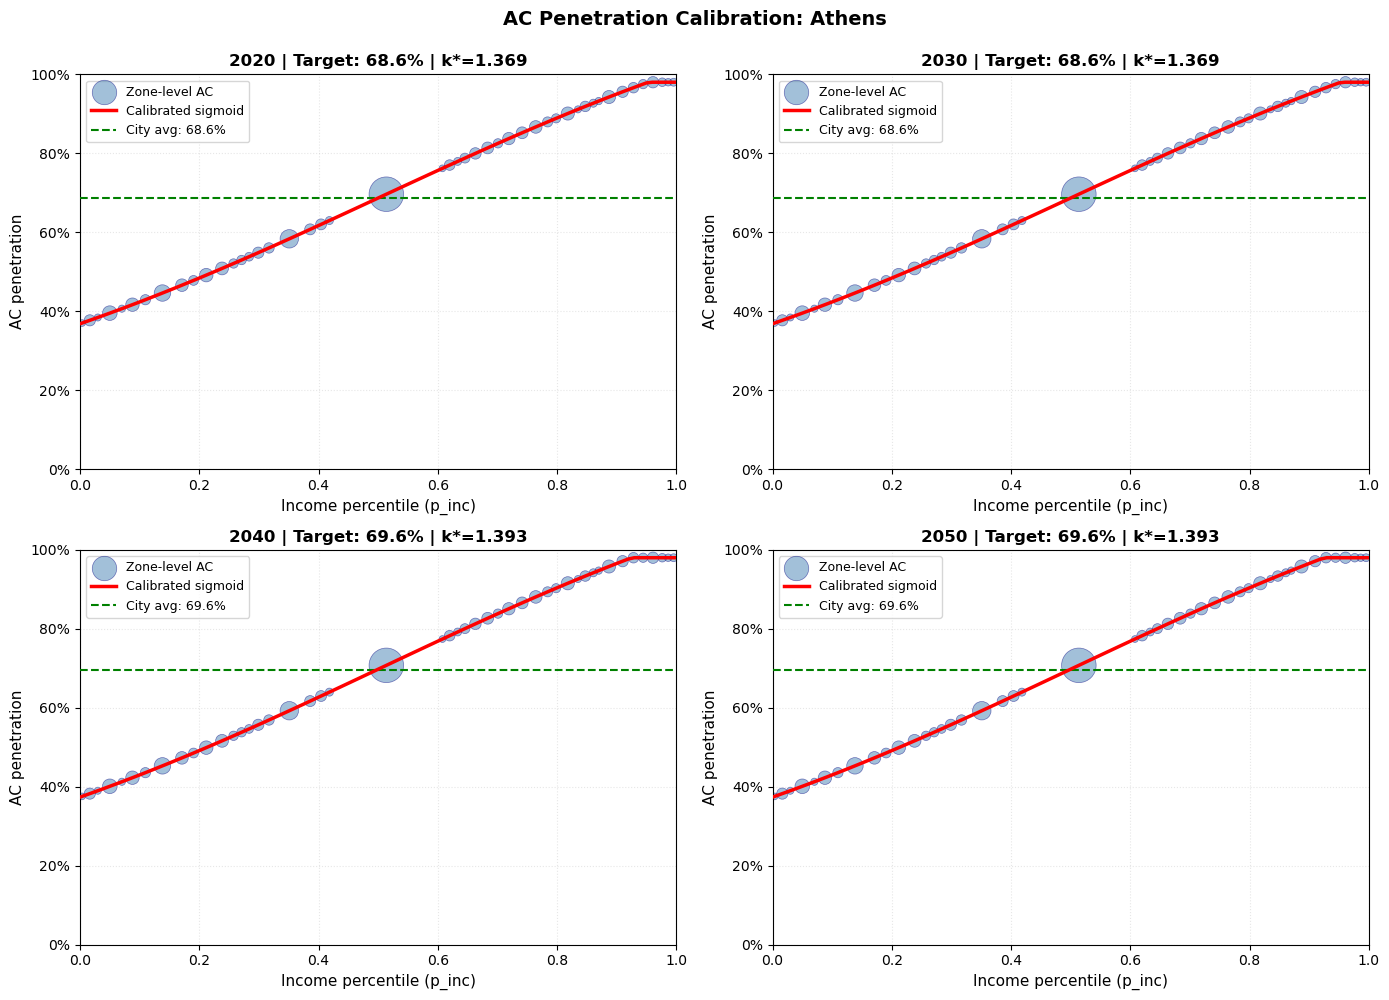

In [25]:
# Calibrate a monotonic income-ranked AC curve and solve for k each year so the zone average matches the NUTS target exactly.
import numpy as np
import matplotlib.pyplot as plt

# make years consistent 
YEARS_AC = [int(y) for y in YEARS_AC]
ac_city_by_year = {int(k): float(v) for k, v in ac_city_by_year.items()}

CITY_LABEL = cfg.get("city_name", globals().get("CITY", SLUG))

# Inputs for the zone-level AC calibration.
valid = (zone_stats["pop_zone"] > 0) & np.isfinite(zone_stats["p_inc"])
if not valid.any():
    raise RuntimeError("No valid Zone rows (require pop_zone>0 and finite p_inc).")

p_inc = zone_stats.loc[valid, "p_inc"].to_numpy(float)
w     = zone_stats.loc[valid, "pop_zone"].to_numpy(float)

ac_cfg = cfg.get("ac", {})
ac_min = float(ac_cfg.get("ac_min", 0.05))
ac_max = float(ac_cfg.get("ac_max", 0.98))
s      = float(ac_cfg.get("rank_slope", 2.2))

sig        = 1.0 / (1.0 + np.exp(-s * (p_inc - 0.5)))
base_acraw = ac_min + (ac_max - ac_min) * sig

ac_zone_by_year = {}
k_star_by_year = {}

def avg_after_clip(k: float, target_shape: np.ndarray) -> float:
    x = np.clip(ac_min + k * (target_shape - ac_min), ac_min, ac_max)
    return float(np.average(x, weights=w)) if w.sum() > 0 else float(x.mean())

# Build zone-level baseline AC shares for each modeled year.
for y in YEARS_AC:
    if y not in ac_city_by_year:
        raise KeyError(f"Year {y} missing in ac_city_by_year. Have: {sorted(ac_city_by_year)}")

    target = float(ac_city_by_year[y])
    if target > 1.0:
        target /= 100.0
    target = float(np.clip(target, 0.0, 1.0))

    lo_mean = avg_after_clip(0.0, base_acraw)
    hi_mean = avg_after_clip(1e6, base_acraw)
    if not (lo_mean - 1e-9 <= target <= hi_mean + 1e-9):
        print(f"[warn] {y}: target {target:.3f} outside [{lo_mean:.3f}, {hi_mean:.3f}]")

    k_lo, k_hi = 0.0, 1e6
    for _ in range(60):
        k_mid = 0.5 * (k_lo + k_hi)
        if avg_after_clip(k_mid, base_acraw) < target:
            k_lo = k_mid
        else:
            k_hi = k_mid
    k_star = 0.5 * (k_lo + k_hi)

    x = np.clip(ac_min + k_star * (base_acraw - ac_min), ac_min, ac_max)

    ac_vec = np.full(len(zone_stats), np.nan, dtype=float)
    ac_vec[valid.to_numpy()] = x
    ac_zone_by_year[y] = ac_vec
    k_star_by_year[y] = k_star

    achieved = float(np.average(x, weights=w))
    print(f"[{CITY_LABEL}] Year {y}: target={target:.3f}, achieved={achieved:.3f}, k*={k_star:.4g}")

# Keep the final-year baseline vector as a compatibility column for later cells.
zone_stats["ac_zone_baseline"] = ac_zone_by_year[YEARS_AC[-1]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, year in enumerate(YEARS_AC):  # All years: [2020, 2030, 2040, 2050]
    ax = axes[idx]
    
    # Scatter: actual Zone-level AC vs income percentile
    valid_mask = np.isfinite(zone_stats['p_inc']) & np.isfinite(ac_zone_by_year[year])
    
    ax.scatter(
        zone_stats.loc[valid_mask, 'p_inc'], 
        ac_zone_by_year[year][valid_mask],
        s=zone_stats.loc[valid_mask, 'pop_zone']/1000,  # size by population
        alpha=0.5,
        c='steelblue',
        edgecolors='navy',
        linewidth=0.5,
        label='Zone-level AC'
    )
    
    # Overlay: theoretical logistic curve
    p_range = np.linspace(0, 1, 100)
    sig_range = 1 / (1 + np.exp(-s * (p_range - 0.5)))
    base_range = ac_min + (ac_max - ac_min) * sig_range
    k = k_star_by_year[year]
    ac_range = np.clip(ac_min + k * (base_range - ac_min), ac_min, ac_max)
    
    ax.plot(p_range, ac_range, 'r-', lw=2.5, label='Calibrated sigmoid', zorder=10)
    
    # Reference line: city average
    city_avg = ac_city_by_year[year]
    ax.axhline(city_avg, color='green', ls='--', lw=1.5, 
               label=f'City avg: {city_avg:.1%}', zorder=5)
    
    # Formatting
    ax.set_xlabel('Income percentile (p_inc)', fontsize=11)
    ax.set_ylabel('AC penetration', fontsize=11)

    valid_data = ac_zone_by_year[year][valid_mask]
    corr = np.corrcoef(zone_stats.loc[valid_mask, 'p_inc'], valid_data)[0, 1]

    ax.set_title(f'{year} | Target: {city_avg:.1%} | k*={k:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3, ls=':')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Format y-axis as percentages
    from matplotlib.ticker import PercentFormatter
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.suptitle(f'AC Penetration Calibration: {CITY_LABEL}', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

# Save
output_path = INT / f'ac_calibration_{SLUG}.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

# Paint the calibrated zone-level baseline AC shares onto the analysis grid.
year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_zone_id = int(zone_stats["zone_id"].max())
zone_ids    = zone_stats["zone_id"].astype(int).to_numpy()

coverage_base_3d = np.full((n_years, HGT, WDT), np.nan, dtype="float32")

for y in YEARS_AC:
    ac_by_id = np.full(max_zone_id + 1, np.nan, dtype=float)
    ac_by_id[zone_ids] = ac_zone_by_year[y]

    grid = ac_by_id[zone_on_ref]
    grid[~CITY_MASK] = np.nan
    coverage_base_3d[year_to_index[y]] = grid.astype("float32")

coverage_base = coverage_base_3d[year_to_index[YEARS_AC[-1]]]

The calibration figure is a consistency check rather than a direct estimate from observed household AC surveys. What matters here is that the fitted zone-level curve stays monotonic in income rank, respects the configured lower and upper bounds, and reproduces the city-level NUTS target exactly once the calibration parameter `k` has been solved.

In [26]:
print("\n" + "="*60)
print("AC CALIBRATION VALIDATION")
print("="*60)

for year in YEARS_AC:
    target = ac_city_by_year[year]
    achieved = np.average(ac_zone_by_year[year][valid], weights=w)
    error = abs(achieved - target)
    
    # income gradient strength
    ac_vals = ac_zone_by_year[year][valid]
    corr = np.corrcoef(p_inc, ac_vals)[0, 1]
    
    # range
    ac_min_obs = ac_vals.min()
    ac_max_obs = ac_vals.max()
    
    print(f"\n{year}:")
    print(f"  Target:      {target:.3%}")
    print(f"  Achieved:    {achieved:.3%}")
    print(f"  Error:       {error:.4%}")
    print(f"  k*:          {k_star_by_year[year]:.4f}")
    print(f"  Income corr: {corr:.3f}")
    print(f"  Range:       [{ac_min_obs:.1%}, {ac_max_obs:.1%}]")


AC CALIBRATION VALIDATION

2020:
  Target:      68.613%
  Achieved:    68.613%
  Error:       0.0000%
  k*:          1.3693
  Income corr: 0.999
  Range:       [37.0%, 98.0%]

2030:
  Target:      68.613%
  Achieved:    68.613%
  Error:       0.0000%
  k*:          1.3693
  Income corr: 0.999
  Range:       [37.0%, 98.0%]

2040:
  Target:      69.605%
  Achieved:    69.605%
  Error:       0.0000%
  k*:          1.3927
  Income corr: 0.999
  Range:       [37.5%, 98.0%]

2050:
  Target:      69.605%
  Achieved:    69.605%
  Error:       0.0000%
  k*:          1.3927
  Income corr: 0.999
  Range:       [37.5%, 98.0%]


A strong fit in this section means the income-based downscaling is internally consistent, not that income is the only driver of AC adoption. The model is intentionally parsimonious: it uses income to distribute a known city total across local zones, while other possible drivers of AC uptake remain outside the scope of this notebook.

In [27]:
# Build baseline coverage maps on the grid from the calibrated zone-level shares.
year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_zone_id = int(zone_stats["zone_id"].max())
zone_ids    = zone_stats["zone_id"].astype(int).to_numpy()

coverage_base_3d = np.full((n_years, HGT, WDT), np.nan, dtype="float32")

for y in YEARS_AC:
    k = year_to_index[y]

    ac_by_id = np.full(max_zone_id + 1, np.nan, dtype=float)
    ac_by_id[zone_ids] = ac_zone_by_year[y]

    grid = ac_by_id[zone_on_ref]      # CAP to grid
    grid[~CITY_MASK] = np.nan

    coverage_base_3d[k] = grid.astype("float32")

coverage_base = coverage_base_3d[YEARS_AC.index(2050)]

In [28]:
# Check coverage — report against MASK_POLICY (analysis domain) and CITY_MASK (full FUA)
for y in YEARS_AC:
    grid_y = coverage_base_3d[year_to_index[y]]
    
    # Primary metric: coverage inside MASK_POLICY (city proper / region jurisdiction)
    policy_total = int(MASK_POLICY.sum())
    has_ac_policy = int((np.isfinite(grid_y) & MASK_POLICY).sum())
    pct_policy = 100 * has_ac_policy / policy_total if policy_total else 0
    
    # Secondary metric: coverage inside full FUA (CITY_MASK)
    fua_total = int(CITY_MASK.sum())
    has_ac_fua = int((np.isfinite(grid_y) & CITY_MASK).sum())
    pct_fua = 100 * has_ac_fua / fua_total if fua_total else 0
    
    print(f"{y}: {PLOT_LABEL} domain: {has_ac_policy:,}/{policy_total:,} pixels "
          f"({pct_policy:.1f}%) | full FUA: {has_ac_fua:,}/{fua_total:,} ({pct_fua:.1f}%)")
    
    missing_policy = policy_total - has_ac_policy
    if missing_policy > 0:
        print(f"  ⚠ {missing_policy:,} {PLOT_LABEL.lower()} pixels missing AC data "
              f"({100*missing_policy/policy_total:.1f}%)")

2020: Zones domain: 60,551/60,551 pixels (100.0%) | full FUA: 60,551/61,422 (98.6%)
2030: Zones domain: 60,551/60,551 pixels (100.0%) | full FUA: 60,551/61,422 (98.6%)
2040: Zones domain: 60,551/60,551 pixels (100.0%) | full FUA: 60,551/61,422 (98.6%)
2050: Zones domain: 60,551/60,551 pixels (100.0%) | full FUA: 60,551/61,422 (98.6%)


In [29]:
def make_zone_sub_for_year(y):
    """Zone-level table for year y, with AC share from ac_zone_by_year[y]."""
    vec = ac_zone_by_year[y]  # length = len(zone_stats)
    tmp = zone_stats.copy()
    tmp["ac_zone_year"] = vec

    zone_sub_y = tmp.loc[
        (tmp["pop_zone"] > 0)
        & np.isfinite(tmp["inc_mean"])
        & np.isfinite(tmp["ac_zone_year"]),
        ["zone_code", "inc_mean", "inc_rank_base", "p_inc", "ac_zone_year", "pop_zone"]
    ].copy()
    return zone_sub_y


=== QA for year 2020 ===
Poorest zones (by clipped income rank): expect low p_inc & low AC


,zone_code,inc_mean,inc_rank_base,p_inc,ac_zone_year,pop_zone
1,Δήμος Αγίας Βαρβάρας,"11,213.333","11,317.955",0.003,0.370,"23,553.096"
6,Δήμος Αιγάλεω,"11,422.576","11,422.576",0.016,0.377,"65,347.371"
48,Δήμος Περάματος,"11,625.000","11,625.000",0.030,0.384,"26,224.822"
41,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,"12,185.313","12,185.313",0.050,0.395,"111,435.279"
9,Δήμος Ασπροπύργου,"12,219.018","12,219.018",0.070,0.406,"27,136.164"
10,Δήμος Αχαρνών,"12,303.227","12,303.227",0.088,0.416,"94,086.899"
4,Δήμος Αγίων Αναργύρων – Καματερού,"12,496.482","12,496.482",0.110,0.429,"54,556.452"
49,Δήμος Περιστερίου,"12,733.459","12,733.459",0.138,0.446,"140,988.639"



Richest zones (by clipped income rank): expect high p_inc & high AC


,zone_code,inc_mean,inc_rank_base,p_inc,ac_zone_year,pop_zone
56,Δήμος Φιλοθέης - Ψυχικού,"24,817.906","24,008.170",0.995,0.980,"32,600.267"
12,Δήμος Βριλησσίων,"23,198.433","23,198.433",0.986,0.980,"29,617.584"
47,Δήμος Πεντέλης,"22,376.475","22,376.475",0.976,0.980,"38,372.247"
27,Δήμος Κηφισιάς,"22,303.845","22,303.845",0.961,0.980,"67,796.528"
45,Δήμος Παπάγου - Χολαργού,"21,493.056","21,493.056",0.944,0.975,"45,482.471"
17,Δήμος Διονύσου,"20,616.667","20,616.667",0.937,0.971,"1,741.646"
51,Δήμος Ραφήνας - Πικερμίου,"19,987.113","19,987.113",0.937,0.971,"1,790.946"
2,Δήμος Αγίας Παρασκευής,"19,869.565","19,869.565",0.928,0.966,"58,001.213"



Unweighted Pearson corr (inc_mean vs AC):


...


Richest zones (by clipped income rank): expect high p_inc & high AC


,zone_code,inc_mean,inc_rank_base,p_inc,ac_zone_year,pop_zone
56,Δήμος Φιλοθέης - Ψυχικού,"24,817.906","24,008.170",0.995,0.980,"32,600.267"
12,Δήμος Βριλησσίων,"23,198.433","23,198.433",0.986,0.980,"29,617.584"
47,Δήμος Πεντέλης,"22,376.475","22,376.475",0.976,0.980,"38,372.247"
27,Δήμος Κηφισιάς,"22,303.845","22,303.845",0.961,0.980,"67,796.528"
45,Δήμος Παπάγου - Χολαργού,"21,493.056","21,493.056",0.944,0.980,"45,482.471"
17,Δήμος Διονύσου,"20,616.667","20,616.667",0.937,0.980,"1,741.646"
51,Δήμος Ραφήνας - Πικερμίου,"19,987.113","19,987.113",0.937,0.980,"1,790.946"
2,Δήμος Αγίας Παρασκευής,"19,869.565","19,869.565",0.928,0.980,"58,001.213"



Unweighted Pearson corr (inc_mean vs AC):


,inc_mean,ac_zone_year
inc_mean,1.000,0.892
ac_zone_year,0.892,1.000


Weighted Pearson corr (by grid pop): 0.881
Pop-weighted mean AC share: 0.696


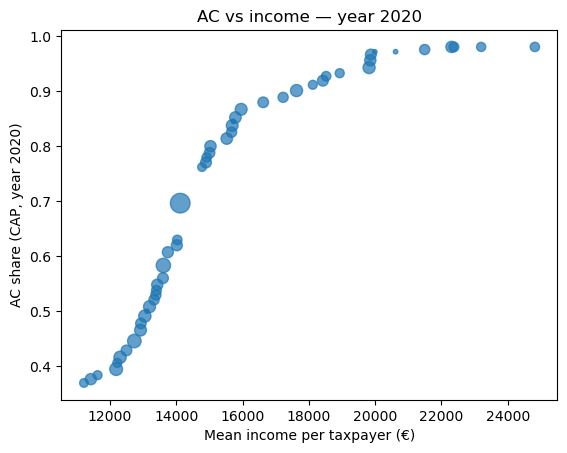

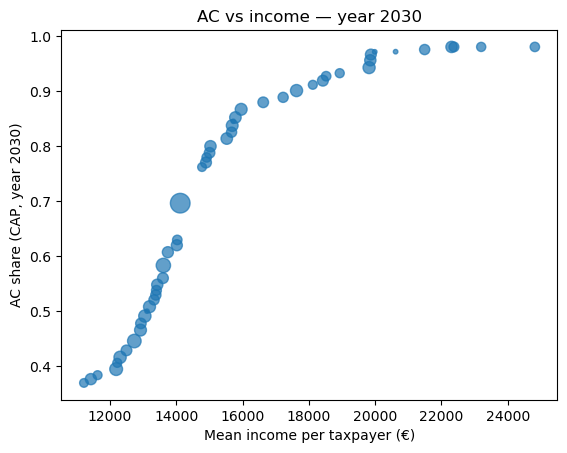

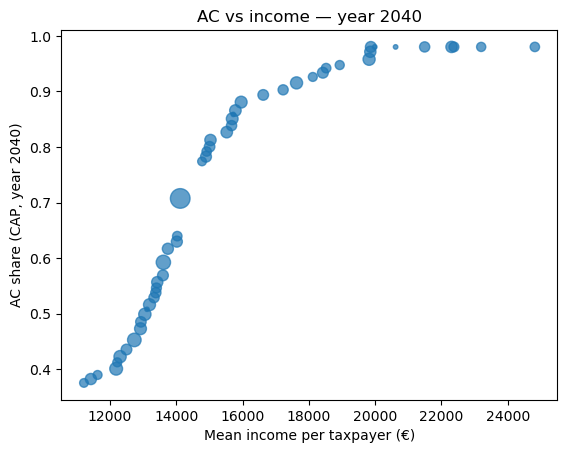

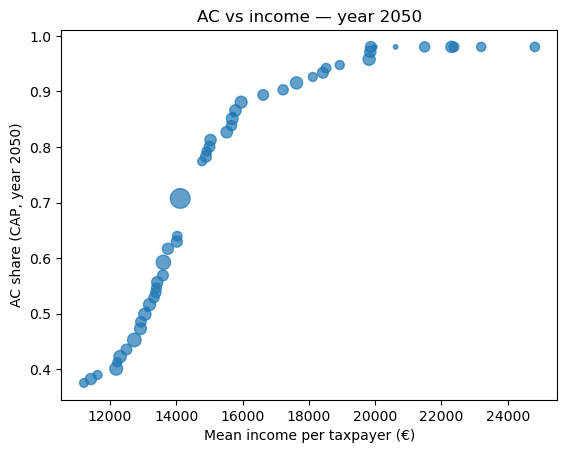

In [30]:
pd.options.display.float_format = "{:,.3f}".format

def weighted_corr(x, y, w):
    x = np.asarray(x, float); y = np.asarray(y, float); w = np.asarray(w, float)
    m_x = np.average(x, weights=w); m_y = np.average(y, weights=w)
    cov = np.average((x - m_x) * (y - m_y), weights=w)
    sx = np.sqrt(np.average((x - m_x)**2, weights=w))
    sy = np.sqrt(np.average((y - m_y)**2, weights=w))
    return cov / (sx * sy) if (sx > 0 and sy > 0) else np.nan

for y in YEARS_AC:
    print(f"\n=== QA for year {y} ===")
    zone_sub = make_zone_sub_for_year(y)

    n_show = min(8, len(zone_sub))

    print("Poorest zones (by clipped income rank): expect low p_inc & low AC")
    display(zone_sub.sort_values("inc_rank_base", kind="mergesort").head(n_show))

    print("\nRichest zones (by clipped income rank): expect high p_inc & high AC")
    display(zone_sub.sort_values("inc_rank_base", ascending=False, kind="mergesort").head(n_show))

    print("\nUnweighted Pearson corr (inc_mean vs AC):")
    display(zone_sub[["inc_mean", "ac_zone_year"]].corr().round(3))

    wc = weighted_corr(zone_sub["inc_mean"], zone_sub["ac_zone_year"], zone_sub["pop_zone"])
    mean_pop = np.average(zone_sub["ac_zone_year"], weights=zone_sub["pop_zone"])
    print(f"Weighted Pearson corr (by grid pop): {wc:.3f}")
    print(f"Pop-weighted mean AC share: {mean_pop:.3f}")

    size = 200 * np.sqrt(zone_sub["pop_zone"] / zone_sub["pop_zone"].max())
    size = np.clip(size, 10, None)

    ax = zone_sub.plot.scatter(x="inc_mean", y="ac_zone_year", s=size, alpha=0.7)
    ax.set_xlabel("Mean income per taxpayer (€)")
    ax.set_ylabel(f"AC share (CAP, year {y})")
    ax.set_title(f"AC vs income — year {y}")

### 2.2 Baseline coverage maps

These maps show the modeled **current AC baseline** on the analysis grid. Because coverage is calibrated at zone level and then painted to pixels, sharp changes at zone boundaries are expected and reflect the downscaling geography rather than local microclimate variation.

**Current zone-level AC coverage on the analysis grid**

This gridded baseline is the reference coverage used later in the mortality, electricity, equity, and waste-heat calculations.


===== YEAR 2020 =====
[QA] City pop-w mean on grid 2020: 0.686 (target 0.686)
[QA] City pop-w mean from CAP agg: 0.686 (target 0.686)
[QA] City pop-w mean (CITY_MASK): 0.686 (target 0.686)


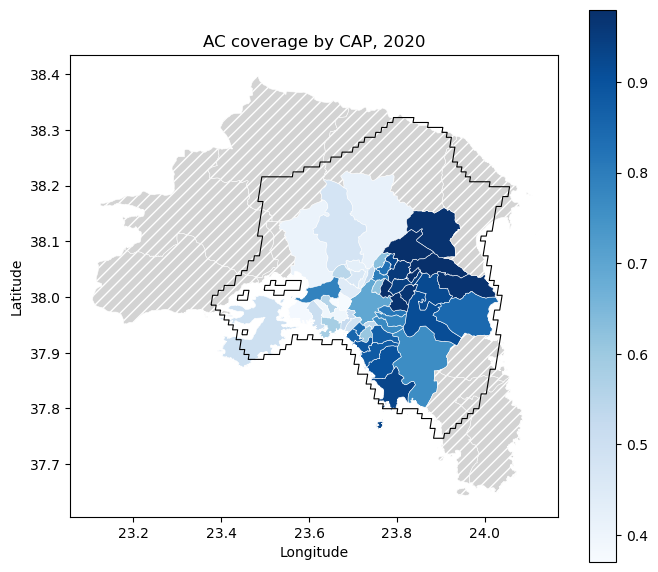


Lowest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,2,Δήμος Αγίας Βαρβάρας,0.370,"23,553.096",36.985
1,7,Δήμος Αιγάλεω,0.377,"65,347.371",37.674
2,49,Δήμος Περάματος,0.384,"26,224.822",38.395
3,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,0.395,"111,435.279",39.496
4,10,Δήμος Ασπροπύργου,0.406,"27,136.164",40.628
5,11,Δήμος Αχαρνών,0.416,"94,086.899",41.637
6,5,Δήμος Αγίων Αναργύρων – Καματερού,0.429,"54,556.452",42.897
7,50,Δήμος Περιστερίου,0.446,"140,988.639",44.591
8,24,Δήμος Ιλίου,0.466,"82,691.742",46.580
9,58,Δήμος Φυλής,0.478,"50,582.488",47.788


Highest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,28,Δήμος Κηφισιάς,0.980,"67,796.528",98.000
1,57,Δήμος Φιλοθέης - Ψυχικού,0.980,"32,600.267",98.000
2,48,Δήμος Πεντέλης,0.980,"38,372.247",98.000
3,13,Δήμος Βριλησσίων,0.980,"29,617.584",98.000
4,46,Δήμος Παπάγου - Χολαργού,0.975,"45,482.471",97.522
5,18,Δήμος Διονύσου,0.971,"1,741.646",97.136
6,52,Δήμος Ραφήνας - Πικερμίου,0.971,"1,790.946",97.107
7,3,Δήμος Αγίας Παρασκευής,0.966,"58,001.213",96.615
8,9,Δήμος Αμαρουσίου,0.956,"66,614.027",95.576
9,59,Δήμος Χαλανδρίου,0.942,"89,600.644",94.249



===== YEAR 2030 =====
[QA] City pop-w mean on grid 2030: 0.686 (target 0.686)
[QA] City pop-w mean from CAP agg: 0.686 (target 0.686)
[QA] City pop-w mean (CITY_MASK): 0.686 (target 0.686)


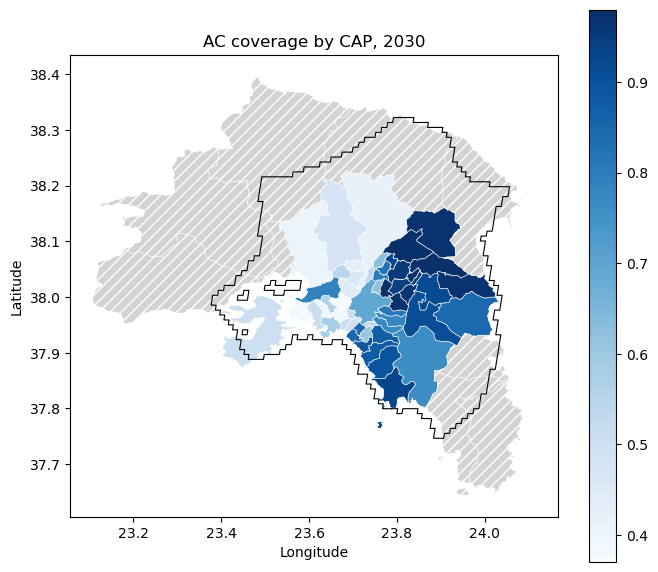


Lowest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,2,Δήμος Αγίας Βαρβάρας,0.370,"23,553.096",36.985
1,7,Δήμος Αιγάλεω,0.377,"65,347.371",37.674
2,49,Δήμος Περάματος,0.384,"26,224.822",38.395
3,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,0.395,"111,435.279",39.496
4,10,Δήμος Ασπροπύργου,0.406,"27,136.164",40.628
5,11,Δήμος Αχαρνών,0.416,"94,086.899",41.637
6,5,Δήμος Αγίων Αναργύρων – Καματερού,0.429,"54,556.452",42.897
7,50,Δήμος Περιστερίου,0.446,"140,988.639",44.591
8,24,Δήμος Ιλίου,0.466,"82,691.742",46.580
9,58,Δήμος Φυλής,0.478,"50,582.488",47.788


Highest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,28,Δήμος Κηφισιάς,0.980,"67,796.528",98.000
1,57,Δήμος Φιλοθέης - Ψυχικού,0.980,"32,600.267",98.000
2,48,Δήμος Πεντέλης,0.980,"38,372.247",98.000
3,13,Δήμος Βριλησσίων,0.980,"29,617.584",98.000
4,46,Δήμος Παπάγου - Χολαργού,0.975,"45,482.471",97.522
5,18,Δήμος Διονύσου,0.971,"1,741.646",97.136
6,52,Δήμος Ραφήνας - Πικερμίου,0.971,"1,790.946",97.107
7,3,Δήμος Αγίας Παρασκευής,0.966,"58,001.213",96.615
8,9,Δήμος Αμαρουσίου,0.956,"66,614.027",95.576
9,59,Δήμος Χαλανδρίου,0.942,"89,600.644",94.249



===== YEAR 2040 =====
[QA] City pop-w mean on grid 2040: 0.696 (target 0.696)
[QA] City pop-w mean from CAP agg: 0.696 (target 0.696)
[QA] City pop-w mean (CITY_MASK): 0.696 (target 0.696)


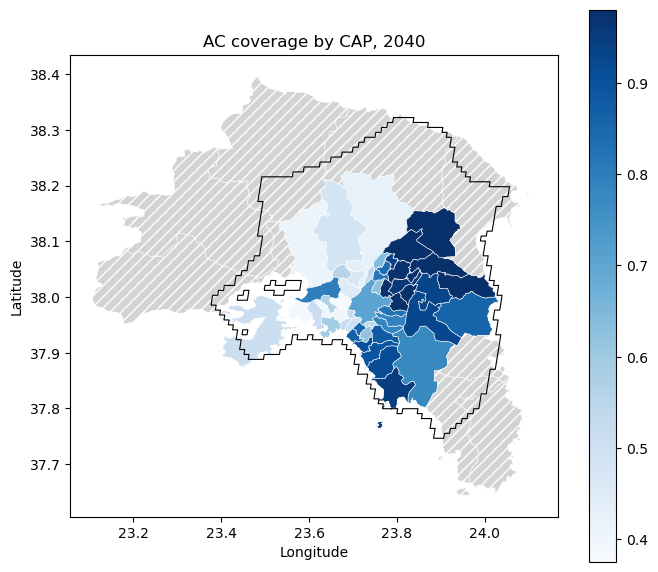


Lowest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,2,Δήμος Αγίας Βαρβάρας,0.375,"23,553.096",37.532
1,7,Δήμος Αιγάλεω,0.382,"65,347.371",38.233
2,49,Δήμος Περάματος,0.390,"26,224.822",38.966
3,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,0.401,"111,435.279",40.086
4,10,Δήμος Ασπροπύργου,0.412,"27,136.164",41.238
5,11,Δήμος Αχαρνών,0.423,"94,086.899",42.264
6,5,Δήμος Αγίων Αναργύρων – Καματερού,0.435,"54,556.452",43.545
7,50,Δήμος Περιστερίου,0.453,"140,988.639",45.268
8,24,Δήμος Ιλίου,0.473,"82,691.742",47.291
9,58,Δήμος Φυλής,0.485,"50,582.488",48.520


Highest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,28,Δήμος Κηφισιάς,0.980,"67,796.528",98.000
1,46,Δήμος Παπάγου - Χολαργού,0.980,"45,482.471",98.000
2,57,Δήμος Φιλοθέης - Ψυχικού,0.980,"32,600.267",98.000
3,48,Δήμος Πεντέλης,0.980,"38,372.247",98.000
4,13,Δήμος Βριλησσίων,0.980,"29,617.584",98.000
5,52,Δήμος Ραφήνας - Πικερμίου,0.980,"1,790.946",98.000
6,3,Δήμος Αγίας Παρασκευής,0.980,"58,001.213",98.000
7,18,Δήμος Διονύσου,0.980,"1,741.646",98.000
8,9,Δήμος Αμαρουσίου,0.971,"66,614.027",97.125
9,59,Δήμος Χαλανδρίου,0.958,"89,600.644",95.775



===== YEAR 2050 =====
[QA] City pop-w mean on grid 2050: 0.696 (target 0.696)
[QA] City pop-w mean from CAP agg: 0.696 (target 0.696)
[QA] City pop-w mean (CITY_MASK): 0.696 (target 0.696)


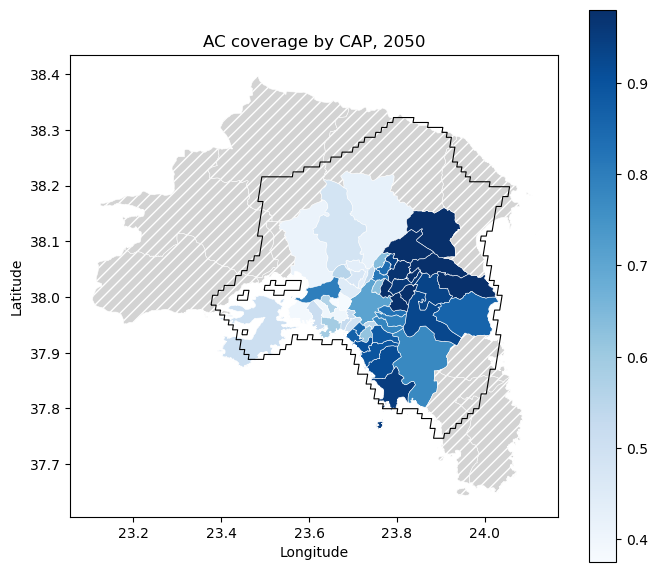


Lowest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,2,Δήμος Αγίας Βαρβάρας,0.375,"23,553.096",37.532
1,7,Δήμος Αιγάλεω,0.382,"65,347.371",38.233
2,49,Δήμος Περάματος,0.390,"26,224.822",38.966
3,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,0.401,"111,435.279",40.086
4,10,Δήμος Ασπροπύργου,0.412,"27,136.164",41.238
5,11,Δήμος Αχαρνών,0.423,"94,086.899",42.264
6,5,Δήμος Αγίων Αναργύρων – Καματερού,0.435,"54,556.452",43.545
7,50,Δήμος Περιστερίου,0.453,"140,988.639",45.268
8,24,Δήμος Ιλίου,0.473,"82,691.742",47.291
9,58,Δήμος Φυλής,0.485,"50,582.488",48.520


Highest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,28,Δήμος Κηφισιάς,0.980,"67,796.528",98.000
1,46,Δήμος Παπάγου - Χολαργού,0.980,"45,482.471",98.000
2,57,Δήμος Φιλοθέης - Ψυχικού,0.980,"32,600.267",98.000
3,48,Δήμος Πεντέλης,0.980,"38,372.247",98.000
4,13,Δήμος Βριλησσίων,0.980,"29,617.584",98.000
5,52,Δήμος Ραφήνας - Πικερμίου,0.980,"1,790.946",98.000
6,3,Δήμος Αγίας Παρασκευής,0.980,"58,001.213",98.000
7,18,Δήμος Διονύσου,0.980,"1,741.646",98.000
8,9,Δήμος Αμαρουσίου,0.971,"66,614.027",97.125
9,59,Δήμος Χαλανδρίου,0.958,"89,600.644",95.775


In [31]:
import matplotlib.pyplot as plt

for YEAR_DIAG in YEARS_AC:
    print("\n===== YEAR", YEAR_DIAG, "=====")
    k_diag = year_to_index[YEAR_DIAG]

    coverage_map = coverage_base_3d[k_diag].astype("float32").copy()

    target_ac = float(ac_city_by_year[YEAR_DIAG])
    if target_ac > 1.0:
        target_ac /= 100.0
    target_ac = float(np.clip(target_ac, 0.0, 1.0))

    if np.isnan(coverage_map[CITY_MASK]).any():
        coverage_map = np.where(
            CITY_MASK & np.isnan(coverage_map),
            target_ac,
            coverage_map
        ).astype("float32")

    assert np.isfinite(coverage_map[CITY_MASK]).all(), "Non-finite coverage inside CITY_MASK."

    m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_on_ref > 0)
    w = pop_on_ref[m_city]
    x = coverage_map[m_city]
    mean_pw = float(np.nansum(x * w) / np.nansum(w))

    print(f"[QA] City pop-w mean on grid {YEAR_DIAG}: {mean_pw:.3f} (target {target_ac:.3f})")

    valid = ZONE_PIX
    df_zonegrid = pd.DataFrame({
        "zone_id": zone_on_ref[valid].ravel().astype(int),
        "pop":    pop_on_ref[valid].ravel().astype(float),
        "cov":    coverage_map[valid].ravel().astype(float),
    })
    df_zonegrid = df_zonegrid[df_zonegrid["zone_id"] > 0]

    def wavg(g):
        w = g["pop"].to_numpy(dtype=float)
        x = g["cov"].to_numpy(dtype=float)
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    zone_pw   = df_zonegrid.groupby("zone_id").apply(wavg).reset_index(name="ac_cov_pw")
    zone_pop  = (df_zonegrid.groupby("zone_id", as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_zone"}))
    zone_disp = (df_zonegrid.groupby("zone_id")
                .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                     ac_max=("cov","max"), n_pix=("cov","size"))
                .reset_index())
    zone_cov = zone_pw.merge(zone_pop, on="zone_id", how="left").merge(zone_disp, on="zone_id", how="left")
    zone_map = zone_4326.merge(zone_cov, on="zone_id", how="left")

    cov_city_check = float(np.nansum(df_zonegrid["cov"] * df_zonegrid["pop"]) / np.nansum(df_zonegrid["pop"]))
    cov_city_all = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
    print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {target_ac:.3f})")
    print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {target_ac:.3f})")

    ax = fua.to_crs("EPSG:4326").boundary.plot(
        edgecolor="black", facecolor="none", linewidth=0.8, figsize=(7,6)
    )
    zone_map.to_crs("EPSG:4326").plot(
        ax=ax, column="ac_cov_pw", cmap="Blues", legend=True,
        edgecolor="white", linewidth=0.4,
        missing_kwds={"color":"lightgray","edgecolor":"white","hatch":"///","label":"No data"}
    )
    ax.set_title(f"AC coverage by CAP, {YEAR_DIAG}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.figure.tight_layout()
    plt.show()

    tbl = (zone_map[["zone_id","zone_code","ac_cov_pw","pop_zone"]]
           .dropna(subset=["ac_cov_pw"])
           .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
           .sort_values("ac_pct"))

    print("\nLowest-coverage zones:")
    display(tbl.head(10).reset_index(drop=True))

    print("Highest-coverage zones:")
    display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))

### 2.3 Coverage diagnostics

The diagnostics below check that valid coverage values exist across the policy domain and that the calibrated zone shares behave as expected once they are rasterized to the common grid.

In [32]:
import matplotlib.pyplot as plt

# for each of the year 2020, 2030, 2040, 2050
for y in YEARS_AC:
    print("\n" + "="*20 + f" YEAR {y} " + "="*20)
    YEAR_DIAG = y
    k_diag    = year_to_index[YEAR_DIAG]

    # coverage on grid for this year 
    coverage_map = coverage_base_3d[k_diag].astype("float32").copy()

    # target citywide mean for that year 
    target_ac = float(ac_city_by_year[YEAR_DIAG])
    if target_ac > 1.0:
        target_ac /= 100.0
    target_ac = float(np.clip(target_ac, 0.0, 1.0))

    # fill any remaining NaNs inside CITY_MASK with the city mean for that year
    if np.isnan(coverage_map[CITY_MASK]).any():
        coverage_map = np.where(
            CITY_MASK & np.isnan(coverage_map),
            target_ac,
            coverage_map
        ).astype("float32")

    # assert no NaNs where we care
    assert np.isfinite(coverage_map[CITY_MASK]).all(), \
        f"Non-finite coverage inside CITY_MASK for year {YEAR_DIAG}."

    # city pop-weighted mean on grid
    pop_grid_y = POP_GRID.get(YEAR_DIAG, pop_on_ref_base)
    m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_grid_y > 0)
    w      = pop_grid_y[m_city]
    x = coverage_map[m_city]
    mean_pw = float(np.nansum(x * w) / np.nansum(w))

    print(f"[QA] City pop-w mean on grid {YEAR_DIAG}: {mean_pw:.3f} (target {target_ac:.3f})")

    # CAP aggregation + map for this year 
    valid = ZONE_PIX
    df_zonegrid = pd.DataFrame({
        "zone_id": zone_on_ref[valid].ravel().astype(int),
        "pop":    pop_on_ref[valid].ravel().astype(float),
        "cov":    coverage_map[valid].ravel().astype(float),
    })
    df_zonegrid = df_zonegrid[df_zonegrid["zone_id"] > 0]

    def wavg(g):
        w = g["pop"].to_numpy(dtype=float)
        x = g["cov"].to_numpy(dtype=float)
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    zone_pw   = df_zonegrid.groupby("zone_id").apply(wavg).reset_index(name="ac_cov_pw")
    zone_pop  = (df_zonegrid.groupby("zone_id", as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_zone"}))
    zone_disp = (df_zonegrid.groupby("zone_id")
                .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                     ac_max=("cov","max"), n_pix=("cov","size"))
                .reset_index())
    zone_cov = zone_pw.merge(zone_pop, on="zone_id", how="left").merge(zone_disp, on="zone_id", how="left")
    zone_map = zone_4326.merge(zone_cov, on="zone_id", how="left")

    cov_city_check = float(np.nansum(df_zonegrid["cov"] * df_zonegrid["pop"]) / np.nansum(df_zonegrid["pop"]))
    cov_city_all   = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
    print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {target_ac:.3f})")
    print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {target_ac:.3f})")

    # consistency checks by year 
    # pixels we actually painted from CAPs
    df_zonegrid_cons = df_zonegrid.copy()

    zone_pw_cons  = df_zonegrid_cons.groupby("zone_id").apply(wavg).reset_index(name="ac_cov_pw")
    zone_pop_cons = (df_zonegrid_cons.groupby("zone_id", as_index=False)["pop"]
                    .sum().rename(columns={"pop":"pop_zone"}))
    zone_cov_cons = zone_pw_cons.merge(zone_pop_cons, on="zone_id", how="left")

    # year-specific CAP targets
    df_target = zone_stats[["zone_id"]].copy()
    df_target["ac_cap_target"] = ac_zone_by_year[YEAR_DIAG]

    cap_join = zone_cov_cons.merge(df_target, on="zone_id", how="left")

    diff = np.abs(cap_join["ac_cov_pw"] - cap_join["ac_cap_target"])
    err_cap = float(np.nanmax(diff)) if np.any(np.isfinite(diff)) else 0.0
    print(f"[{YEAR_DIAG}] Max per-CAP diff (grid vs CAP table): {err_cap:.3e}")

    # grid-level bounds respected
    m_city2 = CITY_MASK & np.isfinite(coverage_map)
    print(f"[{YEAR_DIAG}] Min/Max coverage on grid:",
          float(np.nanmin(coverage_map[m_city2])),
          float(np.nanmax(coverage_map[m_city2])))

    w2 = np.where(m_city2, pop_on_ref, 0.0)
    at_floor = np.isclose(coverage_map, ac_min, atol=1e-6)
    at_cap   = np.isclose(coverage_map, ac_max, atol=1e-6)
    print(f"[{YEAR_DIAG}] Pop share at floor:", float(np.nansum(w2 * at_floor) / np.nansum(w2)))
    print(f"[{YEAR_DIAG}] Pop share at cap:  ", float(np.nansum(w2 * at_cap)   / np.nansum(w2)))

    print(f"[{YEAR_DIAG}] Grid pop-weighted mean:",
          float(np.nansum(coverage_map[m_city2] * pop_on_ref[m_city2]) /
                np.nansum(pop_on_ref[m_city2])))

    # tables: lowest / highest coverage zones for this year
    tbl = (zone_map[["zone_id","zone_code","ac_cov_pw","pop_zone"]]
           .dropna(subset=["ac_cov_pw"])
           .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
           .sort_values("ac_pct"))

    print("\nLowest-coverage zones:")
    display(tbl.head(10).reset_index(drop=True))

    print("Highest-coverage zones:")
    display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))


==================== YEAR 2020 ====================
[QA] City pop-w mean on grid 2020: 0.686 (target 0.686)
[QA] City pop-w mean from CAP agg: 0.686 (target 0.686)
[QA] City pop-w mean (CITY_MASK): 0.686 (target 0.686)
[2020] Max per-CAP diff (grid vs CAP table): 2.960e-08
[2020] Min/Max coverage on grid: 0.3698475658893585 0.9800000190734863
[2020] Pop share at floor: 0.0
[2020] Pop share at cap:   0.04916903004050255
[2020] Grid pop-weighted mean: 0.6861342191696167

Lowest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,2,Δήμος Αγίας Βαρβάρας,0.370,"23,553.096",36.985
1,7,Δήμος Αιγάλεω,0.377,"65,347.371",37.674
2,49,Δήμος Περάματος,0.384,"26,224.822",38.395
3,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,0.395,"111,435.279",39.496
4,10,Δήμος Ασπροπύργου,0.406,"27,136.164",40.628
5,11,Δήμος Αχαρνών,0.416,"94,086.899",41.637
6,5,Δήμος Αγίων Αναργύρων – Καματερού,0.429,"54,556.452",42.897
7,50,Δήμος Περιστερίου,0.446,"140,988.639",44.591
8,24,Δήμος Ιλίου,0.466,"82,691.742",46.580
9,58,Δήμος Φυλής,0.478,"50,582.488",47.788


Highest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,28,Δήμος Κηφισιάς,0.980,"67,796.528",98.000
1,57,Δήμος Φιλοθέης - Ψυχικού,0.980,"32,600.267",98.000
2,48,Δήμος Πεντέλης,0.980,"38,372.247",98.000
3,13,Δήμος Βριλησσίων,0.980,"29,617.584",98.000
4,46,Δήμος Παπάγου - Χολαργού,0.975,"45,482.471",97.522
5,18,Δήμος Διονύσου,0.971,"1,741.646",97.136
6,52,Δήμος Ραφήνας - Πικερμίου,0.971,"1,790.946",97.107
7,3,Δήμος Αγίας Παρασκευής,0.966,"58,001.213",96.615
8,9,Δήμος Αμαρουσίου,0.956,"66,614.027",95.576
9,59,Δήμος Χαλανδρίου,0.942,"89,600.644",94.249



==================== YEAR 2030 ====================
[QA] City pop-w mean on grid 2030: 0.688 (target 0.686)
[QA] City pop-w mean from CAP agg: 0.686 (target 0.686)
[QA] City pop-w mean (CITY_MASK): 0.686 (target 0.686)
[2030] Max per-CAP diff (grid vs CAP table): 2.960e-08
[2030] Min/Max coverage on grid: 0.3698475658893585 0.9800000190734863
[2030] Pop share at floor: 0.0
[2030] Pop share at cap:   0.04916903004050255
[2030] Grid pop-weighted mean: 0.6861342191696167

Lowest-coverage zones:


...

,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,28,Δήμος Κηφισιάς,0.980,"67,796.528",98.000
1,46,Δήμος Παπάγου - Χολαργού,0.980,"45,482.471",98.000
2,57,Δήμος Φιλοθέης - Ψυχικού,0.980,"32,600.267",98.000
3,48,Δήμος Πεντέλης,0.980,"38,372.247",98.000
4,13,Δήμος Βριλησσίων,0.980,"29,617.584",98.000
5,52,Δήμος Ραφήνας - Πικερμίου,0.980,"1,790.946",98.000
6,3,Δήμος Αγίας Παρασκευής,0.980,"58,001.213",98.000
7,18,Δήμος Διονύσου,0.980,"1,741.646",98.000
8,9,Δήμος Αμαρουσίου,0.971,"66,614.027",97.125
9,59,Δήμος Χαλανδρίου,0.958,"89,600.644",95.775



==================== YEAR 2050 ====================
[QA] City pop-w mean on grid 2050: 0.699 (target 0.696)
[QA] City pop-w mean from CAP agg: 0.696 (target 0.696)
[QA] City pop-w mean (CITY_MASK): 0.696 (target 0.696)
[2050] Max per-CAP diff (grid vs CAP table): 2.900e-08
[2050] Min/Max coverage on grid: 0.37531745433807373 0.9800000190734863
[2050] Pop share at floor: 0.0
[2050] Pop share at cap:   0.08041787147521973
[2050] Grid pop-weighted mean: 0.6960455179214478

Lowest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,2,Δήμος Αγίας Βαρβάρας,0.375,"23,553.096",37.532
1,7,Δήμος Αιγάλεω,0.382,"65,347.371",38.233
2,49,Δήμος Περάματος,0.390,"26,224.822",38.966
3,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,0.401,"111,435.279",40.086
4,10,Δήμος Ασπροπύργου,0.412,"27,136.164",41.238
5,11,Δήμος Αχαρνών,0.423,"94,086.899",42.264
6,5,Δήμος Αγίων Αναργύρων – Καματερού,0.435,"54,556.452",43.545
7,50,Δήμος Περιστερίου,0.453,"140,988.639",45.268
8,24,Δήμος Ιλίου,0.473,"82,691.742",47.291
9,58,Δήμος Φυλής,0.485,"50,582.488",48.520


Highest-coverage zones:


,zone_id,zone_code,ac_cov_pw,pop_zone,ac_pct
0,28,Δήμος Κηφισιάς,0.980,"67,796.528",98.000
1,46,Δήμος Παπάγου - Χολαργού,0.980,"45,482.471",98.000
2,57,Δήμος Φιλοθέης - Ψυχικού,0.980,"32,600.267",98.000
3,48,Δήμος Πεντέλης,0.980,"38,372.247",98.000
4,13,Δήμος Βριλησσίων,0.980,"29,617.584",98.000
5,52,Δήμος Ραφήνας - Πικερμίου,0.980,"1,790.946",98.000
6,3,Δήμος Αγίας Παρασκευής,0.980,"58,001.213",98.000
7,18,Δήμος Διονύσου,0.980,"1,741.646",98.000
8,9,Δήμος Αμαρουσίου,0.971,"66,614.027",97.125
9,59,Δήμος Χαλανδρίου,0.958,"89,600.644",95.775


In [33]:
# Build one row per modeled zone with income rank and gridded population.
# we restrict to zones that actually have modeled population (>0) on the CLIMADA grid
zone_income_id = (
    zone_stats.loc[zone_stats["pop_zone"] > 0, ["zone_id","zone_code","p_inc","pop_zone"]]
             .rename(columns={"pop_zone":"pop_zone_grid", "p_inc":"rank_key"})
)

sel = (zone_income_id.loc[zone_income_id["pop_zone_grid"] > 0,
                         ["zone_id","zone_code","rank_key","pop_zone_grid"]]
       .sort_values("rank_key")   # still ascending: poorer first
       .reset_index(drop=True))

## 3. POLICY DESIGN (framework, income-targeted, uniform)

### 3.1 Policy framework

The policy comparison is constrained by **equal additional users**. The income-targeted and uniform policies are forced to add the same citywide number of AC users so that differences in mortality, equity, or electricity demand come from allocation, not from buying more units in one scenario.

### Policy comparison framework

The common comparison uses two stylized allocation rules under an equal-user constraint:

1. **Income-targeted policy**: prioritize lower-income zones and raise their coverage toward a catch-up target.
2. **Uniform policy**: apply the same percentage-point uplift everywhere, calibrated so the total number of added AC users matches the targeted policy.

This makes the comparison about *who* gets the additional AC rather than *how much* AC the city adds in total.

### 3.2 Income-targeted policy ("catch-up")

Zones are ranked by income, but the cutoff is defined on cumulative **WorldPop population**, not on the number of table rows or taxpayers. That matters because the intervention and all impact calculations operate on exposed residents on the common analysis grid.

### Income-targeted policy: catch-up strategy

The current implementation targets the poorer half of the exposed population, measured by cumulative gridded population across zones ordered from poorer to richer, and lifts their AC coverage to at least `70%` where baseline coverage is lower. The rest of the city remains at baseline. This is an intentionally equity-oriented design, not a cost-optimised one.

In [34]:
# Income-targeted AC policy: raise the poorer population share of zones to the target coverage floor.

import numpy as np, pandas as pd

# Read policy parameters from the city config.
ac_cfg   = cfg.get("ac", {})
pol_cfg  = cfg.get("ac_policy", {})  
X_SHARE  = float(pol_cfg.get("target_share_by_pop", 0.50))   # 50% poorest by grid pop
TARGET   = float(pol_cfg.get("target_level",        0.70))   # lift to 70%
TOL      = float(pol_cfg.get("tol",                 1e-6))  

# Lower and upper bounds for AC coverage.
AC_LO = float(ac_cfg.get("ac_min", 0.05))
AC_HI = float(ac_cfg.get("ac_max", 0.98))

# Helper functions used in the policy construction.
def popw_mean(arr, mask=None):
    m = np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if mask is not None:
        m &= mask
    if not np.any(m):
        return np.nan
    w = pop_on_ref[m].astype(float)
    x = arr[m].astype(float)
    den = np.sum(w)
    return float(np.sum(x * w) / den) if den > 0 else np.nan

def zone_popw_mean_from(arr, valid_mask, name):
    m = valid_mask & np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if not np.any(m):
        return pd.DataFrame(columns=["zone_id", name])
    df = pd.DataFrame({
        "zone_id": zone_on_ref[m].ravel().astype(int),
        name:     arr[m].ravel().astype(float),
        "w":      pop_on_ref[m].ravel().astype(float),
    })
    out = (df.groupby("zone_id")
             .apply(lambda g: float(np.sum(g[name]*g["w"]) / np.sum(g["w"]))
                              if g["w"].sum() > 0 else np.nan)
             .reset_index(name=name))
    return out

# Work on the modeled zones that actually carry gridded population.
need_cols = {"zone_id","zone_code","inc_rank_base","pop_zone"}
missing = need_cols - set(zone_stats.columns)
if missing:
    raise KeyError(f"zone_stats missing columns: {sorted(missing)}")

# Ensure the population-weighted income percentile exists before selecting target zones.
if "p_inc" not in zone_stats.columns:
    zone_stats["p_inc"] = weighted_percentile_rank(
        zone_stats["inc_rank_base"].to_numpy(),
        zone_stats["pop_zone"].to_numpy()
    ).clip(1e-3, 1-1e-3)

zone_income_id = (
    zone_stats.loc[zone_stats["pop_zone"] > 0,
                  ["zone_id","zone_code","inc_rank_base","p_inc","pop_zone"]]
             .rename(columns={"pop_zone": "pop_zone_grid"})
             .assign(cap_id=lambda d: d["zone_id"].astype(int),
                     pop_zone_grid=lambda d: d["pop_zone_grid"].astype(float))
             .reset_index(drop=True)
)

# Sort zones from poorer to richer before the cumulative-population cutoff is applied.
sel = (zone_income_id.loc[zone_income_id["pop_zone_grid"] > 0,
                         ["zone_id","zone_code","inc_rank_base","p_inc","pop_zone_grid"]]
       .sort_values(["inc_rank_base","zone_id"], kind="mergesort")
       .reset_index(drop=True))

# Cumulative population share across the modeled zone universe.
if sel.empty:
    raise ValueError("No zones with positive grid population in ZONE_PIX.")

total_pop = float(sel["pop_zone_grid"].sum())
if total_pop <= 0:
    raise ValueError("Zero total grid population in ZONE_PIX; check pop_on_ref / ZONE_PIX.")

sel["cum_pop"]   = sel["pop_zone_grid"].cumsum()
sel["cum_share"] = sel["cum_pop"] / total_pop

# Choose the cutoff that gets closest to the target population share.
cum = sel["cum_share"].to_numpy()
idx_hi   = int(np.searchsorted(cum, X_SHARE, side="left"))
idx_hi   = min(max(idx_hi, 0), len(sel)-1)
share_hi = float(cum[idx_hi])
share_lo = float(cum[idx_hi-1]) if idx_hi > 0 else 0.0
use_hi   = (abs(share_hi - X_SHARE) <= abs(share_lo - X_SHARE))
cut_idx  = idx_hi if use_hi else (idx_hi - 1)

target_ids = np.array(
    sorted(set(sel.loc[:cut_idx, "zone_id"].astype(int).to_numpy())),
    dtype=int
)

# Diagnostics: how close is the selected population share to the requested target?
num = float(np.nansum(pop_on_ref[ZONE_PIX & np.isin(zone_on_ref, target_ids)]))
den = float(np.nansum(pop_on_ref[ZONE_PIX]))
share = num / den if den > 0 else np.nan
print(f"Selection share (grid, cap_id-based): {share:.2%} "
      f"(X_SHARE={100*X_SHARE:.0f}%, lo={100*share_lo:.2f}%, hi={100*share_hi:.2f}%, "
      f"picked={'hi' if use_hi else 'lo'})")

Selection share (grid, cap_id-based): 42.31% (X_SHARE=50%, lo=42.31%, hi=60.41%, picked=lo)


In [35]:
# Build year-specific policy coverage maps for the income-targeted AC policy.

year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_zone_id = int(zone_stats["zone_id"].max())
zone_ids    = zone_stats["zone_id"].astype(int).to_numpy()

coverage_policy_3d = np.full_like(coverage_base_3d, np.nan, dtype="float32")

# Store zone-level policy shares for each year.
ac_zone_policy_by_year = {}

for y in YEARS_AC:
    k = year_to_index[y]
    print(f"\n=== AC policy for year {y} ===")

    # Baseline zone-level coverage for this year, aligned with zone_stats.
    base_cap_vec = ac_zone_by_year[y].astype(float)  # length = len(zone_stats)

    # Per-zone policy table for this year.
    zone_tbl = pd.DataFrame({
        "zone_id": zone_ids,
        "ac_zone_baseline": base_cap_vec,
    })
    zone_tbl["is_target"] = np.isin(zone_tbl["zone_id"].to_numpy(), target_ids)

    zone_tbl["ac_zone_policy"] = np.where(
        zone_tbl["is_target"],
        np.maximum(zone_tbl["ac_zone_baseline"], TARGET),
        zone_tbl["ac_zone_baseline"]
    ).clip(AC_LO, AC_HI)

    # Store the policy shares for this year.
    ac_zone_policy_by_year[y] = zone_tbl["ac_zone_policy"].to_numpy(dtype=float)

    # Lookup arrays from zone id to coverage.
    ac_lut_base   = np.full(max_zone_id + 1, np.nan, dtype="float32")
    ac_lut_policy = np.full_like(ac_lut_base, np.nan)

    idx = zone_tbl["zone_id"].astype(int).to_numpy()
    ac_lut_base[idx]   = zone_tbl["ac_zone_baseline"].astype("float32").to_numpy()
    ac_lut_policy[idx] = zone_tbl["ac_zone_policy"].astype("float32").to_numpy()

    # Fill any missing baseline zone values with the city mean for that year.
    city_mean_y = float(ac_city_by_year[y])
    if city_mean_y > 1.0:
        city_mean_y /= 100.0
    city_mean_y = float(np.clip(city_mean_y, 0.0, 1.0))

    nan_pol = np.isnan(ac_lut_policy)
    ac_lut_policy[nan_pol] = ac_lut_base[nan_pol]
    nan_base = np.isnan(ac_lut_base)
    ac_lut_base[nan_base] = city_mean_y

    # Baseline coverage map for this year already exists.
    coverage_base_y   = coverage_base_3d[k].astype("float32").copy()

    # Paint the policy zone values onto the analysis grid.
    coverage_policy_y = np.full(ref_data.shape, np.nan, dtype="float32")
    inside_cap_haz    = ZONE_PIX  # CAP label and inside city
    if np.any(inside_cap_haz):
        coverage_policy_y[inside_cap_haz] = ac_lut_policy[zone_on_ref[inside_cap_haz]]

    # If any city pixels still have no policy value, fall back to the baseline map there.
    mask_nan = CITY_MASK & np.isnan(coverage_policy_y)
    coverage_policy_y[mask_nan] = coverage_base_y[mask_nan]

    # Valid analysis mask for this year.
    ZONE_MASK_y = ZONE_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # Citywide population-weighted diagnostics.
    mean_base = popw_mean(coverage_base_y,   ZONE_MASK_y)
    mean_pol  = popw_mean(coverage_policy_y, ZONE_MASK_y)
    print(f"City AC baseline (pop-w, ZONE_PIX): {mean_base:.3f}")
    print(f"City AC policy   (pop-w, ZONE_PIX): {mean_pol:.3f}")
    print(f"Δ mean (pp): {100*(mean_pol - mean_base):.2f}")

    # simple LUT violations check (per CAP, for this year)
    base = zone_tbl["ac_zone_baseline"].to_numpy()
    pol  = zone_tbl["ac_zone_policy"].to_numpy()
    targ_mask_tbl = zone_tbl["is_target"].to_numpy()

    v1 = (targ_mask_tbl & (base + TOL < TARGET) & (pol + TOL < TARGET))
    v2 = (targ_mask_tbl & (base >= TARGET - TOL) & (pol + TOL < base - 1e-12))
    print(f"[{y}] LUT violations (should be 0, 0):", int(v1.sum()), int(v2.sum()))

    # save in 3D array
    coverage_policy_3d[k] = coverage_policy_y

# in case we needed (from before) 
coverage_base   = coverage_base_3d[YEARS_AC.index(2050)]
coverage_policy = coverage_policy_3d[YEARS_AC.index(2050)]


=== AC policy for year 2020 ===
City AC baseline (pop-w, ZONE_PIX): 0.686
City AC policy   (pop-w, ZONE_PIX): 0.773
Δ mean (pp): 8.70
[2020] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2030 ===
City AC baseline (pop-w, ZONE_PIX): 0.686
City AC policy   (pop-w, ZONE_PIX): 0.773
Δ mean (pp): 8.70
[2030] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2040 ===
City AC baseline (pop-w, ZONE_PIX): 0.696
City AC policy   (pop-w, ZONE_PIX): 0.780
Δ mean (pp): 8.38
[2040] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2050 ===
City AC baseline (pop-w, ZONE_PIX): 0.696
City AC policy   (pop-w, ZONE_PIX): 0.780
Δ mean (pp): 8.38
[2050] LUT violations (should be 0, 0): 0 0


### 3.3 Uniform policy

The uniform policy is the benchmark against which targeting is judged. It applies the same percentage-point uplift to every zone, but that uplift is calibrated so the total number of added AC users matches the income-targeted policy exactly.

In [36]:
# Uniform AC policy: same percentage-point uplift everywhere, calibrated to add the same users.
# as income-targeted policy, using 2020 Zone population
import numpy as np
import pandas as pd

# 2020 Zone population (static policy basis — already in zone_stats)
pop_zone_2020 = zone_stats["pop_zone"].to_numpy(float)
zone_ids_vec  = zone_stats["zone_id"].astype(int).to_numpy()
max_zone_id   = int(zone_stats["zone_id"].max())

ac_zone_uniform_by_year = {}
coverage_uniform_3d    = np.full_like(coverage_base_3d, np.nan, dtype="float32")

def extra_users_for_delta(delta, base_share, pop, ac_hi, mask_valid):
    """
    For a given change (in fraction points), return total extra AC users:
        Σ pop_i * (AC_uniform_i - base_share_i)
    where AC_uniform_i = min(ac_hi, base_share_i + Δ), and we never reduce AC.
    """
    # proposed uplift in share
    ac_uplift = np.minimum(ac_hi, base_share + delta) - base_share
    # guard against any numerical negatives
    ac_uplift = np.clip(ac_uplift, 0.0, None)
    return float(np.sum(pop[mask_valid] * ac_uplift[mask_valid]))


for y in YEARS_AC:
    base_share   = ac_zone_by_year[y].astype(float)         # baseline CAP AC (scenario)
    income_share = ac_zone_policy_by_year[y].astype(float)  # income-targeted policy

    if base_share.shape != pop_zone_2020.shape:
        raise ValueError(
            f"[uniform AC] shape mismatch year {y}: "
            f"base={base_share.shape}, pop={pop_zone_2020.shape}"
        )

    # Zones we actually care about for extra users:
    #   - positive population
    #   - finite baseline and income-policy shares
    mask_valid = (
        (pop_zone_2020 > 0) &
        np.isfinite(base_share) &
        np.isfinite(income_share)
    )

    # extra users under income-targeted policy
    delta_share_income = np.clip(income_share - base_share, 0.0, None)
    add_users_income   = float(
        np.nansum(pop_zone_2020[mask_valid] * delta_share_income[mask_valid])
    )

    print(f"\n[Uniform AC, scalar Δ] Year {y}")
    print(f"  Extra users in income-targeted policy: {add_users_income:,.1f}")

    # degenerate case: no uplift
    if add_users_income <= 0 or not np.any(mask_valid):
        share_uniform = base_share.copy()
        print("  (No positive uplift → uniform policy = baseline.)")
    else:
        # Find change such that:
        #   sum pop_i * (min(AC_HI, base_share_i + Δ) - base_share_i) = add_users_income
        # The RHS is monotone in Δ, so 1D bisection works.
        lo, hi = 0.0, 1.0  # 0–100 percentage points is always enough

        for _ in range(60):  
            mid = 0.5 * (lo + hi)
            extra_mid = extra_users_for_delta(
                mid, base_share, pop_zone_2020, AC_HI, mask_valid
            )
            if extra_mid < add_users_income:
                lo = mid
            else:
                hi = mid

        delta_star = 0.5 * (lo + hi)

        # final uniform uplift
        ac_uniform = np.minimum(AC_HI, base_share + delta_star)
        ac_uniform = np.clip(ac_uniform, AC_LO, AC_HI)  # respect global bounds

        # making sure we never reduce AC anywhere
        uplift = np.clip(ac_uniform - base_share, 0.0, None)
        share_uniform = base_share + uplift

        # diagnostics: checking that total extra users match income policy
        add_users_uniform = float(
            np.nansum(pop_zone_2020[mask_valid] * uplift[mask_valid])
        )
        diff    = add_users_income - add_users_uniform
        rel_err = abs(diff) / max(1.0, abs(add_users_income))

        print(f"  Δ* = {delta_star*100:.2f} pp")
        print(f"  Extra users under uniform policy: {add_users_uniform:,.1f} "
              f"(diff = {diff:,.1f}, rel={100*rel_err:.3f}%)")

    # storing Zone-level uniform shares
    ac_zone_uniform_by_year[y] = share_uniform.astype(float)

    # Map CAP to grid for this year
    lut_uniform = np.full(max_zone_id + 1, np.nan, dtype="float32")
    lut_uniform[zone_ids_vec] = share_uniform.astype("float32")

    cov_uniform_grid = lut_uniform[zone_on_ref]
    cov_uniform_grid[~CITY_MASK] = np.nan

    coverage_uniform_3d[year_to_index[y]] = cov_uniform_grid.astype("float32")

# convenience: uniform policy grid for last AC year
coverage_uniform = coverage_uniform_3d[YEARS_AC.index(YEARS_AC[-1])]


[Uniform AC, scalar Δ] Year 2020
  Extra users in income-targeted policy: 297,683.5
  Δ* = 10.04 pp
  Extra users under uniform policy: 297,683.5 (diff = 0.0, rel=0.000%)

[Uniform AC, scalar Δ] Year 2030
  Extra users in income-targeted policy: 297,683.5
  Δ* = 10.04 pp
  Extra users under uniform policy: 297,683.5 (diff = 0.0, rel=0.000%)

[Uniform AC, scalar Δ] Year 2040
  Extra users in income-targeted policy: 286,684.8
  Δ* = 9.94 pp
  Extra users under uniform policy: 286,684.8 (diff = 0.0, rel=0.000%)

[Uniform AC, scalar Δ] Year 2050
  Extra users in income-targeted policy: 286,684.8
  Δ* = 9.94 pp
  Extra users under uniform policy: 286,684.8 (diff = 0.0, rel=0.000%)


### 3.4 Policy coverage maps

These maps show how the two allocation rules translate into gridded coverage. Because the policies are defined at zone level and then rasterized, the relevant comparison is the change in population-weighted coverage and users, not the visual smoothness of the map.

In [37]:
# config-driven names
KEYS = cfg.get("keys", {})  # optional in YAML
ZONE_CODE  = KEYS.get("zone_code", "zone_code")
ZONE_IDCOL = KEYS.get("zone_id", "zone_id")
MUNI_ID    = KEYS.get("muni_id", "muni_id")
MUNI_NAME  = KEYS.get("muni_name", "muni_name")

# display
_has_display = "display" in globals()

# CRS helper for plotting
def _to_wgs84(gdf):
    if gdf is None or gdf.empty:
        return gdf
    crs = getattr(gdf, "crs", None)
    if crs is None:
        return gdf
    try:
        return gdf.to_crs("EPSG:4326")
    except Exception:
        return gdf

# diagnostics: p_inc for the targeted set
sel["is_target"] = False
sel.loc[:cut_idx, "is_target"] = True

target_view = (sel.loc[sel["is_target"],
                       [ZONE_IDCOL, ZONE_CODE, "inc_rank_base", "p_inc", "pop_zone_grid", "cum_share"]]
                 .assign(p_inc_pct=lambda d: (100*d["p_inc"]).round(1),
                         pop_k=lambda d: (d["pop_zone_grid"]/1000).round(1))
              )

print("Targeted zones (poorest first) — showing first/last 10 with p_inc:")
tv = pd.concat([target_view.head(10), target_view.tail(10)]).reset_index(drop=True)
if _has_display:
    display(tv)
else:
    print(tv)

p_boundary = float(sel.loc[cut_idx, "p_inc"])
share_boundary = float(sel.loc[cut_idx, "cum_share"])
print(f"Boundary p_inc ≈ {p_boundary:.3f} (~{p_boundary*100:.1f}th pct by people); "
      f"cum. share at boundary = {share_boundary:.2%}")

# what if we used p_inc <= boundary as the selection rule?
ids_by_pinc = (zone_income_id.loc[
                    (zone_income_id["p_inc"] <= p_boundary) &
                    (zone_income_id["pop_zone_grid"] > 0),
                    ZONE_IDCOL]
               .astype(int).unique())
num2 = float(np.nansum(pop_on_ref[ZONE_PIX & np.isin(zone_on_ref, ids_by_pinc)]))
den  = float(np.nansum(pop_on_ref[ZONE_PIX]))
print(f"Selection share if using p_inc<=boundary: {num2/den:.2%} (vs grid-anchored {share:.2%})")


Targeted zones (poorest first) — showing first/last 10 with p_inc:
    zone_id                                  zone_code  inc_rank_base  p_inc  \
0         2                       Δήμος Αγίας Βαρβάρας     11,317.955  0.003   
1         7                              Δήμος Αιγάλεω     11,422.576  0.016   
2        49                            Δήμος Περάματος     11,625.000  0.030   
3        42         Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη     12,185.313  0.050   
4        10                          Δήμος Ασπροπύργου     12,219.018  0.070   
5        11                              Δήμος Αχαρνών     12,303.227  0.088   
6         5          Δήμος Αγίων Αναργύρων – Καματερού     12,496.482  0.110   
7        50                          Δήμος Περιστερίου     12,733.459  0.138   
8        24                                Δήμος Ιλίου     12,919.730  0.171   
9        58                                Δήμος Φυλής     12,931.605  0.190   
10       27            Δήμος Κερατσινίου - Δραπετσώνα

In [38]:
# Zone-level coverage table and maps for a chosen diagnostic year

YEAR_DIAG = 2050  # we can change to 2020/2030/2040/2050 as needed
# just didn't want to print all the outputs together 
k_diag    = year_to_index[YEAR_DIAG]

coverage_base_diag   = coverage_base_3d[k_diag].astype("float32")
coverage_policy_diag = coverage_policy_3d[k_diag].astype("float32")

# mask where both baseline and policy are defined for this year
ZONE_MASK_diag = ZONE_PIX & np.isfinite(coverage_base_diag) & np.isfinite(coverage_policy_diag)

# Zone-level coverage table (baseline, policy, change)
valid_b = ZONE_MASK_diag & np.isfinite(coverage_base_diag)
valid_p = ZONE_MASK_diag & np.isfinite(coverage_policy_diag)

zone_base = zone_popw_mean_from(coverage_base_diag,   valid_b, "ac_base")
zone_pol  = zone_popw_mean_from(coverage_policy_diag, valid_p, "ac_policy")

zone_cov  = (zone_base.merge(zone_pol, on=ZONE_IDCOL, how="outer")
                    .assign(delta=lambda d: d["ac_policy"] - d["ac_base"]))

zone_pop = (pd.DataFrame({
                ZONE_IDCOL: zone_on_ref[ZONE_MASK_diag].ravel().astype(int),
                "pop":     pop_on_ref[ZONE_MASK_diag].ravel().astype(float)
           })
           .groupby(ZONE_IDCOL, as_index=False)["pop"].sum()
           .rename(columns={"pop":"pop_zone"}))

zone_cov = (zone_cov.merge(zone_pop, on=ZONE_IDCOL, how="left")
                 .merge(zone_4326[[ZONE_IDCOL, ZONE_CODE]], on=ZONE_IDCOL, how="left"))

# building map GeoDataFrame for this year
zone_map = zone_4326.merge(
    zone_cov[[ZONE_IDCOL,"ac_base","ac_policy","delta"]],
    on=ZONE_IDCOL, how="left"
)

# ranges for baseline/policy
_min_base, _min_pol = zone_cov["ac_base"].min(),   zone_cov["ac_policy"].min()
_max_base, _max_pol = zone_cov["ac_base"].max(),   zone_cov["ac_policy"].max()
vmin = float(np.nanmin([_min_base, _min_pol])) if np.isfinite([_min_base, _min_pol]).any() else 0.0
vmax = float(np.nanmax([_max_base, _max_pol])) if np.isfinite([_max_base, _max_pol]).any() else 1.0

dv   = float(np.nanpercentile(
                np.abs(zone_map["delta"].to_numpy(dtype=float)), 99
             )) if "delta" in zone_map else 0.0
if not np.isfinite(dv) or dv == 0.0:
    dv = 0.0  # keeps plotting but avoids NaN ranges

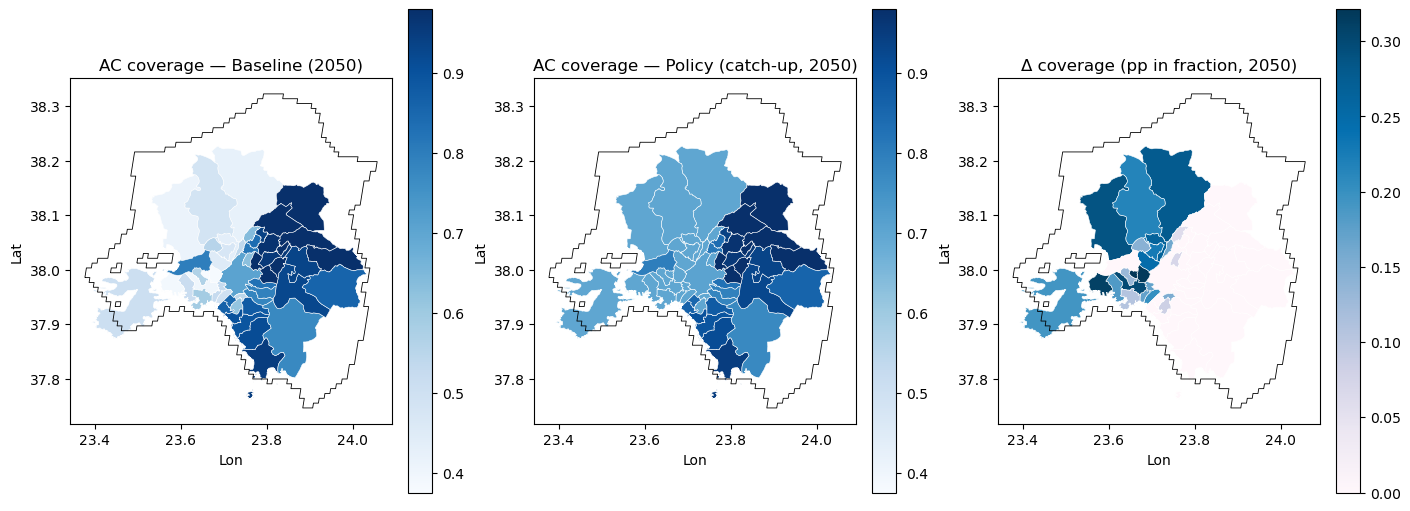

In [39]:
# plot maps
fig, ax = plt.subplots(1,3, figsize=(14,5), constrained_layout=True)

_fua_wgs    = _to_wgs84(fua) if "fua" in globals() else None
_capmap_wgs = _to_wgs84(zone_map)

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[0], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[0], column="ac_base", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True
)
ax[0].set_title(f"AC coverage — Baseline ({YEAR_DIAG})")
ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[1], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[1], column="ac_policy", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True
)
ax[1].set_title(f"AC coverage — Policy (catch-up, {YEAR_DIAG})")
ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[2], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[2], column="delta", cmap="PuBu",
    vmin=0.0, vmax=dv if dv > 0 else None,
    edgecolor="white", lw=0.4, legend=True
)
ax[2].set_title(f"Δ coverage (pp in fraction, {YEAR_DIAG})")
ax[2].set_xlabel("Lon"); ax[2].set_ylabel("Lat")
plt.show()

In [40]:
# tables: top/bottom changes by CAP for this YEAR_DIAG
tbl = (zone_cov.dropna(subset=["delta"])
              .assign(ac_base_pct=lambda d: 100*d["ac_base"],
                      ac_policy_pct=lambda d: 100*d["ac_policy"],
                      delta_pp=lambda d: 100*d["delta"])
              .sort_values(["delta_pp", ZONE_CODE], ascending=[False, True]))

print(f"\nTop Δcoverage zones (year {YEAR_DIAG}):")
top_tbl = tbl[[ZONE_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_zone"]] \
              .head(10).reset_index(drop=True)
if _has_display:
    display(top_tbl)
else:
    print(top_tbl)

print(f"\nBottom (or zero) Δcoverage zones (year {YEAR_DIAG}):")
bot_tbl = (tbl[[ZONE_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_zone"]]
           .tail(10).sort_values("delta_pp").reset_index(drop=True))
if _has_display:
    display(bot_tbl)
else:
    print(bot_tbl)


Top Δcoverage zones (year 2050):
                            zone_code  ac_base_pct  ac_policy_pct  delta_pp  \
0                Δήμος Αγίας Βαρβάρας       37.532         70.000    32.468   
1                       Δήμος Αιγάλεω       38.233         70.000    31.767   
2                     Δήμος Περάματος       38.966         70.000    31.034   
3  Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη       40.086         70.000    29.914   
4                   Δήμος Ασπροπύργου       41.238         70.000    28.762   
5                       Δήμος Αχαρνών       42.264         70.000    27.736   
6   Δήμος Αγίων Αναργύρων – Καματερού       43.545         70.000    26.455   
7                   Δήμος Περιστερίου       45.268         70.000    24.732   
8                         Δήμος Ιλίου       47.291         70.000    22.709   
9                         Δήμος Φυλής       48.520         70.000    21.480   

     pop_zone  
0  23,553.096  
1  65,347.371  
2  26,224.822  
3 111,435.279  
4  27,136.164  


In [41]:
# some checks 
# sets at each stage
caps_csv   = set(inc_agg[ZONE_CODE].astype(str))
caps_shp   = set(zone_4326[ZONE_CODE].astype(str)) # after FUA clip
caps_rast  = set(zone_ref[ZONE_CODE].astype(str))  # after reprojection (same as caps_shp)
ids_on_grid = set(np.unique(zone_on_ref[zone_on_ref > 0]).astype(int))
caps_labeled = set(zone_ref.loc[zone_ref[ZONE_IDCOL].isin(ids_on_grid), ZONE_CODE].astype(str))

# Zones with any pixel under CITY_MASK 
ids_cap_pix  = set(np.unique(zone_on_ref[ZONE_PIX]).astype(int))
caps_cap_pix = set(zone_ref.loc[zone_ref[ZONE_IDCOL].isin(ids_cap_pix), ZONE_CODE].astype(str))

# Zones with >0 modeled pop in ZONE_PIX
df_zonegrid = pd.DataFrame({
    ZONE_IDCOL: zone_on_ref[ZONE_PIX].ravel().astype(int),
    "pop":     pop_on_ref[ZONE_PIX].ravel().astype(float),
})
df_zonegrid = df_zonegrid[df_zonegrid[ZONE_IDCOL] > 0]
pop_by_cap = (df_zonegrid.groupby(ZONE_IDCOL)["pop"].sum()
              .rename("pop_zone").reset_index())
caps_poppos = set(
    zone_ref.merge(pop_by_cap, on=ZONE_IDCOL, how="left")
           .query("pop_zone > 0")[ZONE_CODE].astype(str)
)

# buckets 
missing_in_shapes_or_outside_fua = sorted(caps_csv - caps_shp)
in_shapes_but_no_labeled_pixels  = sorted(caps_shp - caps_labeled)
labeled_but_not_in_CITY_MASK     = sorted(caps_labeled - caps_cap_pix)
in_ZONE_PIX_but_zero_population   = sorted(caps_cap_pix - caps_poppos)

print("CSV zones:", len(caps_csv))
print("After FUA clip (polygons):", len(caps_shp))
print("Labeled on grid (any pixels):", len(caps_labeled))
print("In ZONE_PIX (city mask & labeled):", len(caps_cap_pix))
print(">0 population in ZONE_PIX:", len(caps_poppos))
print()
print("Missing (CSV but not in shapes/FUA):", len(missing_in_shapes_or_outside_fua), missing_in_shapes_or_outside_fua[:10])
print("No labeled pixels (resolution / all_touched=False):", len(in_shapes_but_no_labeled_pixels), in_shapes_but_no_labeled_pixels[:10])
print("Only outside CITY_MASK/hazard or pop==0 area:", len(labeled_but_not_in_CITY_MASK), labeled_but_not_in_CITY_MASK[:10])
print("Zero modeled pop in ZONE_PIX:", len(in_ZONE_PIX_but_zero_population), in_ZONE_PIX_but_zero_population[:10])

CSV zones: 51
After FUA clip (polygons): 61
Labeled on grid (any pixels): 52
In ZONE_PIX (city mask & labeled): 51
>0 population in ZONE_PIX: 51

Missing (CSV but not in shapes/FUA): 0 []
No labeled pixels (resolution / all_touched=False): 9 ['nan', 'Δήμος Ελευσίνας', 'Δήμος Λαυρεωτικής', 'Δήμος Μάνδρας - Ειδυλλίας', 'Δήμος Μαρκόπουλου Μεσογαίας', 'Δήμος Μεγαρέων', 'Δήμος Σαρωνικού', 'Δήμος Τανάγρας', 'Δήμος Ωρωπού']
Only outside CITY_MASK/hazard or pop==0 area: 1 ['Δήμος Μαραθώνος']
Zero modeled pop in ZONE_PIX: 0 []


Small differences between the number of raw income units, the number of polygons, and the number of modeled zones are expected. The final modeled set is the intersection of the income dataset, the selected zone geometry, the clipped policy domain, and the analysis grid. Units with no matched income, no retained area, or no population / grid support may drop out before the policy maps are built.

In [42]:
# Zone-level coverage comparison: baseline, income-targeted policy, and uniform policy.

YEAR_DIAG = 2050  # or 2020/2030/2040/2050
k_diag    = year_to_index[YEAR_DIAG]

cov_base   = coverage_base_3d[k_diag].astype("float32")
cov_income = coverage_policy_3d[k_diag].astype("float32")
cov_unif   = coverage_uniform_3d[k_diag].astype("float32")

ZONE_MASK_diag = (
    ZONE_PIX &
    np.isfinite(cov_base) &
    np.isfinite(cov_income) &
    np.isfinite(cov_unif)
)

# Pop-weighted CAP means from the grid
zone_base   = zone_popw_mean_from(cov_base,   ZONE_MASK_diag, "ac_base")
cap_income = zone_popw_mean_from(cov_income, ZONE_MASK_diag, "ac_policy_income")
cap_unif   = zone_popw_mean_from(cov_unif,   ZONE_MASK_diag, "ac_policy_uniform")

# Zone populations from grid for this YEAR_DIAG
df_zonegrid_diag = pd.DataFrame({
    ZONE_IDCOL: zone_on_ref[ZONE_MASK_diag].ravel().astype(int),
    "pop":     pop_on_ref[ZONE_MASK_diag].ravel().astype(float),
})
df_zonegrid_diag = df_zonegrid_diag[df_zonegrid_diag[ZONE_IDCOL] > 0]
zone_pop_diag = (df_zonegrid_diag.groupby(ZONE_IDCOL, as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_zone"}))

zone_cov_all = (zone_base
               .merge(cap_income, on=ZONE_IDCOL, how="outer")
               .merge(cap_unif,   on=ZONE_IDCOL, how="outer")
               .merge(zone_pop_diag, on=ZONE_IDCOL, how="left")
               .merge(zone_4326[[ZONE_IDCOL, ZONE_CODE]], on=ZONE_IDCOL, how="left"))

zone_cov_all["ac_base_pct"]         = 100*zone_cov_all["ac_base"]
zone_cov_all["ac_policy_income_pct"] = 100*zone_cov_all["ac_policy_income"]
zone_cov_all["ac_policy_uniform_pct"] = 100*zone_cov_all["ac_policy_uniform"]

print(f"Zone coverage summary ({YEAR_DIAG}): baseline vs income vs uniform")
display(
    zone_cov_all[[ZONE_CODE, "ac_base_pct", "ac_policy_income_pct",
                 "ac_policy_uniform_pct", "pop_zone"]]
    .sort_values("ac_policy_uniform_pct")
    .reset_index(drop=True)
    .head(15)
)

# Optional export
zone_cov_all.to_csv(
    INT / f"ac_zone_coverage_allpolicies_{SLUG}_{YEAR_DIAG}.csv",
    index=False
)
print("Wrote Zone coverage CSV for diagnostic year:",
      INT / f"ac_zone_coverage_allpolicies_{SLUG}_{YEAR_DIAG}.csv")

Zone coverage summary (2050): baseline vs income vs uniform


,zone_code,ac_base_pct,ac_policy_income_pct,ac_policy_uniform_pct,pop_zone
0,Δήμος Αγίας Βαρβάρας,37.532,70.000,47.471,"23,553.096"
1,Δήμος Αιγάλεω,38.233,70.000,48.172,"65,347.371"
2,Δήμος Περάματος,38.966,70.000,48.905,"26,224.822"
3,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,40.086,70.000,50.025,"111,435.279"
4,Δήμος Ασπροπύργου,41.238,70.000,51.177,"27,136.164"
5,Δήμος Αχαρνών,42.264,70.000,52.202,"94,086.899"
6,Δήμος Αγίων Αναργύρων – Καματερού,43.545,70.000,53.484,"54,556.452"
7,Δήμος Περιστερίου,45.268,70.000,55.207,"140,988.639"
8,Δήμος Ιλίου,47.291,70.000,57.230,"82,691.742"
9,Δήμος Φυλής,48.520,70.000,58.459,"50,582.488"


Wrote Zone coverage CSV for diagnostic year: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/ac_zone_coverage_allpolicies_athens_2050.csv


**Region-level coverage statistics**

Coverage is also aggregated to the policy-region layer. For Athens, this means the same zone layer (Dimoi).

In [43]:
# Region boundaries already loaded in Section 1.8
# Just verify they're available
assert 'muni_on_ref' in globals(), "muni_on_ref missing — run Section 1.8 first"
assert 'REGION_GDF' in globals(), "REGION_GDF missing — run Section 1.8 first"
assert 'MASK_POLICY' in globals(), "MASK_POLICY missing — run Section 1.8 first"
print(f"[Regions] {PLOT_LABEL}: {len(REGION_GDF)} units, MASK_POLICY pixels: {int(MASK_POLICY.sum()):,}")

[Regions] Zones: 61 units, MASK_POLICY pixels: 60,551


In [44]:
import numpy as np, pandas as pd, geopandas as gpd

def _wavg(x, w):
    w = np.asarray(w, float); x = np.asarray(x, float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

# Region-level coverage stats for all years
all_muni_cov = []

for YEAR_DIAG in YEARS_AC:
    print(f"\n===== Region stats for year {YEAR_DIAG} =====")
    k_diag = year_to_index[YEAR_DIAG]

    coverage_base_diag   = coverage_base_3d[k_diag].astype("float32")
    coverage_policy_diag = coverage_policy_3d[k_diag].astype("float32")

    pop_grid_y = POP_GRID.get(YEAR_DIAG, pop_on_ref_base).astype(float)

    ZONE_MASK_diag = (
        ZONE_PIX &
        np.isfinite(coverage_base_diag) &
        np.isfinite(coverage_policy_diag)
    )

    mask = ZONE_MASK_diag & ANALYSIS_MASK_MUNI
    df = pd.DataFrame({
        "region_id": muni_on_ref[mask].ravel().astype(int),
        "pop":       pop_grid_y[mask].ravel().astype(float),
        "base":      coverage_base_diag[mask].ravel().astype(float),
        "policy":    coverage_policy_diag[mask].ravel().astype(float),
    })

    _grp = df.groupby("region_id")
    muni_cov_y = _grp.apply(lambda g: pd.Series({
        "ac_base":   _wavg(g["base"],   g["pop"]),
        "ac_policy": _wavg(g["policy"], g["pop"]),
        "pop":       g["pop"].sum(),
    }))
    if "region_id" in muni_cov_y.columns:
        muni_cov_y = muni_cov_y.reset_index(drop=True)
    else:
        muni_cov_y = muni_cov_y.reset_index()
    muni_cov_y["year"] = YEAR_DIAG

    # merge region names
    region_lut = REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD]].drop_duplicates()
    muni_cov_y = muni_cov_y.merge(
        region_lut.rename(columns={REGION_ID_FIELD: "region_id", REGION_NAME_FIELD: "region_name"}),
        on="region_id", how="left"
    )

    all_muni_cov.append(muni_cov_y)
    print(f"  Regions with data: {len(muni_cov_y)}")

all_muni_cov_df = pd.concat(all_muni_cov, ignore_index=True)
print(f"\nTotal region-year rows: {len(all_muni_cov_df)}")


===== Region stats for year 2020 =====
  Regions with data: 51

===== Region stats for year 2030 =====
  Regions with data: 51

===== Region stats for year 2040 =====
  Regions with data: 51

===== Region stats for year 2050 =====
  Regions with data: 51

Total region-year rows: 204


In [45]:
# Region coverage including UNIFORM AC policy

def _wavg(x, w):
    w = np.asarray(w, float); x = np.asarray(x, float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

all_muni_cov_allpol = []

for YEAR_DIAG in YEARS_AC:
    print(f"\n===== Regions (all policies) for year {YEAR_DIAG} =====")
    k_diag = year_to_index[YEAR_DIAG]

    cov_base_y   = coverage_base_3d[k_diag].astype("float32")
    cov_income_y = coverage_policy_3d[k_diag].astype("float32")
    cov_unif_y   = coverage_uniform_3d[k_diag].astype("float32")

    pop_grid_y = POP_GRID.get(YEAR_DIAG, pop_on_ref_base).astype(float)

    ZONE_MASK_diag = (
        ZONE_PIX &
        np.isfinite(cov_base_y) &
        np.isfinite(cov_income_y) &
        np.isfinite(cov_unif_y)
    )

    mask = ZONE_MASK_diag & (muni_on_ref >= 0)

    df = pd.DataFrame({
        "muni_id": muni_on_ref[mask].ravel().astype(int),
        "pop":     pop_grid_y[mask].ravel().astype(float),
        "base":    cov_base_y[mask].ravel().astype(float),
        "income":  cov_income_y[mask].ravel().astype(float),
        "uniform": cov_unif_y[mask].ravel().astype(float),
    })

    if df.empty:
        print(f"  !!! df is EMPTY for this year, skipping")
        continue

    _grp = df.groupby("muni_id")
    muni_cov_y = _grp.apply(lambda g: pd.Series({
        "ac_base_muni":       _wavg(g["base"],    g["pop"]),
        "ac_policy_muni":     _wavg(g["income"],  g["pop"]),
        "ac_policy_uniform":  _wavg(g["uniform"], g["pop"]),
        "pop_muni":           g["pop"].sum(),
    }))
    if "muni_id" in muni_cov_y.columns:
        muni_cov_y = muni_cov_y.reset_index(drop=True)
    else:
        muni_cov_y = muni_cov_y.reset_index()
    muni_cov_y["year"] = YEAR_DIAG

    # merge region names
    region_lut = REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD]].drop_duplicates()
    muni_cov_y = muni_cov_y.merge(
        region_lut.rename(columns={REGION_ID_FIELD: "muni_id", REGION_NAME_FIELD: "region_name"}),
        on="muni_id", how="left"
    )

    all_muni_cov_allpol.append(muni_cov_y)
    print(f"  Regions: {len(muni_cov_y)}")

if all_muni_cov_allpol:
    all_muni_cov_allpol_df = pd.concat(all_muni_cov_allpol, ignore_index=True)
    print(f"\nTotal region-year rows (all policies): {len(all_muni_cov_allpol_df)}")

    # Save for Section 7 (waste heat) and NB8
    muni_cov_yearly_path = OUT / f"{SLUG}_muni_cov_yearly.csv"
    all_muni_cov_allpol_df.to_csv(muni_cov_yearly_path, index=False)
    print(f"Saved: {muni_cov_yearly_path}")
else:
    print("WARNING: no region coverage data produced")


===== Regions (all policies) for year 2020 =====
  Regions: 51

===== Regions (all policies) for year 2030 =====
  Regions: 51

===== Regions (all policies) for year 2040 =====
  Regions: 51

===== Regions (all policies) for year 2050 =====
  Regions: 51

Total region-year rows (all policies): 204
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/athens_muni_cov_yearly.csv


## 4. Benefits calculation (mortality model, baseline / policy deaths)

This is the core adaptation calculation. The year-specific IFs loaded from `NB04` already contain the baseline-mortality scaling by year. `NB05` then applies AC as a multiplicative protection term on top of those IFs: daily deaths are attenuated by `1 - efficacy_age × coverage`. Three AC states are tracked: a generic no-AC counterfactual, the **current AC baseline**, and the policy AC scenario. Throughout the notebook, the current-AC baseline is the main reference for policy benefits.

### 4.1 Mortality model setup

The mortality model combines four ingredients: the daily `T2M` hazard, the year-specific age-structured populations, the year-specific IFs imported from `NB04`, and the AC attenuation rule. The IFs are not rebuilt here. Instead, `NB05` reduces the effective heat-mortality response according to local AC coverage and the configured efficacy assumptions, which can vary by age group.

In [46]:
# NB04 already supplies the year-specific IFs; NB05 adds AC attenuation on top of them.
EFF_MAP = globals().get("EFF_BUCKETS", None)
if not isinstance(EFF_MAP, dict) or len(EFF_MAP) == 0:
    EFF_MAP = cfg.get("efficacy", {}) if "cfg" in globals() else {}

EFF_DEFAULT = float(globals().get("EFF_DEFAULT", EFF_MAP.get("default", 0.30)))

In [47]:
print("EFF_SCENARIO =", globals().get("EFF_SCENARIO", "(not set in globals)"))
print("EFF_DEFAULT  =", EFF_DEFAULT)
print("EFF_MAP      =", {k: EFF_MAP.get(k) for k in ["<15","15-64","65+"]})

EFF_SCENARIO = moderate
EFF_DEFAULT  = 0.3
EFF_MAP      = {'<15': 0.2, '15-64': 0.3, '65+': 0.4}


In [48]:
# Region config for mortality calculations — reuse from Section 1.8
# REGION_GDF, REGION_ID_FIELD, REGION_NAME_FIELD already set in Section 1.8
mask_city = CITY_MASK

_id2name = dict(
    zip(
        REGION_GDF[REGION_ID_FIELD].astype(int),
        REGION_GDF[REGION_NAME_FIELD].astype(str),
    )
)

print(f"[Mortality] Using {PLOT_LABEL}: {len(REGION_GDF)} regions")
print(f"  ID field: {REGION_ID_FIELD}, Name field: {REGION_NAME_FIELD}")

[Mortality] Using Zones: 61 regions
  ID field: muni_id, Name field: muni_name


In [49]:
mask_city = CITY_MASK

In [50]:
# Convert hazard intensity to daily deaths after attenuating the NB04 mdd(T) curves by AC coverage and efficacy.
def _interp_mdd(I_grid, f):
    return np.interp(I_grid, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

def _eff_for_age(age_lbl, eff_map, eff_default):
    if age_lbl in eff_map:
        return float(eff_map[age_lbl])
    for k, v in eff_map.items():
        if k == "default":
            continue
        if k in str(age_lbl):
            return float(v)
    return float(eff_default)

def deaths_with_ac(I_grid, coverage_grid, eff=0.30, age_ifs=None):
    """Uniform efficacy, one day."""
    # using provided age_ifs or falling back to global reference year
    if age_ifs is None:
        age_ifs = age_ifs_by_year[MDD_REF_YEAR]
    
    m = mask_city & np.isfinite(I_grid)

    # Fill missing coverage inside the city with the population-weighted mean coverage for that grid.
    ac_city_here = float(popw_mean(coverage_grid, CAP_MASK))

    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city_here)
    deaths = np.zeros_like(I_grid, dtype=float)
    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        mult = np.clip(1.0 - eff * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def deaths_with_ac_varage(I_grid, coverage_grid, eff_by_bucket=None, eff_base=None, age_ifs=None):
    """Age-varying efficacy, one day."""
    # using provided age_ifs or falling back to global reference year
    if age_ifs is None:
        age_ifs = age_ifs_by_year[MDD_REF_YEAR]
    
    eff_map = (eff_by_bucket or EFF_MAP).copy()
    eff_def = EFF_DEFAULT if eff_base is None else float(eff_base)

    m = mask_city & np.isfinite(I_grid)
    ac_city_here = float(popw_mean(coverage_grid, CAP_MASK))
    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city_here)
    deaths = np.zeros_like(I_grid, dtype=float)

    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        eff_a = _eff_for_age(age_lbl, eff_map, eff_def)
        mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def _row_to_grid(intensity, i_ev, grid_shape):
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()

    n_cells  = row.size
    expected = grid_shape[0] * grid_shape[1]

    if n_cells == expected:
        return row.reshape(grid_shape)
    if n_cells == 1:
        val = row[0]
        return np.full(grid_shape, val, dtype=float)

    raise ValueError(f"Row size {n_cells} != grid cells {expected} and != 1")

### 4.2 Impact calculation and EWS preparation

This block computes deaths under the generic, current-AC, and policy-AC states; aggregates avoided deaths at city and region level; and also calibrates the deaths-based EWS trigger that `NB06` will use. The threshold is based on modeled daily city heat deaths under the baseline-AC scenario, using the warning season and target number of activation days defined in the city config. A second "climate-only" calibration freezes vulnerability at the baseline year for diagnostic comparison.

In [51]:
# Prepare deaths-based EWS threshold calibration using the baseline-AC mortality series.
import json
import numpy as np
import pandas as pd
import calendar
from pathlib import Path

# Resolve EWS settings from the city config (fallbacks keep backward compatibility).
ews_cfg = cfg.get("ews", {}) if isinstance(globals().get("cfg"), dict) else {}
TARGET_ACTIV_DAYS = int(ews_cfg.get("target_activation_days", 23))
BASELINE_YEAR_FOR_CALIB = int(ews_cfg.get("threshold_ref_year", 2020))

def _resolve_warning_season(ews_cfg: dict):
    ws = ews_cfg.get("warning_season", {}) or {}
    start_md = ws.get("start_md")
    end_md = ws.get("end_md")
    mode = str(ws.get("mode", "")).strip().lower() or "exact_dates"

    if start_md and end_md:
        return {
            "mode": mode,
            "start_md": str(start_md),
            "end_md": str(end_md),
            "source": "warning_season",
        }

    months = ews_cfg.get("warning_months", [5, 6, 7, 8, 9]) or [5, 6, 7, 8, 9]
    months = sorted({int(m) for m in months if 1 <= int(m) <= 12})
    if not months:
        months = [5, 6, 7, 8, 9]

    start_m = months[0]
    end_m = months[-1]
    end_day = calendar.monthrange(2001, end_m)[1]
    return {
        "mode": "derived_from_months",
        "start_md": f"{start_m:02d}-01",
        "end_md": f"{end_m:02d}-{end_day:02d}",
        "months": months,
        "source": "warning_months_fallback",
    }

WARNING_SEASON = _resolve_warning_season(ews_cfg)
SEASON_START_MD = WARNING_SEASON["start_md"]
SEASON_END_MD = WARNING_SEASON["end_md"]
SEASON_LABEL = f"{SEASON_START_MD} to {SEASON_END_MD}"

print(f"[EWS threshold calibration] target_activation_days={TARGET_ACTIV_DAYS}")
print(f"[EWS threshold calibration] warning season={SEASON_LABEL} ({WARNING_SEASON['source']})")

def season_mask(dates_dt: pd.DatetimeIndex,
                start_md: str = "05-01",
                end_md: str = "09-30") -> np.ndarray:
    """Mask dates in [start_md, end_md] within each date's year."""
    dates_dt = pd.to_datetime(dates_dt)
    if isinstance(dates_dt, pd.Series):
        y = dates_dt.dt.year.astype(str)
    else:
        y = pd.Index(dates_dt).year.astype(str)
    start = pd.to_datetime(y + "-" + start_md)
    end   = pd.to_datetime(y + "-" + end_md)
    return np.asarray((dates_dt >= start) & (dates_dt <= end), dtype=bool)

def pick_threshold_closest(values: np.ndarray, target: int, prefer_higher=True):
    """
    Picking a threshold among observed values so that count(values >= thr)
    is as close as possible to target. If tie, prefer higher threshold
    (i.e., slightly fewer activations).
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        raise ValueError("No finite values for threshold calibration.")
    uniq = np.unique(v)
    s = np.sort(v)

    left = np.searchsorted(s, uniq, side="left")
    counts_ge = len(s) - left

    diff = np.abs(counts_ge - target)
    best = np.where(diff == diff.min())[0]
    idx = best[-1] if prefer_higher else best[0]

    return float(uniq[idx]), int(counts_ge[idx])

def calibrate_ews_threshold_from_deaths(dates_dt, city_deaths, target_days=None,
                                       season_start_md=None, season_end_md=None):
    dates_dt = pd.to_datetime(dates_dt)
    city_deaths = np.asarray(city_deaths, dtype=float)

    if target_days is None:
        target_days = TARGET_ACTIV_DAYS
    if season_start_md is None:
        season_start_md = SEASON_START_MD
    if season_end_md is None:
        season_end_md = SEASON_END_MD

    m = season_mask(dates_dt, season_start_md, season_end_md)
    thr, achieved = pick_threshold_closest(city_deaths[m], int(target_days), prefer_higher=True)
    active = (city_deaths >= thr) & m
    return thr, int(active.sum()), int(m.sum()), active


[EWS threshold calibration] target_activation_days=23
[EWS threshold calibration] warning season=05-01 to 09-30 (warning_season)


In [52]:
# Run baseline and policy mortality with year-specific IFs, and export the EWS-threshold inputs for NB06.
EFF_UNIFORM = EFF_DEFAULT
EFF_BUCKETS = EFF_MAP

dates = pd.to_datetime(H.date)

# Run the baseline year first so the threshold JSON exists before later years are processed.
YEARS_IMPACT = sorted(YEARS_AC)  # [2020, 2030, 2040, 2050]

results_city   = []
results_muni_u = []
results_muni_a = []

for year_focus in YEARS_IMPACT:
    print(f"\n===== Year {year_focus} =====")

    # year-specific population
    age_on_ref = AGE_GRID.get(year_focus, age_on_ref_base)
    pop_on_ref = POP_GRID.get(year_focus, pop_on_ref_base)

    # Year-specific impact functions imported from NB04 (already scaled there).
    age_ifs_year = get_age_ifs(year_focus)

    # Current-AC baseline and policy coverage maps for this year.
    k = year_to_index[year_focus]
    coverage_base_y   = coverage_base_3d[k].astype(float)
    coverage_policy_y = coverage_policy_3d[k].astype(float)

    CAP_MASK = ZONE_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # Hazard events for this year
    year_mask = (dates.year == year_focus)
    idx_year  = np.where(year_mask)[0]
    if idx_year.size == 0:
        print(f"  (no hazard events for {year_focus})")
        continue

    I_year = np.stack(
        [_row_to_grid(H.intensity, i_ev, ref_data.shape) for i_ev in idx_year],
        axis=0
    )

    # Daily deaths under the different AC states, using the year-specific IFs.
    def deaths_series_uniform(I_series, coverage_grid, eff, age_ifs):
        out = np.zeros_like(I_series, dtype=float)
        for t in range(I_series.shape[0]):
            out[t] = deaths_with_ac(I_series[t], coverage_grid, eff=eff, age_ifs=age_ifs)
        return out

    def deaths_series_agevary(I_series, coverage_grid, eff_by_bucket, eff_base, age_ifs):
        out = np.zeros_like(I_series, dtype=float)
        for t in range(I_series.shape[0]):
            out[t] = deaths_with_ac_varage(
                I_series[t], coverage_grid,
                eff_by_bucket=eff_by_bucket, eff_base=eff_base, age_ifs=age_ifs
            )
        return out

    deaths_base_uni_day   = deaths_series_uniform(I_year, coverage_base_y,   eff=EFF_UNIFORM, age_ifs=age_ifs_year)
    deaths_policy_uni_day = deaths_series_uniform(I_year, coverage_policy_y, eff=EFF_UNIFORM, age_ifs=age_ifs_year)

    deaths_base_age_day   = deaths_series_agevary(I_year, coverage_base_y,   eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM, age_ifs=age_ifs_year)
    deaths_policy_age_day = deaths_series_agevary(I_year, coverage_policy_y, eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM, age_ifs=age_ifs_year)

    # Calibrate and count EWS activation days using modeled daily city heat deaths.
    # The EWS metric is city-total daily heat deaths under baseline AC with age-varying efficacy.

    dates_year  = dates[idx_year]  # aligned with I_year / deaths_*_day
    city_deaths = np.nansum(deaths_base_age_day, axis=(1, 2))

    thr_file = INT / f"ews_threshold_deaths_{SLUG}.json"

    # Calibrate the threshold once on the baseline year, then reuse it for the other years.
    if year_focus == BASELINE_YEAR_FOR_CALIB:
        thr_deaths, achieved_days, season_days, active_mask = calibrate_ews_threshold_from_deaths(
            dates_year, city_deaths,
            target_days=TARGET_ACTIV_DAYS,
            season_start_md=SEASON_START_MD,
            season_end_md=SEASON_END_MD
        )

        print("\n[EWS calibration]")
        print(f"  Baseline year: {BASELINE_YEAR_FOR_CALIB}")
        print(f"  Season: {SEASON_START_MD} to {SEASON_END_MD} (season days = {season_days})")
        print(f"  Target activation days: {TARGET_ACTIV_DAYS}")
        print(f"  Threshold (city heat deaths/day): {thr_deaths:.6g}")
        print(f"  Achieved activation days: {achieved_days}")

        ews_out = {
            "city_slug": SLUG,
            "metric": "city_total_heat_deaths_per_day",
            "baseline_year": int(BASELINE_YEAR_FOR_CALIB),
            "target_activation_days": int(TARGET_ACTIV_DAYS),
            "season_start_md": SEASON_START_MD,
            "season_end_md": SEASON_END_MD,
            "threshold_deaths_per_day": float(thr_deaths),
            "achieved_activation_days_baseline": int(achieved_days),
            "notes": "Calibrated on baseline modeled daily heat deaths (NB4 scaled IF + NB5 baseline AC attenuation)."
        }
        with open(thr_file, "w") as f:
            json.dump(ews_out, f, indent=2)
        print(f"  Saved: {thr_file}")

    # Count activation days for every year using the calibrated threshold.
    if thr_file.exists():
        thr_deaths_loaded = json.load(open(thr_file))["threshold_deaths_per_day"]
        m = season_mask(pd.to_datetime(dates_year), SEASON_START_MD, SEASON_END_MD)
        activ_days = int(((city_deaths >= thr_deaths_loaded) & m).sum())
        print(f"  EWS activation days in {year_focus} (deaths>=thr): {activ_days}")
    else:
        print("  (EWS threshold not yet available — run baseline year first)")

    # Aggregate annual baseline, policy, and avoided deaths for this year.

    deaths_base_uni   = deaths_base_uni_day.sum(axis=0)
    deaths_policy_uni = deaths_policy_uni_day.sum(axis=0)
    deaths_base_age   = deaths_base_age_day.sum(axis=0)
    deaths_policy_age = deaths_policy_age_day.sum(axis=0)

    d_avo_uni = deaths_base_uni - deaths_policy_uni
    d_avo_age = deaths_base_age - deaths_policy_age

    # No post-hoc mortality scaling here: the IFs already embed the NB04 baseline-mortality scaling.
    city_total_avo_uni = float(np.nansum(d_avo_uni[mask_city]))
    city_total_avo_age = float(np.nansum(d_avo_age[mask_city]))

    print(f"City avoided deaths (uniform eff) in {year_focus}: {city_total_avo_uni:.3f}")
    print(f"City avoided deaths (age-varying eff) in {year_focus}: {city_total_avo_age:.3f}")

    # municipio delta AC and efficiency for this year
    df = pd.DataFrame({
        "muni_id":  muni_on_ref[CAP_MASK].ravel().astype(int),
        "pop":      pop_on_ref[CAP_MASK].ravel().astype(float),
        "base":     coverage_base_y[CAP_MASK].ravel().astype(float),
        "policy":   coverage_policy_y[CAP_MASK].ravel().astype(float),
    })

    df_muni_delta = (
        df.assign(delta=df["policy"] - df["base"])
          .groupby("muni_id", as_index=False)
          .apply(lambda g: pd.Series({
              "ΔAC_pw":       float(np.average(g["delta"], weights=g["pop"])) if g["pop"].sum() > 0 else np.nan,
              "pop_zone_mask": float(g["pop"].sum()),
          }))
          .reset_index(drop=True)
    )
    df_muni_delta["muni_name"] = df_muni_delta["muni_id"].map(_id2name)

    city_dpp_from_muni = 100.0 * (
        (df_muni_delta["ΔAC_pw"] * df_muni_delta["pop_zone_mask"]).sum()
        / df_muni_delta["pop_zone_mask"].sum()
    )
    city_dpp_from_map = 100.0 * popw_mean(coverage_policy_y - coverage_base_y, mask=CAP_MASK)
    print("City ΔAC (pp) from municipios vs map:", city_dpp_from_muni, city_dpp_from_map)

    # municipio-level avoided deaths for this year (uniform vs age-varying)
    mask_muni = CAP_MASK & (muni_on_ref >= 0)

    df_u = pd.DataFrame({
        "muni_id":     muni_on_ref[mask_muni].ravel().astype(int),
        "avoided":     d_avo_uni[mask_muni].ravel().astype(float),
        "deaths_base": deaths_base_uni[mask_muni].ravel().astype(float),
        "pop":         pop_on_ref[mask_muni].ravel().astype(float),
    })

    df_a = pd.DataFrame({
        "muni_id":     muni_on_ref[mask_muni].ravel().astype(int),
        "avoided":     d_avo_age[mask_muni].ravel().astype(float),
        "deaths_base": deaths_base_age[mask_muni].ravel().astype(float),
        "pop":         pop_on_ref[mask_muni].ravel().astype(float),
    })

    def _agg_muni(df_):
        out = (df_.groupby("muni_id", as_index=False)
                  .agg(avoided=("avoided", "sum"),
                       deaths_base=("deaths_base", "sum"),
                       pop_muni=("pop", "sum")))
        out["avo_per_100k"] = np.where(
            out["pop_muni"] > 0,
            1e5 * out["avoided"] / out["pop_muni"],
            np.nan
        )
        return out

    df_muni_avo_uni = _agg_muni(df_u)
    df_muni_avo_age = _agg_muni(df_a)

    df_muni_avo_uni["muni_name"] = df_muni_avo_uni["muni_id"].map(_id2name)
    df_muni_avo_age["muni_name"] = df_muni_avo_age["muni_id"].map(_id2name)

    MIN_PP = 0.5
    muni_eff_uni = (df_muni_avo_uni.merge(df_muni_delta, on=["muni_id", "muni_name"], how="left")
                    .assign(delta_pp=lambda d: 100 * d["ΔAC_pw"],
                            avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"] > 0, d["delta_pp"], np.nan),
                            flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

    muni_eff_age = (df_muni_avo_age.merge(df_muni_delta, on=["muni_id", "muni_name"], how="left")
                    .assign(delta_pp=lambda d: 100 * d["ΔAC_pw"],
                            avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"] > 0, d["delta_pp"], np.nan),
                            flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

    print("Top municipios (avoided per pp uplift) — uniform EFF:")
    display(muni_eff_uni.sort_values("avoided_per_pp", ascending=False)
            [["muni_id", "muni_name", "avoided", "avo_per_100k", "delta_pp", "avoided_per_pp"]]
            .head(10).reset_index(drop=True))

    print("Top municipios (avoided per pp uplift) — age-varying EFF:")
    display(muni_eff_age.sort_values("avoided_per_pp", ascending=False)
            [["muni_id", "muni_name", "avoided", "avo_per_100k", "delta_pp", "avoided_per_pp"]]
            .head(10).reset_index(drop=True))

    results_city.append({
        "year": year_focus,
        "city_total_avo_uni": city_total_avo_uni,
        "city_total_avo_age": city_total_avo_age,
    })
    results_muni_u.append(muni_eff_uni.assign(year=year_focus))
    results_muni_a.append(muni_eff_age.assign(year=year_focus))

# tables (after loop)
results_city = pd.DataFrame(results_city).set_index("year").sort_index()
muni_eff_uni_all = pd.concat(results_muni_u, ignore_index=True)
muni_eff_age_all = pd.concat(results_muni_a, ignore_index=True)


===== Year 2020 =====



[EWS calibration]
  Baseline year: 2020
  Season: 05-01 to 09-30 (season days = 153)
  Target activation days: 23
  Threshold (city heat deaths/day): 17.1189
  Achieved activation days: 23
  Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/ews_threshold_deaths_athens.json
  EWS activation days in 2020 (deaths>=thr): 23
City avoided deaths (uniform eff) in 2020: 48.067
City avoided deaths (age-varying eff) in 2020: 61.861
City ΔAC (pp) from municipios vs map: 8.70103700073659 8.701037000736589
Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,50,Δήμος Περιστερίου,8.037,5.701,25.409,0.316
1,26,Δήμος Καλλιθέας,4.589,4.833,20.872,0.220
2,47,Δήμος Πειραιώς,2.308,1.308,11.678,0.198
3,24,Δήμος Ιλίου,3.777,4.568,23.420,0.161
4,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,4.749,4.262,30.504,0.156
5,7,Δήμος Αιγάλεω,4.929,7.543,32.326,0.152
6,15,Δήμος Γαλατσίου,0.995,1.609,8.015,0.124
7,51,Δήμος Πετρούπολης,1.655,2.525,15.185,0.109
8,41,Δήμος Νέας Φιλαδέλφειας - Νέας Χαλκηδόνας,1.843,4.002,17.044,0.108
9,4,Δήμος Αγίου Δημητρίου,0.904,1.432,9.277,0.097


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,50,Δήμος Περιστερίου,10.334,7.330,25.409,0.407
1,26,Δήμος Καλλιθέας,5.938,6.253,20.872,0.284
2,47,Δήμος Πειραιώς,2.990,1.695,11.678,0.256
3,24,Δήμος Ιλίου,4.842,5.856,23.420,0.207
4,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,6.128,5.500,30.504,0.201
5,7,Δήμος Αιγάλεω,6.365,9.740,32.326,0.197
6,15,Δήμος Γαλατσίου,1.280,2.070,8.015,0.160
7,41,Δήμος Νέας Φιλαδέλφειας - Νέας Χαλκηδόνας,2.378,5.161,17.044,0.140
8,51,Δήμος Πετρούπολης,2.114,3.227,15.185,0.139
9,4,Δήμος Αγίου Δημητρίου,1.161,1.839,9.277,0.125


...


===== Year 2050 =====


  EWS activation days in 2050 (deaths>=thr): 44
City avoided deaths (uniform eff) in 2050: 57.630
City avoided deaths (age-varying eff) in 2050: 75.900
City ΔAC (pp) from municipios vs map: 8.2436578219089 8.2436578219089
Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,50,Δήμος Περιστερίου,9.412,7.731,24.732,0.381
1,26,Δήμος Καλλιθέας,5.307,6.395,20.117,0.264
2,47,Δήμος Πειραιώς,2.804,1.717,10.766,0.260
3,24,Δήμος Ιλίου,4.622,6.229,22.709,0.204
4,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,5.845,5.910,29.914,0.195
5,7,Δήμος Αιγάλεω,5.617,10.193,31.767,0.177
6,15,Δήμος Γαλατσίου,1.065,1.974,7.040,0.151
7,51,Δήμος Πετρούπολης,1.987,3.383,14.333,0.139
8,41,Δήμος Νέας Φιλαδέλφειας - Νέας Χαλκηδόνας,2.179,5.277,16.224,0.134
9,4,Δήμος Αγίου Δημητρίου,1.075,1.833,8.324,0.129


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,50,Δήμος Περιστερίου,12.390,10.178,24.732,0.501
1,26,Δήμος Καλλιθέας,7.001,8.437,20.117,0.348
2,47,Δήμος Πειραιώς,3.702,2.267,10.766,0.344
3,24,Δήμος Ιλίου,6.079,8.192,22.709,0.268
4,42,Δήμος Νίκαιας - Αγίου Ιωάννη Ρέντη,7.707,7.792,29.914,0.258
5,7,Δήμος Αιγάλεω,7.405,13.437,31.767,0.233
6,15,Δήμος Γαλατσίου,1.403,2.600,7.040,0.199
7,51,Δήμος Πετρούπολης,2.611,4.444,14.333,0.182
8,41,Δήμος Νέας Φιλαδέλφειας - Νέας Χαλκηδόνας,2.872,6.955,16.224,0.177
9,4,Δήμος Αγίου Δημητρίου,1.415,2.414,8.324,0.170


In [53]:
# Climate-only EWS diagnostics: freeze vulnerability at the baseline year and let only the hazard vary.
# Also compute baseline diagnostics on percentiles and activation-day extremeness.

# Run the baseline year first so the climate-only threshold can be calibrated once.
YEARS_IMPACT_CLIM = sorted(YEARS_AC)

# Freeze all vulnerability inputs to the baseline year.
BASE_Y = BASELINE_YEAR_FOR_CALIB
k0 = year_to_index[BASE_Y]

age_on_ref_fixed = AGE_GRID.get(BASE_Y, age_on_ref_base)
pop_on_ref_fixed = POP_GRID.get(BASE_Y, pop_on_ref_base)
age_ifs_fixed    = get_age_ifs(BASE_Y)

coverage_base_fixed   = coverage_base_3d[k0].astype(float)
coverage_policy_fixed = coverage_policy_3d[k0].astype(float)

# Use a separate threshold file for the climate-only run.
thr_file_clim = INT / f"ews_threshold_deaths_{SLUG}_climate_only.json"

# Store activation-day counts for the climate-only run.
ews_clim_counts = []

for year_focus in YEARS_IMPACT_CLIM:
    print(f"\n===== [CLIMATE-ONLY] Year {year_focus} =====")

    # freezing vulnerability 
    age_on_ref   = age_on_ref_fixed
    pop_on_ref   = pop_on_ref_fixed
    age_ifs_year = age_ifs_fixed

    coverage_base_y   = coverage_base_fixed
    coverage_policy_y = coverage_policy_fixed

    CAP_MASK = ZONE_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # Hazard events for this year (hazard still varies by year_focus) 
    year_mask = (dates.year == year_focus)
    idx_year  = np.where(year_mask)[0]
    if idx_year.size == 0:
        print(f"  (no hazard events for {year_focus})")
        continue

    I_year = np.stack(
        [_row_to_grid(H.intensity, i_ev, ref_data.shape) for i_ev in idx_year],
        axis=0
    )

    # Compute daily deaths using frozen vulnerability 
    deaths_base_age_day = np.zeros_like(I_year, dtype=float)
    for t in range(I_year.shape[0]):
        deaths_base_age_day[t] = deaths_with_ac_varage(
            I_year[t], coverage_base_y,
            eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM, age_ifs=age_ifs_year
        )

    # Daily city deaths (metric used for EWS trigger) 
    dates_year  = dates[idx_year]
    city_deaths = np.nansum(deaths_base_age_day, axis=(1, 2))

    # Calibrate threshold on baseline hazard year (2020) 
    if year_focus == BASE_Y:
        thr_deaths, achieved_days, season_days, active_mask = calibrate_ews_threshold_from_deaths(
            dates_year, city_deaths,
            target_days=TARGET_ACTIV_DAYS,
            season_start_md=SEASON_START_MD,
            season_end_md=SEASON_END_MD
        )

        print("\n[EWS calibration — CLIMATE-ONLY]")
        print(f"  Baseline year: {BASE_Y}")
        print(f"  Season: {SEASON_START_MD} to {SEASON_END_MD} (season days = {season_days})")
        print(f"  Target activation days: {TARGET_ACTIV_DAYS}")
        print(f"  Threshold (city heat deaths/day): {thr_deaths:.6g}")
        print(f"  Achieved activation days: {achieved_days}")

        ews_out = {
            "city_slug": SLUG,
            "metric": "city_total_heat_deaths_per_day",
            "baseline_year": int(BASE_Y),
            "target_activation_days": int(TARGET_ACTIV_DAYS),
            "season_start_md": SEASON_START_MD,
            "season_end_md": SEASON_END_MD,
            "threshold_deaths_per_day": float(thr_deaths),
            "mode": "climate_only_frozen_vulnerability_2020",
            "frozen_inputs": {
                "population": BASE_Y,
                "age_grid": BASE_Y,
                "impact_functions": BASE_Y,
                "ac_coverage_base": BASE_Y,
                "ac_coverage_policy": BASE_Y
            }
        }
        with open(thr_file_clim, "w") as f:
            json.dump(ews_out, f, indent=2)
        print(f"  Saved: {thr_file_clim}")

        # Diagnostics: how extreme are activation days? (baseline only)
        # (ALIGNED with the exact series used for calibration)

        thr_loaded = json.load(open(thr_file_clim))["threshold_deaths_per_day"]

        # using SAME season definition as calibration
        m_season = season_mask(pd.to_datetime(dates_year), SEASON_START_MD, SEASON_END_MD)

        # same deaths series as calibration
        D_all = city_deaths
        D = D_all[m_season]

        # temp diagnostic (city-mean of hazard grid)
        # I_year is hazard grid (degC), average over the city mask for each day
        T_all = np.array([float(np.nanmean(I_year[t][mask_city])) for t in range(I_year.shape[0])])
        T = T_all[m_season]

        active = (D_all >= thr_loaded) & m_season
        D_act = D_all[active]
        T_act = T_all[active]

        print(f"\n=== BASELINE (2020) {SEASON_LABEL} percentiles [ALIGNED WITH CALIBRATION] ===")

        pct_list = [1, 5, 10, 25, 50, 75, 90, 95, 99]
        def pct(x):
            return pd.Series({f"p{p:02d}": np.nanpercentile(x, p) for p in pct_list})

        print(f"\nCity heat deaths/day ({SEASON_LABEL}):")
        display(pct(D).to_frame("Deaths/day"))

        print(f"\nCity-mean T2M (°C) ({SEASON_LABEL}):")
        display(pct(T).to_frame("T2M (°C)"))

        print("\n=== Activation-day diagnostics ===")
        print(f"Threshold (deaths/day): {thr_loaded:.4f}")
        print(f"Activated days ({SEASON_LABEL}): {int(active.sum())} out of {int(m_season.sum())}  (target={TARGET_ACTIV_DAYS})")

        print("\nMeans:")
        print(f"  Mean deaths/day, all {SEASON_LABEL}: {np.nanmean(D):.3f}")
        print(f"  Mean deaths/day, activated:   {np.nanmean(D_act):.3f}")
        print(f"  Mean T2M (°C), all {SEASON_LABEL}:   {np.nanmean(T):.3f}")
        print(f"  Mean T2M (°C), activated:     {np.nanmean(T_act):.3f}")

        thr_rank = 100.0 * (np.sum(D < thr_loaded) / np.sum(np.isfinite(D)))
        print(f"\nThreshold is at ~{thr_rank:.1f}th percentile of {SEASON_LABEL} deaths distribution.")
        if len(T_act) > 0:
            t_rank_med = 100.0 * (np.sum(T < np.nanmedian(T_act)) / np.sum(np.isfinite(T)))
            print(f"Median activation-day temperature is at ~{t_rank_med:.1f}th percentile of {SEASON_LABEL} temperature distribution.")

        df_diag = pd.DataFrame({
            "date": pd.to_datetime(dates_year),
            "T2M_mean": T_all,
            "deaths_city": D_all,
            "in_season": m_season,
            "active": active
        }).query("in_season").sort_values("T2M_mean", ascending=False)

        print(f"\nTop 10 hottest days in {SEASON_LABEL} (baseline) with activation flag:")
        display(df_diag.head(10).reset_index(drop=True))

    # Activation count using saved climate-only threshold (all years) 
    if thr_file_clim.exists():
        thr_loaded = json.load(open(thr_file_clim))["threshold_deaths_per_day"]
        m = season_mask(pd.to_datetime(dates_year), SEASON_START_MD, SEASON_END_MD)
        activ_days = int(((city_deaths >= thr_loaded) & m).sum())
        print(f"  EWS activation days in {year_focus} [CLIMATE-ONLY]: {activ_days}")
        ews_clim_counts.append({"year": year_focus, "activation_days_climate_only": activ_days})
    else:
        print("  (Climate-only threshold not yet available — run baseline year first)")

# Save activation counts table
ews_clim_counts = pd.DataFrame(ews_clim_counts).set_index("year").sort_index()
out_csv = INT / f"ews_activation_days_{SLUG}_climate_only.csv"
ews_clim_counts.to_csv(out_csv)
print("\nSaved climate-only activation table:", out_csv)
display(ews_clim_counts)


===== [CLIMATE-ONLY] Year 2020 =====



[EWS calibration — CLIMATE-ONLY]
  Baseline year: 2020
  Season: 05-01 to 09-30 (season days = 153)
  Target activation days: 23
  Threshold (city heat deaths/day): 17.1189
  Achieved activation days: 23
  Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/ews_threshold_deaths_athens_climate_only.json

=== BASELINE (2020) 05-01 to 09-30 percentiles [ALIGNED WITH CALIBRATION] ===

City heat deaths/day (05-01 to 09-30):


,Deaths/day
p01,0.014
p05,0.075
p10,0.229
p25,2.092
p50,8.824
p75,14.987
p90,18.423
p95,20.311
p99,23.200



City-mean T2M (°C) (05-01 to 09-30):


,T2M (°C)
p01,19.667
p05,19.990
p10,20.912
p25,22.874
p50,26.598
p75,28.240
p90,28.786
p95,29.186
p99,29.587


...

  EWS activation days in 2020 [CLIMATE-ONLY]: 23

===== [CLIMATE-ONLY] Year 2030 =====


  EWS activation days in 2030 [CLIMATE-ONLY]: 34

===== [CLIMATE-ONLY] Year 2040 =====


  EWS activation days in 2040 [CLIMATE-ONLY]: 40

===== [CLIMATE-ONLY] Year 2050 =====


  EWS activation days in 2050 [CLIMATE-ONLY]: 45

Saved climate-only activation table: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/ews_activation_days_athens_climate_only.csv


,activation_days_climate_only
year,
2020,23
2030,34
2040,40
2050,45


In [54]:
# Summarise annual deaths by age under three AC states: no AC, current AC, and policy AC.
import numpy as np
import pandas as pd

def deaths_year_by_age(year, coverage_grid, eff_by_bucket, eff_base=None, age_ifs=None):
    """
    For a given year and AC coverage grid, return a dict:
        { age_label -> annual deaths (absolute) }
    using age-varying efficacy (eff_by_bucket) and CLIMADA hazard H.
    
    If age_ifs is None, uses get_age_ifs(year) to get year-specific IFs.
    """
    # Get the year-specific impact functions if they were not passed explicitly.
    if age_ifs is None:
        age_ifs = get_age_ifs(year)
    
    dates = pd.to_datetime(H.date)
    mask_year = (dates.year == year)
    idx = np.where(mask_year)[0]

    if idx.size == 0:
        return {age_lbl: 0.0 for age_lbl in age_ifs.keys()}
        
    # Pixels where deaths are actually modeled for this year.
    m_city = mask_city & np.isfinite(pop_on_ref)

    # Fill any coverage gaps with the population-weighted city mean for that grid.
    cov_grid = np.where(m_city & np.isfinite(coverage_grid),
                        coverage_grid,
                        np.nan)
    # if some NaNs remain, replace by pop-weighted mean
    if np.isnan(cov_grid[m_city]).any():
        w = pop_on_ref[m_city].astype(float)
        x = np.nan_to_num(cov_grid[m_city], nan=0.0).astype(float)
        mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
        cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

    out = {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    # Keep an explicit zero efficacy when the no-AC counterfactual is requested.
    if eff_base is None:
        eff_base_eff = EFF_DEFAULT
    else:
        eff_base_eff = eff_base

    for i_ev in idx:
        I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)

        m = m_city & np.isfinite(I_grid)
        if not np.any(m):
            continue

        cov = np.where(m, cov_grid, 0.0)

        for age_lbl, f in age_ifs.items():
            # Age-specific AC efficacy.
            eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base_eff)

            # Per-person per-day mortality at this day's temperature.
            mdd = _interp_mdd(I_grid, f)

            # Multiplicative protection from AC coverage and efficacy.
            mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)

            pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)

            deaths_day = float(np.nansum(pop_age[m] * mdd[m] * mult[m]))
            out[age_lbl] += deaths_day

    return out

In [55]:
years = [2020, 2030, 2040, 2050]
rows = []

for year in years:
    # Year-specific population
    age_on_ref = AGE_GRID.get(year, age_on_ref_base)
    pop_on_ref = POP_GRID.get(year, pop_on_ref_base)
    
    # Year-specific impact functions (MDD already scaled!)
    age_ifs_year = get_age_ifs(year)
    
    k = year_to_index[year]
    cov_base_year = coverage_base_3d[k].astype(float)
    cov_policy_year = coverage_policy_3d[k].astype(float)
    cov_generic = np.zeros_like(cov_base_year, dtype=float)

    deaths_generic = deaths_year_by_age(
        year, cov_generic,
        eff_by_bucket=EFF_BUCKETS, eff_base=0.0,
        age_ifs=age_ifs_year,  # Pass year-specific IFs
    )

    deaths_citycurrAC = deaths_year_by_age(
        year, cov_base_year,
        eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM,
        age_ifs=age_ifs_year,  # Pass year-specific IFs
    )

    deaths_policyAC = deaths_year_by_age(
        year, cov_policy_year,
        eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM,
        age_ifs=age_ifs_year,  # Pass year-specific IFs
    )

    for age_lbl in age_ifs.keys():
        d_generic = deaths_generic[age_lbl]
        d_city    = deaths_citycurrAC[age_lbl]
        d_policy  = deaths_policyAC[age_lbl]

        rows.append({
            "year": year,
            "age_group": age_lbl,
            "deaths_generic":               d_generic,
            "deaths_citycurrAC":            d_city,
            "deaths_policyAC":              d_policy,
            "avoided_citycurrAC_vs_generic": d_generic - d_city,
            "avoided_policy_vs_generic":     d_generic - d_policy,
            "avoided_policy_vs_citycurrAC":  d_city    - d_policy,
        })

avoided_by_age = pd.DataFrame(rows).sort_values(["year","age_group"])

### Avoided deaths (income-targeted policy)

These results compare the income-targeted AC policy against the **current-AC baseline**. The no-AC case is kept as a diagnostic counterfactual, but it is not the main policy baseline once current AC coverage has been calibrated.

In [56]:
for year in years:
    df_y = avoided_by_age[avoided_by_age["year"] == year]

    tot_generic = df_y["deaths_generic"].sum()
    tot_city    = df_y["deaths_citycurrAC"].sum()
    tot_policy  = df_y["deaths_policyAC"].sum()

    print(f"\nYear {year}")
    print(f"  Total deaths – generic:        {tot_generic:8.3f}")
    print(f"  Total deaths – city current AC:        {tot_city:8.3f}")
    print(f"  Total deaths – policy AC:              {tot_policy:8.3f}")
    print(f"  Avoided (city current AC vs generic):  {tot_generic - tot_city:8.3f}")
    print(f"  Avoided (policy AC vs generic):        {tot_generic - tot_policy:8.3f}")
    print(f"  Avoided (policy AC vs city current AC):{tot_city - tot_policy:8.3f}")


Year 2020
  Total deaths – generic:        1832.465
  Total deaths – city current AC:        1359.505
  Total deaths – policy AC:              1297.644
  Avoided (city current AC vs generic):   472.959
  Avoided (policy AC vs generic):         534.821
  Avoided (policy AC vs city current AC):  61.861

Year 2030
  Total deaths – generic:        1969.113
  Total deaths – city current AC:        1455.451
  Total deaths – policy AC:              1388.858
  Avoided (city current AC vs generic):   513.662
  Avoided (policy AC vs generic):         580.255
  Avoided (policy AC vs city current AC):  66.594

Year 2040
  Total deaths – generic:        2055.882
  Total deaths – city current AC:        1507.339
  Total deaths – policy AC:              1440.059
  Avoided (city current AC vs generic):   548.542
  Avoided (policy AC vs generic):         615.823
  Avoided (policy AC vs city current AC):  67.280

Year 2050
  Total deaths – generic:        2310.228
  Total deaths – city current AC:     

In [57]:
age_order = ["<15", "15-64", "65+"]

avoided_by_age["age_group"] = pd.Categorical(
    avoided_by_age["age_group"],
    categories=age_order,
    ordered=True
)

tab_ac = (
    avoided_by_age
    .pivot(index="year", columns="age_group", values="avoided_policy_vs_citycurrAC")
    .sort_index()
)

tab_ac["overall"] = tab_ac[age_order].sum(axis=1)

print(tab_ac.round(1))

out_dir = Path(INT)
tab_ac.to_csv(out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv")
print("Wrote:", out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv")

age_group   <15  15-64    65+  overall
year                                  
2020      0.200  6.100 55.600   61.900
2030      0.100  5.200 61.300   66.600
2040      0.000  3.800 63.500   67.300
2050      0.100  2.700 73.200   75.900
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/annual_heat_deaths_climada_avoided_AC_athens.csv


In [58]:
from pathlib import Path
from datetime import datetime
import json, re

out_dir = Path(INT)
out_dir.mkdir(parents=True, exist_ok=True)

sc_raw = globals().get("EFF_SCENARIO", "na")
sc = re.sub(r"[^a-zA-Z0-9._-]+", "-", str(sc_raw)).lower()
run_id = datetime.now().strftime("%Y%m%dT%H%M%S")

buckets = {k: float(v) for k, v in dict(EFF_BUCKETS).items()}

meta = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "run_id": run_id,
    "city": SLUG,
    "EFF_SCENARIO": sc_raw,
    "EFF_DEFAULT": float(EFF_DEFAULT),
    "EFF_BUCKETS": buckets,
}

# always save tab_ac
tab_latest = out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv"
tab_ver    = out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}_{sc}_{run_id}.csv"
tab_ac.to_csv(tab_latest)
tab_ac.to_csv(tab_ver)

# save summary only if it exists
summary_obj = globals().get("summary", None)
if summary_obj is not None:
    sum_latest = out_dir / f"ac_policy_city_summary_{SLUG}.csv"
    sum_ver    = out_dir / f"ac_policy_city_summary_{SLUG}_{sc}_{run_id}.csv"
    summary_obj.to_csv(sum_latest, index=True)
    summary_obj.to_csv(sum_ver, index=True)
else:
    print("Note: 'summary' not defined -> skipping summary CSV saves.")

meta_path = out_dir / f"ac_run_meta_{SLUG}_{sc}_{run_id}.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("Wrote:", tab_latest)
print("Wrote:", tab_ver)
print("Wrote:", meta_path)

Note: 'summary' not defined -> skipping summary CSV saves.
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/annual_heat_deaths_climada_avoided_AC_athens.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/annual_heat_deaths_climada_avoided_AC_athens_moderate_20260327T112204.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/ac_run_meta_athens_moderate_20260327T112204.json


### Avoided deaths (uniform policy)

The uniform policy is evaluated against the same current-AC baseline so that its avoided deaths can be compared directly with the income-targeted option under the equal-user constraint.

In [59]:
# UNIFORM policy: annual deaths and avoided deaths
# (city total by age group)

years = YEARS_AC  # [2020, 2030, 2040, 2050]
rows_uniform = []

for year in years:
    # time-varying population/exposure
    age_on_ref = AGE_GRID.get(year, age_on_ref_base)
    pop_on_ref = POP_GRID.get(year, pop_on_ref_base)

    k = year_to_index[year]

    cov_base_year   = coverage_base_3d[k].astype(float)
    cov_uniform_year = coverage_uniform_3d[k].astype(float)

    # generic: no AC protection
    cov_generic = np.zeros_like(cov_base_year, dtype=float)

    deaths_generic = deaths_year_by_age(
        year,
        cov_generic,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=0.0,      # no AC
    )

    deaths_citycurrAC = deaths_year_by_age(
        year,
        cov_base_year,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=EFF_UNIFORM,
    )

    deaths_policy_uniform = deaths_year_by_age(
        year,
        cov_uniform_year,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=EFF_UNIFORM,
    )

    for age_lbl in age_ifs.keys():
        d_generic = deaths_generic[age_lbl]
        d_city    = deaths_citycurrAC[age_lbl]
        d_policy  = deaths_policy_uniform[age_lbl]

        rows_uniform.append({
            "year": year,
            "age_group": age_lbl,
            "deaths_generic":                d_generic,
            "deaths_citycurrAC":             d_city,
            "deaths_policyAC_uniform":       d_policy,
            "avoided_citycurrAC_vs_generic": d_generic - d_city,
            "avoided_uniform_vs_generic":    d_generic - d_policy,
            "avoided_uniform_vs_citycurrAC": d_city    - d_policy,
        })

avoided_by_age_uniform = (pd.DataFrame(rows_uniform)
                          .sort_values(["year","age_group"]))

for year in years:
    df_y = avoided_by_age_uniform[avoided_by_age_uniform["year"] == year]

    tot_generic = df_y["deaths_generic"].sum()
    tot_city    = df_y["deaths_citycurrAC"].sum()
    tot_policy  = df_y["deaths_policyAC_uniform"].sum()

    print(f"\n[UNIFORM] Year {year}")
    print(f"  Total deaths – generic:               {tot_generic:8.3f}")
    print(f"  Total deaths – city current AC:       {tot_city:8.3f}")
    print(f"  Total deaths – uniform AC policy:     {tot_policy:8.3f}")
    print(f"  Avoided (city current AC vs generic): {tot_generic - tot_city:8.3f}")
    print(f"  Avoided (uniform vs generic):         {tot_generic - tot_policy:8.3f}")
    print(f"  Avoided (uniform vs city current AC): {tot_city - tot_policy:8.3f}")

age_order = ["<15", "15-64", "65+"]

avoided_by_age_uniform["age_group"] = pd.Categorical(
    avoided_by_age_uniform["age_group"],
    categories=age_order,
    ordered=True
)

tab_ac_uniform = (
    avoided_by_age_uniform
    .pivot(index="year", columns="age_group", values="avoided_uniform_vs_citycurrAC")
    .sort_index()
)
tab_ac_uniform["overall"] = tab_ac_uniform[age_order].sum(axis=1)

print("\nUNIFORM policy — avoided deaths vs city current AC (by age):")
print(tab_ac_uniform.round(1))

out_dir = Path(INT)
tab_ac_uniform.to_csv(out_dir / f"annual_heat_deaths_climada_avoided_AC_uniform_{SLUG}.csv")
print("Wrote:", out_dir / f"annual_heat_deaths_climada_avoided_AC_uniform_{SLUG}.csv")


[UNIFORM] Year 2020
  Total deaths – generic:               1832.465
  Total deaths – city current AC:       1359.505
  Total deaths – uniform AC policy:     1293.666
  Avoided (city current AC vs generic):  472.959
  Avoided (uniform vs generic):          538.798
  Avoided (uniform vs city current AC):   65.839

[UNIFORM] Year 2030
  Total deaths – generic:               1969.113
  Total deaths – city current AC:       1455.451
  Total deaths – uniform AC policy:     1384.396
  Avoided (city current AC vs generic):  513.662
  Avoided (uniform vs generic):          584.717
  Avoided (uniform vs city current AC):   71.055

[UNIFORM] Year 2040
  Total deaths – generic:               2055.882
  Total deaths – city current AC:       1507.339
  Total deaths – uniform AC policy:     1434.521
  Avoided (city current AC vs generic):  548.542
  Avoided (uniform vs generic):          621.361
  Avoided (uniform vs city current AC):   72.818

[UNIFORM] Year 2050
  Total deaths – generic:         

## 5. Equity analysis (vulnerability stratification, disparity reduction)

The notebook evaluates not only how many deaths are avoided, but also who benefits from AC expansion across the social-vulnerability gradient.

### 5.1 Vulnerability stratification

Two complementary versions are reported: equal-area quintiles of the SVI surface and population-weighted quintiles. The first preserves the geography of vulnerability; the second preserves equal shares of exposed population. Together they show whether targeting changes the distribution of heat risk across more and less vulnerable groups.


DEATHS BY VULNERABILITY QUINTILE (with AC attenuation)
Loaded SVI grid: mean=0.621



[1] Deaths per 100k by Vulnerability Quintile (Baseline AC):
year       2020   2030   2040   2050
quintile                            
Q1-Low   21.380 24.450 26.100 30.110
Q2       31.140 35.360 37.630 43.180
Q3       44.100 49.840 53.090 60.830
Q4       44.320 49.810 53.060 60.850
Q5-High  43.380 48.550 51.830 59.530

[2] Deaths per 100k by Vulnerability Quintile (Income-targeted policy):
year       2020   2030   2040   2050
quintile                            
Q1-Low   21.160 24.200 25.850 29.810
Q2       30.630 34.770 37.050 42.500
Q3       41.700 47.110 50.260 57.570
Q4       41.970 47.140 50.270 57.630
Q5-High  41.230 46.100 49.260 56.550

[3] Deaths per 100k by Vulnerability Quintile (Uniform policy):
year       2020   2030   2040   2050
quintile                            
Q1-Low   20.750 23.710 25.430 29.320
Q2       29.820 33.850 36.080 41.390
Q3       41.880 47.300 50.390 57.720
Q4       42.070 47.250 50.340 57.700
Q5-High  41.190 46.080 49.180 56.470

[4] Avoided deaths vs 

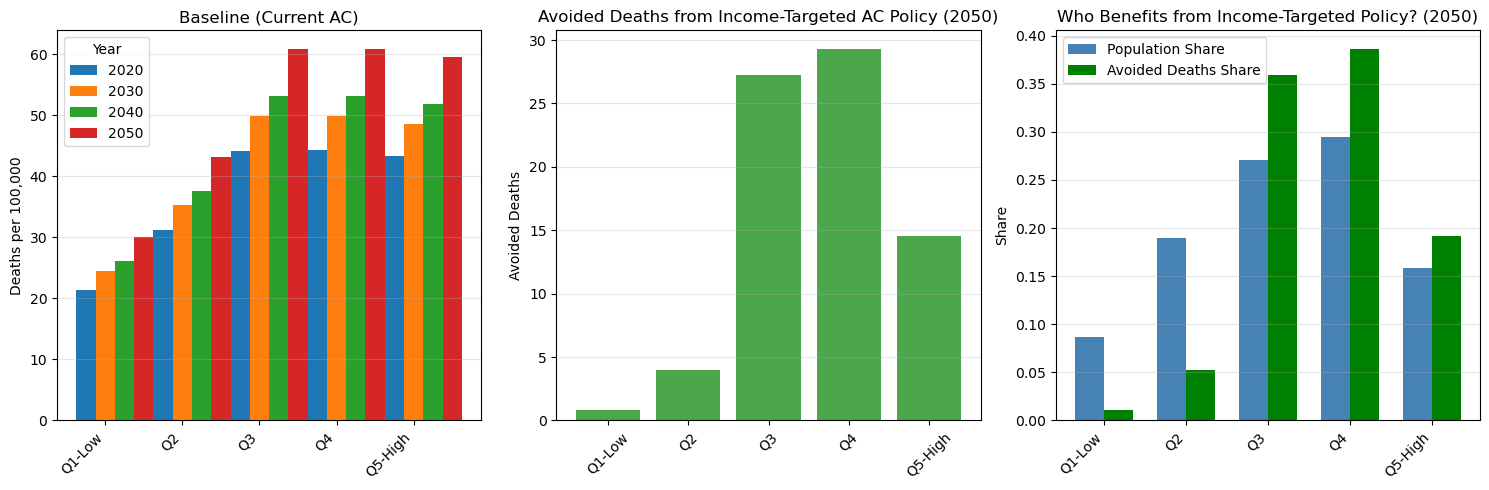

In [60]:
# Vulnerability-stratified impact analysis using equal-area SVI quintiles.
print("\n" + "="*60)
print("DEATHS BY VULNERABILITY QUINTILE (with AC attenuation)")
print("="*60)

# loading vulnerability grid
from cityheat.vulnerability_layer import load_vulnerability

try:
    vuln = load_vulnerability(INT, SLUG)
    svi_grid = vuln["svi"]  # same shape as ref grid (HGT×WDT)
    HAS_VULN = True
    print(f"Loaded SVI grid: mean={np.nanmean(svi_grid):.3f}")
except FileNotFoundError:
    HAS_VULN = False
    print("No vulnerability layer found.")

if HAS_VULN:
    quintile_labels = {1: "Q1-Low", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Q5-High"}

    # compute deaths pixel-by-pixel and then sum them by SVI quintile
    def deaths_year_by_quintile(year, coverage_grid, eff_by_bucket, eff_base=None, age_ifs=None):
        """
        Compute annual deaths per vulnerability quintile for a given year.

        Uses year-specific pop_on_ref and age_on_ref (set in the outer loop),
        builds SVI quintiles with pd.qcut on pixels with pop>0, and returns:
          - deaths_by_quintile: {label -> deaths}
          - deaths_grid: 2D array of deaths per pixel
          - pop_by_quintile: {label -> population}
        """
        # IMPORTANT: use year-specific IFs (scaled)
        if age_ifs is None:
            try:
                age_ifs = get_age_ifs(year)
            except NameError:
                # fallback if get_age_ifs isn't defined in this notebook
                age_ifs = age_ifs_by_year.get(int(year), age_ifs_by_year[MDD_REF_YEAR])

        # IMPORTANT: avoid truthiness bug when eff_base = 0.0
        eff0 = EFF_DEFAULT if eff_base is None else eff_base

        # make it a Series so we can use .dt
        dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
        year_idx = dates.dt.year.to_numpy(int)
        idx = np.where(year_idx == int(year))[0]

        if idx.size == 0:
            empty = {lbl: 0.0 for lbl in quintile_labels.values()}
            return empty, np.zeros_like(svi_grid, dtype=float), empty

        # year-specific city mask (only where we have population this year)
        pop_grid = pop_on_ref  # year-specific, set in the outer loop
        m_city = CITY_MASK & np.isfinite(pop_grid) & (pop_grid > 0)

        # valid pixels for SVI / pop
        valid = m_city & np.isfinite(svi_grid)
        svi_flat = svi_grid[valid].ravel()

        if svi_flat.size == 0:
            empty = {lbl: 0.0 for lbl in quintile_labels.values()}
            return empty, np.zeros_like(svi_grid, dtype=float), empty

        # row-based SVI quintiles for THIS year (equal-area, not pop-weighted)
        labels = [quintile_labels[i] for i in range(1, 6)]
        qcats = pd.qcut(svi_flat, 5, labels=labels)

        # put labels back onto full grid
        quintile_grid_lbl = np.full(svi_grid.shape, None, dtype=object)
        flat_idx = np.flatnonzero(valid.ravel())
        quintile_grid_lbl.ravel()[flat_idx] = qcats.astype(object)

        # fill AC coverage holes, weighted by this year's pop_grid
        cov_grid = np.where(m_city & np.isfinite(coverage_grid), coverage_grid, np.nan)
        if np.isnan(cov_grid[m_city]).any():
            w = pop_grid[m_city].astype(float)
            x = np.nan_to_num(cov_grid[m_city], nan=0.0)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

        deaths_grid = np.zeros_like(svi_grid, dtype=float)

        for i_ev in idx:
            I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)
            m = m_city & np.isfinite(I_grid)
            if not np.any(m):
                continue

            cov = np.where(m, cov_grid, 0.0)

            for age_lbl, f in age_ifs.items():
                eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff0)
                mdd = _interp_mdd(I_grid, f)
                mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
                pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)  # year-specific
                deaths_grid += np.where(m, pop_age * mdd * mult, 0.0)

        # aggregate deaths and pop by quintile label
        deaths_by_quintile = {}
        pop_by_quintile = {}
        for lbl in quintile_labels.values():
            mask_q = m_city & (quintile_grid_lbl == lbl)
            deaths_by_quintile[lbl] = float(np.nansum(deaths_grid[mask_q]))
            pop_by_quintile[lbl]    = float(np.nansum(pop_grid[mask_q]))

        return deaths_by_quintile, deaths_grid, pop_by_quintile

    # compute for all years/scenarios
    vuln_results = []

    for year in [2020, 2030, 2040, 2050]:
        # year-specific age and population
        age_on_ref = AGE_GRID.get(year, age_on_ref_base)
        pop_on_ref = POP_GRID.get(year, pop_on_ref_base)

        # year-specific scaled IFs (avoid accidentally using ref-year IFs)
        age_ifs_year = get_age_ifs(year)

        k = year_to_index[year]
        cov_base    = coverage_base_3d[k].astype(float)
        cov_policy  = coverage_policy_3d[k].astype(float)
        cov_uniform = coverage_uniform_3d[k].astype(float)  # uniform policy

        # baseline: get deaths + population per quintile (for this year)
        deaths_base, _, pop_by_quintile_year = deaths_year_by_quintile(
            year, cov_base, EFF_BUCKETS, EFF_UNIFORM, age_ifs=age_ifs_year
        )

        # income-targeted AC policy
        deaths_policy, _, _ = deaths_year_by_quintile(
            year, cov_policy, EFF_BUCKETS, EFF_UNIFORM, age_ifs=age_ifs_year
        )

        # uniform AC policy
        deaths_unif, _, _ = deaths_year_by_quintile(
            year, cov_uniform, EFF_BUCKETS, EFF_UNIFORM, age_ifs=age_ifs_year
        )

        # assemble rows using year-specific pop_by_quintile_year
        for lbl in quintile_labels.values():
            pop = pop_by_quintile_year[lbl]
            vuln_results.append({
                "year": year,
                "quintile": lbl,
                "pop": pop,
                "deaths_baseline": deaths_base[lbl],
                "deaths_policy": deaths_policy[lbl],
                "deaths_policy_uniform": deaths_unif[lbl],
                "avoided_income_vs_base":    deaths_base[lbl] - deaths_policy[lbl],
                "avoided_uniform_vs_base":   deaths_base[lbl] - deaths_unif[lbl],
                "avoided_uniform_vs_income": deaths_policy[lbl] - deaths_unif[lbl],
                "deaths_per_100k_baseline":  deaths_base[lbl]  / pop * 1e5 if pop > 0 else 0.0,
                "deaths_per_100k_income":    deaths_policy[lbl]/ pop * 1e5 if pop > 0 else 0.0,
                "deaths_per_100k_uniform":   deaths_unif[lbl]  / pop * 1e5 if pop > 0 else 0.0,
            })

    vuln_df = pd.DataFrame(vuln_results)

    # summary tables and disparity
    print("\n[1] Deaths per 100k by Vulnerability Quintile (Baseline AC):")
    baseline_pivot = vuln_df.pivot(index="quintile", columns="year",
                                   values="deaths_per_100k_baseline")
    print(baseline_pivot.round(2))

    print("\n[2] Deaths per 100k by Vulnerability Quintile (Income-targeted policy):")
    income_pivot = vuln_df.pivot(index="quintile", columns="year",
                                 values="deaths_per_100k_income")
    print(income_pivot.round(2))

    print("\n[3] Deaths per 100k by Vulnerability Quintile (Uniform policy):")
    uniform_pivot = vuln_df.pivot(index="quintile", columns="year",
                                  values="deaths_per_100k_uniform")
    print(uniform_pivot.round(2))

    print("\n[4] Avoided deaths vs baseline (Income-targeted policy):")
    avoided_income_pivot = vuln_df.pivot(index="quintile", columns="year",
                                         values="avoided_income_vs_base")
    print(avoided_income_pivot.round(2))

    print("\n[5] Avoided deaths vs baseline (Uniform policy):")
    avoided_uniform_pivot = vuln_df.pivot(index="quintile", columns="year",
                                          values="avoided_uniform_vs_base")
    print(avoided_uniform_pivot.round(2))

    print("\n[6] Q5/Q1 disparity ratios (baseline vs income vs uniform):")
    for year in [2020, 2030, 2040, 2050]:
        df_y = vuln_df[vuln_df["year"] == year]

        def ratio(col):
            q5 = df_y.loc[df_y["quintile"] == "Q5-High", col].iloc[0]
            q1 = df_y.loc[df_y["quintile"] == "Q1-Low",  col].iloc[0]
            return q5 / q1 if q1 != 0 else np.nan

        r_base    = ratio("deaths_per_100k_baseline")
        r_income  = ratio("deaths_per_100k_income")
        r_uniform = ratio("deaths_per_100k_uniform")

        print(f"  {year}: baseline={r_base:.2f}×, "
              f"income={r_income:.2f}×, uniform={r_uniform:.2f}×")

    out_path = INT / f"deaths_by_vulnerability_quintile_{SLUG}.csv"
    vuln_df.to_csv(out_path, index=False)
    print("\n Saved:", out_path)

    # visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    quintiles = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    x = np.arange(len(quintiles))
    width = 0.25

    # panel 1: Baseline deaths by quintile
    for i, year in enumerate([2020, 2030, 2040, 2050]):
        rates = baseline_pivot.loc[quintiles, year].values
        axes[0].bar(x + i*width, rates, width, label=str(year))
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(quintiles, rotation=45, ha='right')
    axes[0].set_ylabel("Deaths per 100,000")
    axes[0].set_title("Baseline (Current AC)")
    axes[0].legend(title="Year")
    axes[0].grid(axis='y', alpha=0.3)

    # panel 2: Avoided deaths by quintile (2050, income-targeted policy)
    avoided_2050 = (
        vuln_df[vuln_df["year"] == 2050]
        .set_index("quintile")
        .loc[quintiles, "avoided_income_vs_base"]
    )
    axes[1].bar(quintiles, avoided_2050.values, color='green', alpha=0.7)
    axes[1].set_ylabel("Avoided Deaths")
    axes[1].set_title("Avoided Deaths from Income-Targeted AC Policy (2050)")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # panel 3: Population share vs avoided deaths share (income-targeted policy)
    pop_2050 = (
        vuln_df[vuln_df["year"] == 2050]
        .set_index("quintile")
        .loc[quintiles, "pop"]
        .values
    )
    pop_share = pop_2050 / pop_2050.sum()
    avoided_share = avoided_2050.values / avoided_2050.sum()

    x = np.arange(5)
    width = 0.35
    axes[2].bar(x - width/2, pop_share, width, label="Population Share", color="steelblue")
    axes[2].bar(x + width/2, avoided_share, width, label="Avoided Deaths Share", color="green")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(quintiles, rotation=45, ha='right')
    axes[2].set_ylabel("Share")
    axes[2].set_title("Who Benefits from Income-Targeted Policy? (2050)")
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT / f"vulnerability_stratified_AC_{SLUG}.png", dpi=150)
    plt.show()


DEATHS BY POP-WEIGHTED VULNERABILITY QUINTILE (with AC attenuation)

Pop-weighted SVI quintile population (2020):
  Q1-Low: 684670
  Q2: 684634
  Q3: 684650
  Q4: 684696
  Q5-High: 684708



Pop-weighted SVI quintile population (2030):
  Q1-Low: 651193
  Q2: 651270
  Q3: 651429
  Q4: 651337
  Q5-High: 651342



Pop-weighted SVI quintile population (2040):
  Q1-Low: 633001
  Q2: 632819
  Q3: 633130
  Q4: 633002
  Q5-High: 633085



Pop-weighted SVI quintile population (2050):
  Q1-Low: 618341
  Q2: 618566
  Q3: 618391
  Q4: 618355
  Q5-High: 618645



[1-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Baseline AC):
year       2020   2030   2040   2050
quintile                            
Q1-Low   24.230 31.790 38.400 47.230
Q2       42.090 54.770 66.090 80.980
Q3       45.130 58.790 70.950 86.920
Q4       44.230 57.780 69.750 85.530
Q5-High  42.840 55.720 67.400 82.760

[2-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Income-targeted policy):
year       2020   2030   2040   2050
quintile                            
Q1-Low   23.990 31.470 38.040 46.790
Q2       40.420 52.590 63.550 77.850
Q3       42.510 55.510 67.090 82.190
Q4       41.810 54.520 65.900 80.780
Q5-High  40.760 52.960 64.130 78.730

[3-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Uniform policy):
year       2020   2030   2040   2050
quintile                            
Q1-Low   23.400 30.690 37.210 45.770
Q2       39.990 52.040 62.820 76.950
Q3       42.850 55.790 67.350 82.490
Q4       42.000 54.850 66.230 81.190
Q5-High  40.

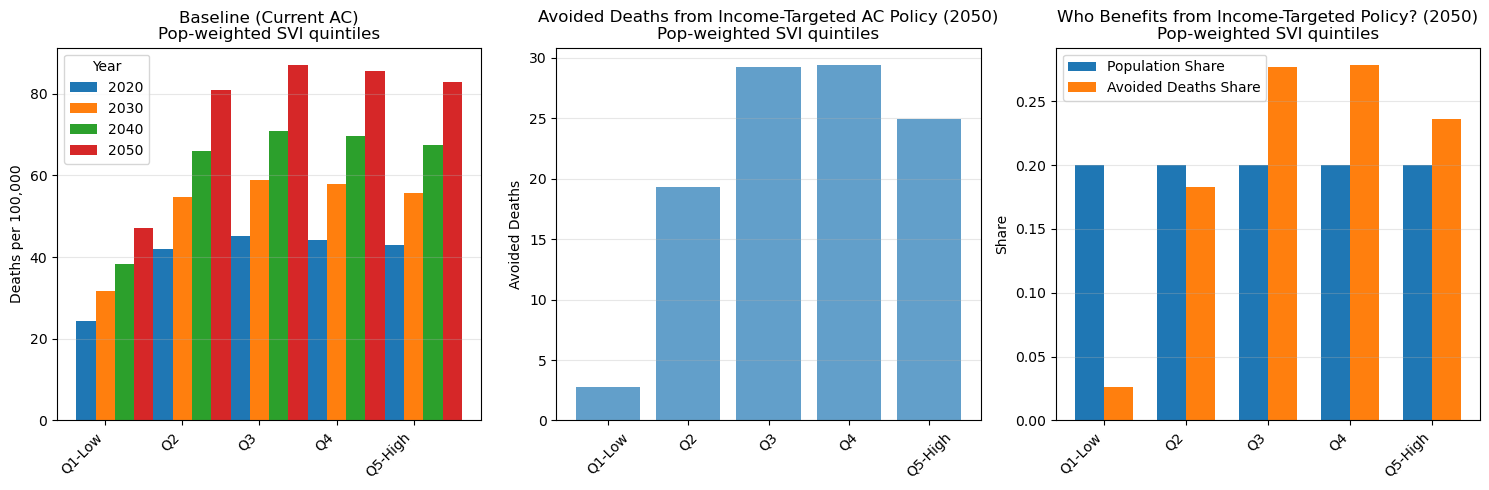

In [61]:
# Vulnerability-stratified impact analysis using population-weighted SVI quintiles.
print("\n" + "="*60)
print("DEATHS BY POP-WEIGHTED VULNERABILITY QUINTILE (with AC attenuation)")
print("="*60)

if HAS_VULN:
    # labels and bins 
    label_order = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    quintile_labels_pop = {i + 1: lbl for i, lbl in enumerate(label_order)}

    def build_pop_weighted_quintile_grid(pop_grid):
        """
        Build *population-weighted* SVI quintile grid for a given year's population.
        - sort locations by SVI,
        - accumulate population,
        - split into 5 groups each holding 20% of total population.
        """
        valid_mask = (
            CITY_MASK &
            np.isfinite(svi_grid) &
            np.isfinite(pop_grid) &
            (pop_grid > 0)
        )

        svi_flat = svi_grid[valid_mask].astype(float)
        pop_flat = pop_grid[valid_mask].astype(float)

        if svi_flat.size == 0 or pop_flat.sum() == 0:
            raise ValueError(
                "No valid (SVI, population) pixels to build pop-weighted SVI quintiles."
            )

        # sort by SVI
        order = np.argsort(svi_flat)
        svi_sorted = svi_flat[order]
        pop_sorted = pop_flat[order]

        # cumulative population fraction
        cum_pop = np.cumsum(pop_sorted)
        total_pop = cum_pop[-1]
        cum_pop_frac = cum_pop / total_pop  # goes from (0,1]

        # unsort cumulative fraction back to original valid-pixel order
        cum_pop_frac_unsorted = np.empty_like(cum_pop_frac)
        cum_pop_frac_unsorted[order] = cum_pop_frac

        # assign pop-weighted quintiles (labels) to valid pixels
        quintile_cat = pd.cut(
            cum_pop_frac_unsorted,
            bins=bins,
            labels=label_order,
            include_lowest=True,
        )

        # map labels back onto full grid
        quintile_grid_pop = np.full(svi_grid.size, np.nan, dtype=object)
        flat_idx_valid = np.flatnonzero(valid_mask.ravel())
        quintile_grid_pop[flat_idx_valid] = quintile_cat.astype(object)
        quintile_grid_pop = quintile_grid_pop.reshape(svi_grid.shape)

        # convert to integer codes 1–5 for convenience
        label_to_int = {lbl: i + 1 for i, lbl in enumerate(label_order)}
        quintile_grid_pop_int = np.full(svi_grid.shape, np.nan, dtype=float)
        for lbl, code in label_to_int.items():
            mask_lbl = (quintile_grid_pop == lbl)
            quintile_grid_pop_int[mask_lbl] = float(code)

        return quintile_grid_pop_int

    def deaths_year_by_pop_quintile(year, coverage_grid, quintile_grid_pop_int,
                                    eff_by_bucket, eff_base=None, pop_grid=None):
        """
        Compute annual deaths per *population-weighted* SVI quintile for a given year.

        pop_grid: population grid to use for weighting coverage gaps (usually the same
                  grid used in build_pop_weighted_quintile_grid for that year).
        """
        if pop_grid is None:
            pop_grid = pop_on_ref  # fallback, keeps backward compatibility

        dates = pd.to_datetime(H.date)
        mask_year = (dates.year == year)
        idx = np.where(mask_year)[0]

        if idx.size == 0:
            return {lbl: 0.0 for lbl in quintile_labels_pop.values()}, np.zeros_like(svi_grid, dtype=float)

        # use pop_grid for city mask and weighting
        m_city = CITY_MASK & np.isfinite(pop_grid)

        # fill coverage gaps with population-weighted mean (using pop_grid)
        cov_grid = np.where(m_city & np.isfinite(coverage_grid), coverage_grid, np.nan)
        if np.isnan(cov_grid[m_city]).any():
            w = pop_grid[m_city].astype(float)
            x = np.nan_to_num(cov_grid[m_city], nan=0.0)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

        deaths_grid = np.zeros_like(svi_grid, dtype=float)

        for i_ev in idx:
            I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)
            m = m_city & np.isfinite(I_grid)
            if not np.any(m):
                continue

            cov = np.where(m, cov_grid, 0.0)

            for age_lbl, f in age_ifs.items():
                eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base or EFF_DEFAULT)
                mdd = _interp_mdd(I_grid, f)
                mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
                pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
                deaths_grid += np.where(m, pop_age * mdd * mult, 0.0)

        result = {}
        for q, lbl in quintile_labels_pop.items():
            mask_q = CITY_MASK & (quintile_grid_pop_int == q)
            result[lbl] = float(np.nansum(deaths_grid[mask_q]))

        return result, deaths_grid

    # computing for all years and scenarios 
    vuln_results_pop = []

    for year in [2020, 2030, 2040, 2050]:
        # year-specific demography
        age_on_ref = AGE_GRID.get(year, age_on_ref_base)
        pop_on_ref = POP_GRID.get(year, pop_on_ref_base)

        # build pop-weighted SVI quintiles *for this year's population*
        quintile_grid_pop_int = build_pop_weighted_quintile_grid(pop_on_ref)

        # coverage slices for this year
        k = year_to_index[year]
        cov_base    = coverage_base_3d[k].astype(float)
        cov_income  = coverage_policy_3d[k].astype(float)    # income-targeted AC
        cov_uniform = coverage_uniform_3d[k].astype(float)   # uniform AC policy

        # population per pop-weighted quintile (for this year's population)
        pop_by_quintile_pop = {}
        for q, lbl in quintile_labels_pop.items():
            mask_q = CITY_MASK & (quintile_grid_pop_int == q)
            pop_by_quintile_pop[lbl] = float(np.nansum(pop_on_ref[mask_q]))

        print(f"\nPop-weighted SVI quintile population ({year}):")
        for lbl in label_order:
            print(f"  {lbl}: {pop_by_quintile_pop[lbl]:.0f}")

        # deaths under each AC scenario (using year-specific quintile grid)
        deaths_base_pop,    _ = deaths_year_by_pop_quintile(
            year, cov_base,    quintile_grid_pop_int, EFF_BUCKETS, EFF_UNIFORM, pop_grid=pop_on_ref
        )
        deaths_income_pop,  _ = deaths_year_by_pop_quintile(
            year, cov_income,  quintile_grid_pop_int, EFF_BUCKETS, EFF_UNIFORM, pop_grid=pop_on_ref
        )
        deaths_uniform_pop, _ = deaths_year_by_pop_quintile(
            year, cov_uniform, quintile_grid_pop_int, EFF_BUCKETS, EFF_UNIFORM, pop_grid=pop_on_ref
        )

        # assemble rows
        for lbl in label_order:
            pop_q = pop_by_quintile_pop[lbl]
            vuln_results_pop.append({
                "year": year,
                "quintile": lbl,
                "pop": pop_q,
                "deaths_baseline": deaths_base_pop[lbl],
                "deaths_income":   deaths_income_pop[lbl],
                "deaths_uniform":  deaths_uniform_pop[lbl],
                "avoided_income_vs_base":    deaths_base_pop[lbl] - deaths_income_pop[lbl],
                "avoided_uniform_vs_base":   deaths_base_pop[lbl] - deaths_uniform_pop[lbl],
                "avoided_uniform_vs_income": deaths_income_pop[lbl] - deaths_uniform_pop[lbl],
                "deaths_per_100k_baseline":  deaths_base_pop[lbl]   / pop_q * 1e5 if pop_q > 0 else 0.0,
                "deaths_per_100k_income":    deaths_income_pop[lbl] / pop_q * 1e5 if pop_q > 0 else 0.0,
                "deaths_per_100k_uniform":   deaths_uniform_pop[lbl]/ pop_q * 1e5 if pop_q > 0 else 0.0,
            })

    vuln_df_pop = pd.DataFrame(vuln_results_pop)

    # summary tables (pop-weighted) 
    print("\n[1-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Baseline AC):")
    baseline_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                           values="deaths_per_100k_baseline")
    print(baseline_pivot_pop.round(2))

    print("\n[2-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Income-targeted policy):")
    income_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                         values="deaths_per_100k_income")
    print(income_pivot_pop.round(2))

    print("\n[3-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Uniform policy):")
    uniform_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                          values="deaths_per_100k_uniform")
    print(uniform_pivot_pop.round(2))

    print("\n[4-PW] Avoided deaths vs baseline (Income-targeted policy, pop-weighted):")
    avoided_income_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                                 values="avoided_income_vs_base")
    print(avoided_income_pivot_pop.round(2))

    print("\n[5-PW] Avoided deaths vs baseline (Uniform policy, pop-weighted):")
    avoided_uniform_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                                  values="avoided_uniform_vs_base")
    print(avoided_uniform_pivot_pop.round(2))

    print("\n[6-PW] Avoided deaths: Uniform vs Income-targeted (pop-weighted):")
    avoided_uniform_vs_income_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year",
                                                            values="avoided_uniform_vs_income")
    print(avoided_uniform_vs_income_pivot_pop.round(2))

    # Q5/Q1 disparity ratios for pop-weighted SVI
    print("\n[7-PW] Q5/Q1 disparity ratios (baseline vs income vs uniform, POP-WEIGHTED SVI):")
    for year in [2020, 2030, 2040, 2050]:
        df_y = vuln_df_pop[vuln_df_pop["year"] == year]

        def ratio(col):
            q5 = df_y.loc[df_y["quintile"] == "Q5-High", col].iloc[0]
            q1 = df_y.loc[df_y["quintile"] == "Q1-Low",  col].iloc[0]
            return q5 / q1 if q1 != 0 else np.nan

        r_base    = ratio("deaths_per_100k_baseline")
        r_income  = ratio("deaths_per_100k_income")
        r_uniform = ratio("deaths_per_100k_uniform")

        print(f"  {year}: baseline={r_base:.2f}×, "
              f"income={r_income:.2f}×, uniform={r_uniform:.2f}×")

    # save + visualization 
    out_path_pw = INT / f"deaths_by_vulnerability_quintile_popweighted_{SLUG}.csv"
    vuln_df_pop.to_csv(out_path_pw, index=False)
    print("\n Saved (pop-weighted):", out_path_pw)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    quintiles_pw = label_order
    x = np.arange(len(quintiles_pw))
    width = 0.25

    # panel 1: Baseline deaths per 100k by pop-weighted quintile
    for i, year in enumerate([2020, 2030, 2040, 2050]):
        rates = baseline_pivot_pop.loc[quintiles_pw, year].values
        axes[0].bar(x + i * width, rates, width, label=str(year))
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(quintiles_pw, rotation=45, ha='right')
    axes[0].set_ylabel("Deaths per 100,000")
    axes[0].set_title("Baseline (Current AC)\nPop-weighted SVI quintiles")
    axes[0].legend(title="Year")
    axes[0].grid(axis='y', alpha=0.3)

    # panel 2: Avoided deaths by pop-weighted quintile (2050, income-targeted)
    avoided_2050_pw_income = (
        vuln_df_pop[vuln_df_pop["year"] == 2050]
        .set_index("quintile")
        .loc[quintiles_pw, "avoided_income_vs_base"]
    )
    axes[1].bar(quintiles_pw, avoided_2050_pw_income.values, alpha=0.7)
    axes[1].set_ylabel("Avoided Deaths")
    axes[1].set_title("Avoided Deaths from Income-Targeted AC Policy (2050)\nPop-weighted SVI quintiles")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # panel 3: Population share vs avoided deaths share (income-targeted, 2050)
    pop_share_pw = np.array([
        vuln_df_pop[(vuln_df_pop["year"] == 2050) &
                    (vuln_df_pop["quintile"] == q)]["pop"].iloc[0]
        for q in quintiles_pw
    ])
    pop_share_pw = pop_share_pw / pop_share_pw.sum()
    avoided_share_pw = avoided_2050_pw_income.values / avoided_2050_pw_income.values.sum()

    x2 = np.arange(5)
    width2 = 0.35
    axes[2].bar(x2 - width2/2, pop_share_pw, width2, label="Population Share")
    axes[2].bar(x2 + width2/2, avoided_share_pw, width2, label="Avoided Deaths Share")
    axes[2].set_xticks(x2)
    axes[2].set_xticklabels(quintiles_pw, rotation=45, ha='right')
    axes[2].set_ylabel("Share")
    axes[2].set_title("Who Benefits from Income-Targeted Policy? (2050)\nPop-weighted SVI quintiles")
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT / f"vulnerability_stratified_AC_popweighted_{SLUG}.png", dpi=150)
    plt.show()

else:
    print("No vulnerability layer found (HAS_VULN=False) – skipping pop-weighted analysis.")

In [62]:
for year in [2020, 2030, 2040, 2050]:
    pop_on_ref = POP_GRID.get(year, pop_on_ref_base)
    q_int = build_pop_weighted_quintile_grid(pop_on_ref)

    # total pop in city
    total_city_pop = float(np.nansum(pop_on_ref[CITY_MASK]))

    # pop per quintile
    pop_by_q = {}
    for q, lbl in quintile_labels_pop.items():
        mask_q = CITY_MASK & (q_int == q)
        pop_by_q[lbl] = float(np.nansum(pop_on_ref[mask_q]))

    total_quintile_pop = sum(pop_by_q.values())

    # pop lost due to missing SVI
    missing_svi_pop = float(np.nansum(pop_on_ref[CITY_MASK & ~np.isfinite(svi_grid)]))

    print(f"\nYear {year}")
    print("  total city population:       ", total_city_pop)
    print("  sum over quintiles:          ", total_quintile_pop)
    print("  diff (city - quintiles):     ", total_city_pop - total_quintile_pop)
    print("  pop in cells with SVI NaN:   ", missing_svi_pop)
    print("  quintiles (should be ~20% each):")
    for lbl in label_order:
        print(f"    {lbl}: {pop_by_q[lbl]:.0f}")


Year 2020
  total city population:        3424647.75
  sum over quintiles:           3423358.5
  diff (city - quintiles):      1289.25
  pop in cells with SVI NaN:    1289.235107421875
  quintiles (should be ~20% each):
    Q1-Low: 684670
    Q2: 684634
    Q3: 684650
    Q4: 684696
    Q5-High: 684708

Year 2030
  total city population:        3257828.5
  sum over quintiles:           3256570.5
  diff (city - quintiles):      1258.0
  pop in cells with SVI NaN:    1257.6304931640625
  quintiles (should be ~20% each):
    Q1-Low: 651193
    Q2: 651270
    Q3: 651429
    Q4: 651337
    Q5-High: 651342

Year 2040
  total city population:        3166253.5
  sum over quintiles:           3165036.875
  diff (city - quintiles):      1216.625
  pop in cells with SVI NaN:    1216.569091796875
  quintiles (should be ~20% each):
    Q1-Low: 633001
    Q2: 632819
    Q3: 633130
    Q4: 633002
    Q5-High: 633085

Year 2050
  total city population:        3093484.25
  sum over quintiles:         

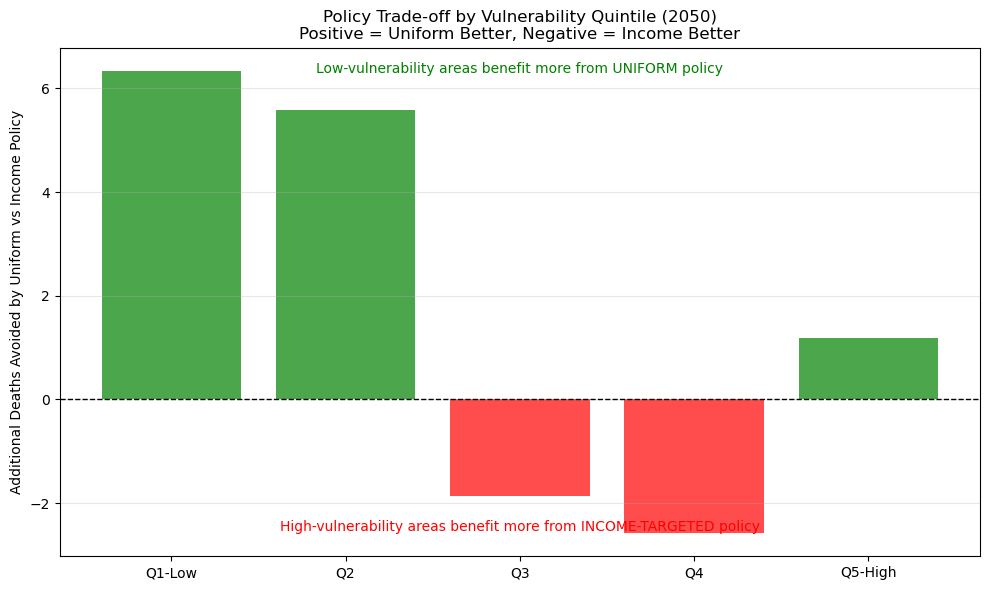

In [63]:
# Trade-off plot: Who wins/loses from income-targeting?
fig, ax = plt.subplots(figsize=(10, 6))

quintiles = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
diff_2050 = vuln_df_pop[vuln_df_pop["year"] == 2050].set_index("quintile").loc[quintiles, "avoided_uniform_vs_income"]

colors = ['green' if x > 0 else 'red' for x in diff_2050.values]
ax.bar(quintiles, diff_2050.values, color=colors, alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel("Additional Deaths Avoided by Uniform vs Income Policy")
ax.set_title("Policy Trade-off by Vulnerability Quintile (2050)\nPositive = Uniform Better, Negative = Income Better")
ax.grid(axis='y', alpha=0.3)

# annotation
ax.text(0.5, 0.95, "Low-vulnerability areas benefit more from UNIFORM policy", 
        transform=ax.transAxes, ha='center', fontsize=10, color='green')
ax.text(0.5, 0.05, "High-vulnerability areas benefit more from INCOME-TARGETED policy",
        transform=ax.transAxes, ha='center', fontsize=10, color='red')

plt.tight_layout()
plt.savefig(OUT / f"policy_tradeoff_by_vulnerability_{SLUG}.png", dpi=150)
plt.show()

## 6. Costs parameterization

This section converts the AC scenarios into equipment costs, maintenance, electricity demand, and the exported inputs that `NB08` later discounts and compares with the other adaptation options.

### 6.1 AC equipment costs (CAPEX)

Capital cost, maintenance rate, lifetime, and electricity tariff are read from the city config so the economic assumptions remain explicit and easy to audit.

In [64]:
# Load AC cost parameters from the city config.
ac_cost_cfg = cfg.get("ac", {}) or cfg.get("ac_costs", {})

AC_CAPEX_PER_USER   = float(ac_cost_cfg.get("capex_per_user", 500.0))    # € per AC unit
AC_MAINT_RATE       = float(ac_cost_cfg.get("maint_rate", 0.05))         # fraction of CAPEX/year
AC_LIFETIME_YEARS   = int(ac_cost_cfg.get("lifetime_years", 10))         # replacement cycle
TARIFF_EUR_PER_KWH  = float(ac_cost_cfg.get("tariff_eur_per_kwh", 0.25)) # €/kWh

maint_per_user_yr = AC_MAINT_RATE * AC_CAPEX_PER_USER

print("AC Cost Parameters:")
print(f"  CAPEX per user: €{AC_CAPEX_PER_USER:,.0f}")
print(f"  Maintenance rate: {AC_MAINT_RATE:.0%} of CAPEX/year = €{maint_per_user_yr:.0f}/user/year")
print(f"  Lifetime: {AC_LIFETIME_YEARS} years")
print(f"  Electricity tariff: €{TARIFF_EUR_PER_KWH:.2f}/kWh")

AC Cost Parameters:
  CAPEX per user: €500
  Maintenance rate: 5% of CAPEX/year = €25/user/year
  Lifetime: 10 years
  Electricity tariff: €0.25/kWh


### 6.2 City-level electricity data

Citywide electricity demand per AC user comes from the configured NUTS inputs for Greek NUTS IDs `EL30` and `EL3` averaged where both are available. These values are not yet spatially explicit; they are the city-level anchors that the next step downscales across local zones.

In [65]:
# Load city-level AC electricity use per AC user from the NUTS input table.
import re

ac_cfg = cfg.get("ac", {})
kwh_path = P(ac_cfg.get("kwh_file", ""))
assert kwh_path.exists(), f"Missing AC kWh CSV: {kwh_path}"

# Scenario choice from the city config.
ssp_choice = int(ac_cfg.get("ssp", 2))
print(f"Using scenario SSP{ssp_choice}")

years_interest = list(ac_cfg.get("years", [2020, 2030, 2040, 2050]))

# Support both the new list-based NUTS config and the legacy single-id format.
nuts_ids = ac_cfg.get("kwh_nuts_ids", None)
if nuts_ids is None:
    legacy = ac_cfg.get("nuts_id", None)
    nuts_ids = [legacy] if legacy else []
nuts_ids = [str(x) for x in nuts_ids if x is not None]
assert nuts_ids, "cfg['ac'] needs 'kwh_nuts_ids' or 'nuts_id'."
print(f"Using kWh NUTS IDs: {nuts_ids}")

# Column names from the city config.
cols = ac_cfg.get("kwh_columns", {}) or {}
COL_ID = cols.get("id", "NUTS_ID")
COL_SSP = cols.get("scenario", "Scenario")
COL_YEAR = cols.get("year", "year")
COL_VAL = cols.get("value", "value")

df = pd.read_csv(kwh_path)

def _scenario_to_int(x):
    s = str(x)
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else None

df = df.copy()
df["_scenario_int"] = df[COL_SSP].map(_scenario_to_int)
df[COL_YEAR] = pd.to_numeric(df[COL_YEAR], errors="coerce")
df[COL_VAL] = pd.to_numeric(df[COL_VAL], errors="coerce").replace([-999, -9999], np.nan)

sub = df[
    (df[COL_ID].astype(str).str.strip().isin(nuts_ids)) &
    (df["_scenario_int"] == ssp_choice)
].dropna(subset=[COL_YEAR, COL_VAL])

assert len(sub) > 0, f"No rows found for NUTS_ID in {nuts_ids}, SSP={ssp_choice}"

series = sub.groupby(sub[COL_YEAR].astype(int))[COL_VAL].mean().to_dict()
per_user_city_by_year = {int(y): float(series[int(y)]) for y in years_interest}

print("\nAC electricity per user (kWh/user/year):")
for y in years_interest:
    print(f"  {y}: {per_user_city_by_year[y]:,.1f}")

# Save the city-level series for later sections.
ac_city_series = pd.DataFrame({
    "year": years_interest,
    "kwh_per_ac_user_city": [per_user_city_by_year[y] for y in years_interest],
})
ac_city_series.to_csv(INT / f"ac_per_user_city_{SLUG}.csv", index=False)


Using scenario SSP2
Using kWh NUTS IDs: ['EL30', 'EL3']

AC electricity per user (kWh/user/year):
  2020: 988.3
  2030: 988.3
  2040: 988.3
  2050: 1,096.4


### 6.3 Electricity downscaling to zone level

Citywide kWh per AC user is not spatially explicit, so the notebook disperses it across zones using local heat exposure while preserving the users-weighted city mean exactly. Hotter zones can end up with higher kWh per AC user, but the city total still matches the NUTS input after rescaling.

In [66]:
# Disperse citywide kWh per user across zones using hazard differences, then rescale to preserve the city mean.
# Hazard-based dispersion parameters.
rng = np.random.default_rng(42)
sigma0 = 0.20  # base dispersion (20% of mean)
gamma = 1.0    # how strongly dispersion scales with hazard ratio

zone_ids = zone_on_ref

def _get_H_for_year(year):
    """Get hazard grid for a specific year."""
    if YEARS is None:
        raise ValueError("T2M annual stack not loaded")
    if year not in YEARS:
        raise KeyError(f"Year {year} not in YEARS: {list(YEARS)}")
    idx = list(YEARS).index(int(year))
    return DATA[idx, :, :]

def _cov_for_year(year):
    """Get AC coverage map for a specific year from NB5 3D maps."""
    year = int(year)
    if coverage_base_3d is None:
        raise ValueError("AC coverage maps not loaded")
    if year not in YEARS_AC:
        raise KeyError(f"Year {year} not in YEARS_AC: {YEARS_AC}")
    k = YEARS_AC.index(year)
    return np.clip(coverage_base_3d[k], 0.0, 1.0).astype("float32")

def _wavg_pop(g):
    """Population-weighted average."""
    w = g["pop"].to_numpy()
    x = g["H"].to_numpy()
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

# Draw one fixed random shock per modeled zone so the relative pattern is stable across years.
H0 = _get_H_for_year(2020)
pop_grid0 = POP_GRID[2020]
ZONE_PIX0 = CITY_MASK & np.isfinite(H0) & (zone_ids > 0)
valid0 = ZONE_PIX0 & np.isfinite(pop_grid0)

dfH0 = pd.DataFrame({
    "zone_id": zone_ids[valid0].ravel().astype(int),
    "pop": pop_grid0[valid0].ravel().astype(float),
    "H": H0[valid0].ravel().astype(float),
})
zone_ids_all = dfH0["zone_id"].drop_duplicates().sort_values().to_numpy()
eps_by_cap = dict(zip(zone_ids_all, rng.normal(0.0, 1.0, size=len(zone_ids_all))))

print(f"Downscaling setup: {len(zone_ids_all)} zones with fixed epsilon draws")

Downscaling setup: 51 zones with fixed epsilon draws


**downscaling loop**

In [67]:
# Downscale citywide kWh per user to zones, preserving the users-weighted city mean each year.
per_user_map_by_year = {}
kwh_tot_map_by_year = {}
zone_per_user_by_year = {}
zone_energy_by_year = {}
city_summary_rows = []

for year in years_interest:
    print(f"\n=== Year {year} ===")

    # Year-specific population.
    pop_grid = POP_GRID.get(year, pop_on_ref)

    # Inputs for this year.
    coverage_map = _cov_for_year(year)
    H_year = _get_H_for_year(year)
    per_user_city = float(per_user_city_by_year[year])

    # Citywide AC share implied by the coverage map.
    m = CITY_MASK & np.isfinite(coverage_map) & np.isfinite(pop_grid)
    ac_city_map = float(np.nansum(coverage_map[m] * pop_grid[m]) / np.nansum(pop_grid[m]))

    # Target AC share from the earlier calibration, if available.
    if "ac_city_by_year" in globals() and year in ac_city_by_year:
        ac_city_target = float(ac_city_by_year[year])
    else:
        ac_city_target = ac_city_map

    print(f"  AC share from map: {ac_city_map:.3f}")
    print(f"  AC share target:   {ac_city_target:.3f}")

    # Zone-level hazard index used to disperse kWh per user around the city mean.
    ZONE_PIX = CITY_MASK & np.isfinite(H_year) & (zone_ids > 0)
    valid = ZONE_PIX & np.isfinite(pop_grid)

    dfH = pd.DataFrame({
        "zone_id": zone_ids[valid].ravel().astype(int),
        "pop": pop_grid[valid].ravel().astype(float),
        "H": H_year[valid].ravel().astype(float),
    })

    cap_H = (dfH.groupby("zone_id").apply(_wavg_pop)
             .reset_index(name="H_cap")
             .sort_values("zone_id")
             .reset_index(drop=True))

    H_city = float(np.average(dfH["H"], weights=dfH["pop"])) if dfH["pop"].sum() > 0 else float(dfH["H"].mean())

    # Reuse the fixed random draw for each zone.
    eps = cap_H["zone_id"].map(eps_by_cap).to_numpy(float)

    # Compute zone-level kWh per AC user before the city-mean rescaling step.
    zone_draws = cap_H.copy()
    ratio = np.clip((zone_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0)
    sigma_cap = sigma0 * (ratio ** gamma) * per_user_city
    draws = per_user_city + sigma_cap * eps
    draws = np.clip(draws, 0.0, np.inf)
    zone_draws["per_user_CAP_raw"] = draws.astype("float32")

    # Paint zone-level kWh per user onto the grid.
    lut = np.full(int(zone_ids.max()) + 1, np.nan, dtype="float32")
    lut[zone_draws["zone_id"].to_numpy()] = zone_draws["per_user_CAP_raw"].to_numpy()
    per_user_map = np.full(pop_grid.shape, np.nan, dtype="float32")
    per_user_map[ZONE_PIX] = lut[zone_ids[ZONE_PIX]]

    # Rescale so the users-weighted city mean exactly matches the NUTS input.
    w_users = (coverage_map * pop_grid) * CITY_MASK
    num = np.nansum(per_user_map * w_users)
    den = np.nansum(w_users)
    k = float(per_user_city) / (num / den) if den > 0 else 1.0
    per_user_map *= k

    # Total electricity maps.
    kwh_pc_map = per_user_map * coverage_map
    kwh_tot_map = kwh_pc_map * pop_grid

    # Zone table after scaling.
    zone_draws["per_user_CAP"] = zone_draws["per_user_CAP_raw"] * k
    cap_per_user = (zone_draws[["zone_id", "per_user_CAP"]]
                    .rename(columns={"per_user_CAP": "kwh_per_user_cap"}))

    # Diagnostics.
    per_user_mean_city = float(np.nansum(per_user_map * w_users) / np.nansum(w_users)) if den > 0 else np.nan
    ac_share_from_map = float(np.nansum(w_users) / np.nansum(pop_grid[CITY_MASK]))
    city_total_gwh = float(np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)
    print(f"  Per-user mean (city): {per_user_mean_city:,.1f} kWh/user/yr")
    print(f"  City total: {city_total_gwh:,.1f} GWh/yr")

    # Zone aggregation for reporting.
    dfE = pd.DataFrame({
        "zone_id": zone_ids[CITY_MASK].ravel().astype(int),
        "pop": pop_grid[CITY_MASK].ravel().astype(float),
        "kwh": kwh_tot_map[CITY_MASK].ravel().astype(float),
    })
    dfE = dfE[dfE["zone_id"] > 0]

    cap_energy = (dfE.groupby("zone_id")
                  .agg(pop_zone=("pop", "sum"), kwh_zone=("kwh", "sum"))
                  .reset_index())
    cap_energy["kwh_pc_overall"] = cap_energy["kwh_zone"] / cap_energy["pop_zone"]

    cap_per_user["year"] = year
    cap_energy["year"] = year

    # Store year-specific outputs.
    per_user_map_by_year[year] = per_user_map.astype("float32")
    kwh_tot_map_by_year[year] = kwh_tot_map.astype("float32")
    zone_per_user_by_year[year] = cap_per_user
    zone_energy_by_year[year] = cap_energy

    city_summary_rows.append({
        "year": year,
        "ac_share_city": ac_city_target,
        "ac_share_from_map": ac_share_from_map,
        "per_user_city_input": per_user_city,
        "per_user_city_realized": per_user_mean_city,
        "city_total_GWh": city_total_gwh,
    })

city_summary = pd.DataFrame(city_summary_rows)
display(city_summary)


=== Year 2020 ===
  AC share from map: 0.686
  AC share target:   0.686
  Per-user mean (city): 988.3 kWh/user/yr
  City total: 2,320.0 GWh/yr

=== Year 2030 ===
  AC share from map: 0.688
  AC share target:   0.686
  Per-user mean (city): 988.3 kWh/user/yr
  City total: 2,213.0 GWh/yr

=== Year 2040 ===
  AC share from map: 0.699
  AC share target:   0.696
  Per-user mean (city): 988.3 kWh/user/yr
  City total: 2,183.6 GWh/yr

=== Year 2050 ===
  AC share from map: 0.699
  AC share target:   0.696
  Per-user mean (city): 1,096.4 kWh/user/yr
  City total: 2,368.5 GWh/yr


,year,ac_share_city,ac_share_from_map,per_user_city_input,per_user_city_realized,city_total_GWh
0,2020,0.686,0.685,988.295,988.295,"2,319.954"
1,2030,0.686,0.687,988.295,988.295,"2,213.027"
2,2040,0.696,0.698,988.295,988.295,"2,183.633"
3,2050,0.696,0.698,"1,096.448","1,096.448","2,368.484"


### 6.4 Zone-level analysis and maps

These tables and maps report how electricity demand looks on the same zone geography used for the AC downscaling model.


Zone-level results for year 2020
City pop: 3,421,242
City AC users: 2,347,432 (AC share ≈ 0.686)
City total AC electricity: 2319.954 GWh/yr
City per-AC-user mean (users-weighted): 988.3 kWh/user/yr

Top 10 zones by kwh_pc_overall — kWh per capita (overall), 2020


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,13,0.980,"1,193.488","29,617.584","34,641,264.613","1,169.618",2020
1,48,0.980,"1,191.679","38,372.247","44,812,844.517","1,167.845",2020
2,43,0.911,"1,278.719","26,383.227","30,742,056.372","1,165.212",2020
3,12,0.932,"1,225.149","28,334.756","32,363,769.787","1,142.193",2020
4,18,0.971,"1,134.741","1,741.646","1,919,723.387","1,102.246",2020
5,57,0.980,"1,108.618","32,600.267","35,418,418.674","1,086.446",2020
6,32,0.927,"1,151.444","34,056.208","36,344,617.578","1,067.195",2020
7,52,0.971,"1,084.911","1,790.946","1,886,815.476","1,053.530",2020
8,55,0.845,"1,232.935",311.979,"324,996.251","1,041.724",2020
9,16,0.901,"1,154.714","90,151.180","93,763,873.783","1,040.074",2020


Bottom 10 zones by kwh_pc_overall — kWh per capita (overall), 2020


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,7,0.377,766.313,"65,347.371","18,865,958.312",288.703,2020
1,11,0.416,877.165,"94,086.899","34,362,954.185",365.226,2020
2,50,0.446,909.347,"140,988.639","57,169,593.750",405.491,2020
3,2,0.370,"1,127.103","23,553.096","9,818,259.917",416.856,2020
4,24,0.466,907.145,"82,691.742","34,941,028.759",422.546,2020
5,10,0.406,"1,058.145","27,136.164","11,666,028.070",429.907,2020
6,6,0.696,626.233,"619,508.634","270,121,493.847",436.025,2020
7,49,0.384,"1,176.935","26,224.822","11,850,432.569",451.878,2020
8,41,0.530,877.213,"46,067.534","21,399,875.287",464.533,2020
9,42,0.395,"1,190.617","111,435.279","52,402,521.463",470.251,2020



Top 10 zones by kwh_cap — Total kWh, 2020


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,6,0.696,626.233,"619,508.634","270,121,493.847",436.025,2020
1,47,0.583,"1,190.585","176,431.452","122,510,106.432",694.378,2020
2,16,0.901,"1,154.714","90,151.180","93,763,873.783","1,040.074",2020
3,59,0.942,"1,073.335","89,600.644","90,640,693.355","1,011.608",2020
4,22,0.867,"1,051.210","82,952.047","75,574,286.687",911.060,2020
5,21,0.814,"1,251.136","72,781.827","74,084,299.645","1,017.896",2020
6,28,0.980,988.606,"67,796.528","65,683,604.962",968.834,2020
7,44,0.852,"1,036.876","72,756.803","64,267,952.604",883.326,2020
8,9,0.956,"1,000.243","66,614.027","63,682,810.571",955.997,2020
9,40,0.837,947.517,"79,306.003","62,913,567.035",793.301,2020


Bottom 10 zones by kwh_cap — Total kWh, 2020


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,53,0.500,"1,107.431",212.666,"117,790.520",553.876,2020
1,55,0.845,"1,232.935",311.979,"324,996.251","1,041.724",2020
2,52,0.971,"1,084.911","1,790.946","1,886,815.476","1,053.530",2020
3,18,0.971,"1,134.741","1,741.646","1,919,723.387","1,102.246",2020
4,2,0.370,"1,127.103","23,553.096","9,818,259.917",416.856,2020
5,10,0.406,"1,058.145","27,136.164","11,666,028.070",429.907,2020
6,49,0.384,"1,176.935","26,224.822","11,850,432.569",451.878,2020
7,7,0.377,766.313,"65,347.371","18,865,958.312",288.703,2020
8,17,0.538,877.279,"40,237.058","18,986,656.881",471.870,2020
9,30,0.762,"1,127.420","24,173.567","20,762,080.849",858.875,2020


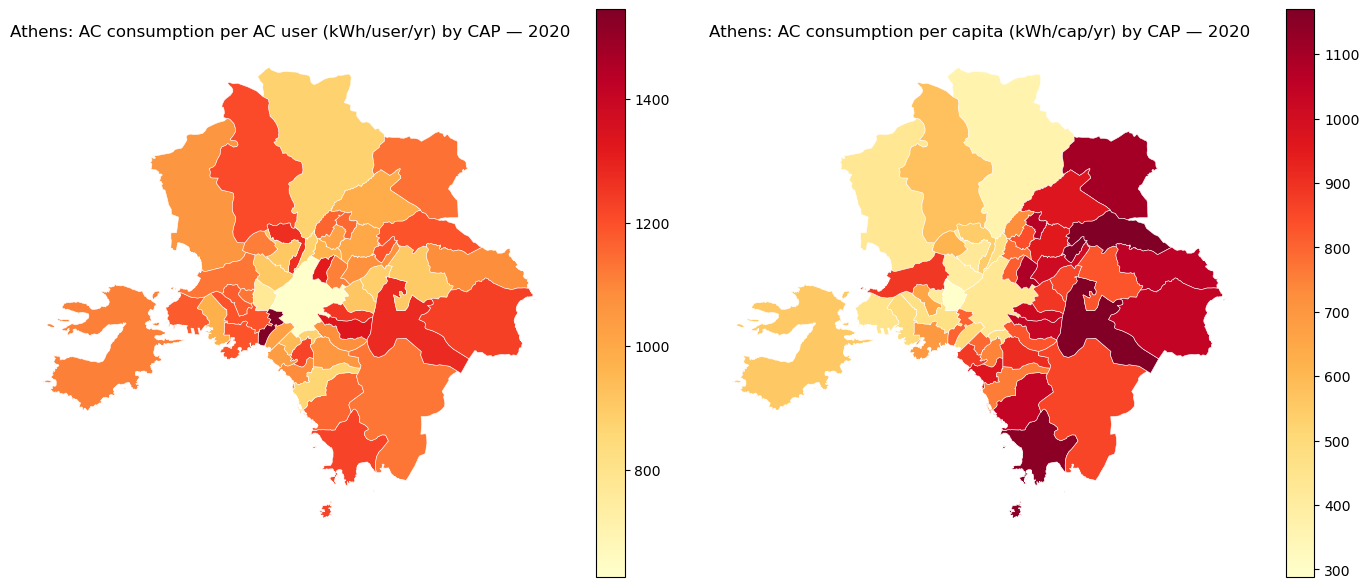


Zone-level results for year 2030
City pop: 3,254,520
City AC users: 2,239,237 (AC share ≈ 0.688)
City total AC electricity: 2213.027 GWh/yr
City per-AC-user mean (users-weighted): 988.3 kWh/user/yr

Top 10 zones by kwh_pc_overall — kWh per capita (overall), 2030


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,13,0.980,"1,191.843","29,142.506","34,038,617.418","1,168.006",2030
1,48,0.980,"1,189.927","37,017.281","43,166,916.689","1,166.129",2030
2,43,0.911,"1,276.780","25,895.926","30,128,509.380","1,163.446",2030
3,12,0.932,"1,223.266","28,400.368","32,388,876.292","1,140.439",2030
4,18,0.971,"1,132.607","1,715.630","1,887,490.817","1,100.174",2030
5,57,0.980,"1,106.419","31,394.441","34,040,695.179","1,084.291",2030
6,32,0.927,"1,149.151","32,915.799","35,057,636.340","1,065.070",2030
7,52,0.971,"1,082.761","1,810.565","1,903,703.712","1,051.442",2030
8,55,0.845,"1,230.867",305.040,"317,234.401","1,039.976",2030
9,16,0.901,"1,152.581","87,323.123","90,654,736.879","1,038.153",2030


Bottom 10 zones by kwh_pc_overall — kWh per capita (overall), 2030


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,7,0.377,764.867,"57,873.147","16,676,604.499",288.158,2030
1,11,0.416,875.296,"90,156.572","32,857,310.721",364.447,2030
2,50,0.446,907.576,"128,905.300","52,168,067.126",404.701,2030
3,2,0.370,"1,124.860","23,470.078","9,764,177.789",416.027,2030
4,24,0.466,905.354,"79,059.227","33,340,147.863",421.711,2030
5,10,0.406,"1,055.991","26,414.174","11,332,524.444",429.032,2030
6,6,0.696,624.957,"579,173.226","252,019,749.278",435.137,2030
7,49,0.384,"1,174.653","26,131.190","11,785,230.299",451.002,2030
8,41,0.530,875.489,"43,357.937","20,101,581.610",463.619,2030
9,42,0.395,"1,188.357","104,413.022","49,007,106.345",469.358,2030



Top 10 zones by kwh_cap — Total kWh, 2030


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,6,0.696,624.957,"579,173.226","252,019,749.278",435.137,2030
1,47,0.583,"1,188.468","170,713.288","118,328,794.381",693.143,2030
2,16,0.901,"1,152.581","87,323.123","90,654,736.879","1,038.153",2030
3,59,0.942,"1,071.218","87,473.042","88,313,891.786","1,009.613",2030
4,22,0.867,"1,049.060","78,030.674","70,945,266.347",909.197,2030
5,21,0.814,"1,248.718","68,653.732","69,747,301.253","1,015.929",2030
6,28,0.980,986.492,"65,520.252","63,342,471.670",966.762,2030
7,44,0.852,"1,034.757","70,035.123","61,737,401.746",881.521,2030
8,9,0.956,998.038,"64,223.992","61,262,581.423",953.889,2030
9,40,0.837,945.590,"77,010.576","60,968,375.695",791.688,2030


Bottom 10 zones by kwh_cap — Total kWh, 2030


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,53,0.500,"1,105.238",191.944,"106,102.771",552.779,2030
1,55,0.845,"1,230.867",305.040,"317,234.401","1,039.976",2030
2,18,0.971,"1,132.607","1,715.630","1,887,490.817","1,100.174",2030
3,52,0.971,"1,082.761","1,810.565","1,903,703.712","1,051.442",2030
4,2,0.370,"1,124.860","23,470.078","9,764,177.789",416.027,2030
5,10,0.406,"1,055.991","26,414.174","11,332,524.444",429.032,2030
6,49,0.384,"1,174.653","26,131.190","11,785,230.299",451.002,2030
7,7,0.377,764.867,"57,873.147","16,676,604.499",288.158,2030
8,17,0.538,875.342,"39,705.141","18,694,293.547",470.828,2030
9,30,0.762,"1,125.419","23,259.572","19,941,618.655",857.351,2030


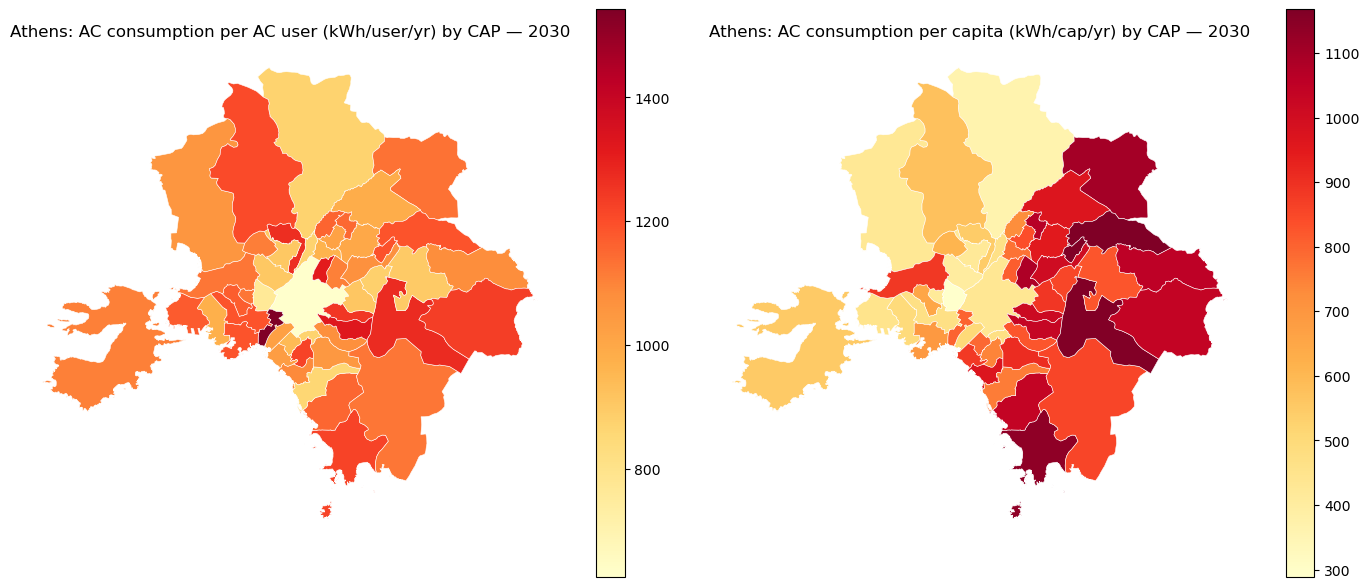


Zone-level results for year 2040
City pop: 3,163,033
City AC users: 2,209,496 (AC share ≈ 0.699)
City total AC electricity: 2183.633 GWh/yr
City per-AC-user mean (users-weighted): 988.3 kWh/user/yr

Top 10 zones by kwh_pc_overall — kWh per capita (overall), 2040


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,43,0.926,"1,277.506","25,001.855","29,575,265.349","1,182.923",2040
1,13,0.980,"1,192.595","28,123.714","32,869,405.645","1,168.743",2040
2,48,0.980,"1,190.645","35,839.587","41,818,786.316","1,166.832",2040
3,12,0.947,"1,223.976","27,513.140","31,903,362.832","1,159.568",2040
4,18,0.980,"1,133.166","1,653.190","1,835,872.967","1,110.503",2040
5,57,0.980,"1,106.938","31,019.657","33,650,087.793","1,084.799",2040
6,32,0.942,"1,149.674","31,930.700","34,574,383.820","1,082.794",2040
7,52,0.980,"1,083.275","1,751.952","1,859,889.673","1,061.610",2040
8,55,0.859,"1,231.517",296.042,"312,995.119","1,057.267",2040
9,16,0.915,"1,153.155","84,802.889","89,504,935.585","1,055.447",2040


Bottom 10 zones by kwh_pc_overall — kWh per capita (overall), 2040


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,7,0.382,765.319,"56,368.776","16,493,756.947",292.604,2040
1,11,0.423,875.699,"85,948.997","31,809,860.685",370.102,2040
2,50,0.453,908.055,"124,897.840","51,340,864.298",411.063,2040
3,2,0.375,"1,125.384","22,790.120","9,626,006.982",422.376,2040
4,24,0.473,905.824,"76,302.912","32,685,973.484",428.371,2040
5,10,0.412,"1,056.484","25,239.565","10,996,103.214",435.669,2040
6,6,0.707,625.361,"565,508.390","250,141,577.565",442.330,2040
7,49,0.390,"1,175.207","25,144.038","11,514,125.674",457.927,2040
8,41,0.538,875.957,"42,212.008","19,884,029.022",471.051,2040
9,42,0.401,"1,188.930","101,340.307","48,298,636.432",476.598,2040



Top 10 zones by kwh_cap — Total kWh, 2040


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,6,0.707,625.361,"565,508.390","250,141,577.565",442.330,2040
1,47,0.592,"1,189.084","166,637.869","117,370,647.044",704.346,2040
2,16,0.915,"1,153.155","84,802.889","89,504,935.585","1,055.447",2040
3,59,0.958,"1,071.734","85,510.655","87,772,981.342","1,026.457",2040
4,22,0.881,"1,049.550","76,058.821","70,299,635.627",924.280,2040
5,21,0.827,"1,249.283","66,916.875","69,105,176.198","1,032.702",2040
6,28,0.980,986.943,"64,155.157","62,051,119.559",967.204,2040
7,44,0.866,"1,035.244","68,749.549","61,608,689.171",896.132,2040
8,9,0.971,998.472,"62,638.190","60,744,668.869",969.771,2040
9,40,0.851,946.062,"75,471.104","60,740,649.535",804.820,2040


Bottom 10 zones by kwh_cap — Total kWh, 2040


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,53,0.508,"1,105.761",189.543,"106,438.360",561.553,2040
1,55,0.859,"1,231.517",296.042,"312,995.119","1,057.267",2040
2,18,0.980,"1,133.166","1,653.190","1,835,872.967","1,110.503",2040
3,52,0.980,"1,083.275","1,751.952","1,859,889.673","1,061.610",2040
4,2,0.375,"1,125.384","22,790.120","9,626,006.982",422.376,2040
5,10,0.412,"1,056.484","25,239.565","10,996,103.214",435.669,2040
6,49,0.390,"1,175.207","25,144.038","11,514,125.674",457.927,2040
7,7,0.382,765.319,"56,368.776","16,493,756.947",292.604,2040
8,17,0.546,875.762,"38,846.949","18,582,851.996",478.361,2040
9,30,0.774,"1,126.015","22,546.675","19,649,689.645",871.512,2040


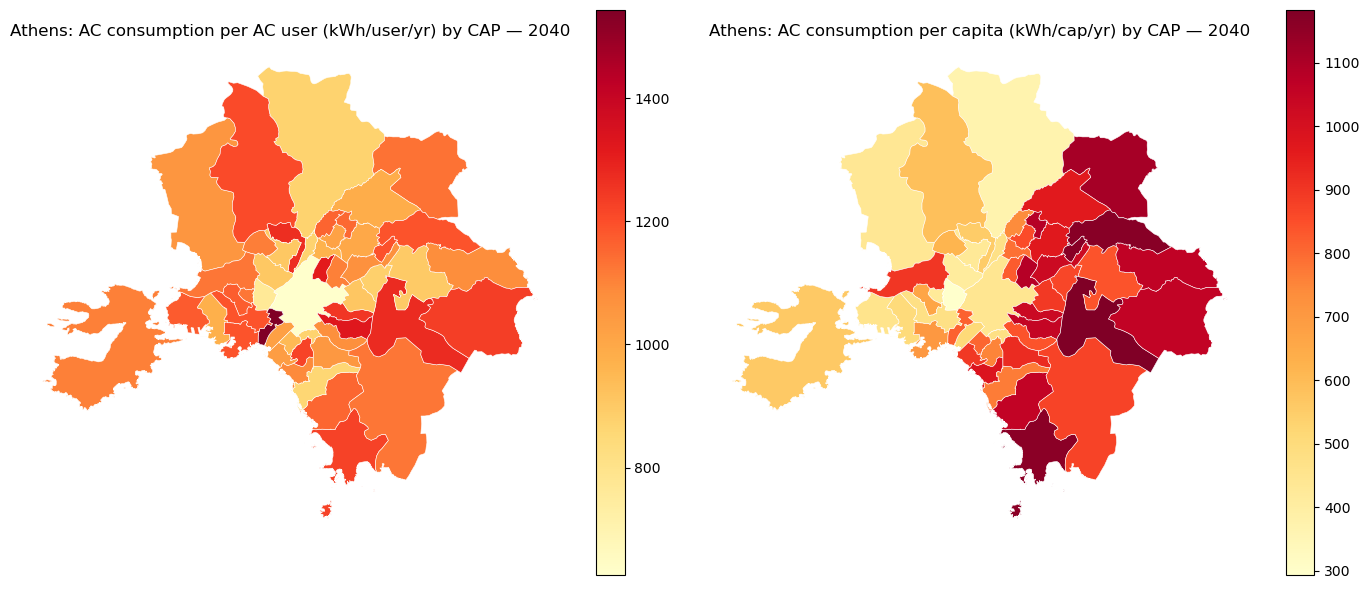


Zone-level results for year 2050
City pop: 3,090,334
City AC users: 2,160,144 (AC share ≈ 0.699)
City total AC electricity: 2368.484 GWh/yr
City per-AC-user mean (users-weighted): 1096.4 kWh/user/yr

Top 10 zones by kwh_pc_overall — kWh per capita (overall), 2050


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,43,0.926,"1,417.845","24,341.661","31,957,466.594","1,312.871",2050
1,13,0.980,"1,323.765","27,350.300","35,481,265.482","1,297.290",2050
2,48,0.980,"1,321.525","34,956.558","45,272,040.718","1,295.094",2050
3,12,0.947,"1,358.447","26,836.790","34,537,946.146","1,286.963",2050
4,18,0.980,"1,257.436","1,607.219","1,980,555.256","1,232.287",2050
5,57,0.980,"1,228.266","30,729.452","36,989,065.683","1,203.701",2050
6,32,0.942,"1,275.655","31,174.347","37,454,323.032","1,201.447",2050
7,52,0.980,"1,202.023","1,709.461","2,013,715.306","1,177.983",2050
8,55,0.859,"1,366.688",289.596,"339,786.321","1,173.312",2050
9,16,0.915,"1,279.631","82,851.403","97,036,084.579","1,171.206",2050


Bottom 10 zones by kwh_pc_overall — kWh per capita (overall), 2050


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,7,0.382,849.444,"55,105.741","17,896,574.996",324.768,2050
1,11,0.423,971.731,"82,819.637","34,013,050.259",410.688,2050
2,50,0.453,"1,007.722","121,734.323","55,532,822.234",456.180,2050
3,2,0.375,"1,248.716","22,267.063","10,435,789.931",468.665,2050
4,24,0.473,"1,005.234","74,201.512","35,274,132.589",475.383,2050
5,10,0.412,"1,172.272","24,394.825","11,792,886.316",483.418,2050
6,6,0.707,694.162,"553,665.008","271,846,595.528",490.995,2050
7,49,0.390,"1,304.012","24,378.103","12,386,912.490",508.116,2050
8,41,0.538,972.112,"41,297.976","21,588,900.286",522.759,2050
9,42,0.401,"1,319.262","98,906.358","52,306,033.151",528.844,2050



Top 10 zones by kwh_cap — Total kWh, 2050


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,6,0.707,694.162,"553,665.008","271,846,595.528",490.995,2050
1,47,0.592,"1,319.533","163,288.532","127,629,023.480",781.617,2050
2,16,0.915,"1,279.631","82,851.403","97,036,084.579","1,171.206",2050
3,59,0.958,"1,189.231","83,970.340","95,641,387.061","1,138.990",2050
4,22,0.881,"1,164.575","74,514.741","76,420,561.267","1,025.576",2050
5,21,0.827,"1,386.180","65,379.936","74,916,611.485","1,145.865",2050
6,28,0.980,"1,095.080","63,144.928","67,765,769.705","1,073.178",2050
7,44,0.866,"1,148.711","67,677.474","67,295,231.341",994.352,2050
8,40,0.851,"1,049.813","74,199.371","66,266,102.309",893.082,2050
9,9,0.971,"1,107.819","61,406.444","66,071,729.911","1,075.974",2050


Bottom 10 zones by kwh_cap — Total kWh, 2050


,zone_id,ac_share_cap,kwh_per_user_cap,pop_zone,kwh_cap,kwh_pc_overall,year
0,53,0.508,"1,226.960",187.649,"116,924.915",623.103,2050
1,55,0.859,"1,366.688",289.596,"339,786.321","1,173.312",2050
2,18,0.980,"1,257.436","1,607.219","1,980,555.256","1,232.287",2050
3,52,0.980,"1,202.023","1,709.461","2,013,715.306","1,177.983",2050
4,2,0.375,"1,248.716","22,267.063","10,435,789.931",468.665,2050
5,10,0.412,"1,172.272","24,394.825","11,792,886.316",483.418,2050
6,49,0.390,"1,304.012","24,378.103","12,386,912.490",508.116,2050
7,7,0.382,849.444,"55,105.741","17,896,574.996",324.768,2050
8,17,0.546,971.757,"38,135.409","20,242,097.730",530.795,2050
9,30,0.774,"1,249.589","22,017.429","21,294,280.873",967.156,2050


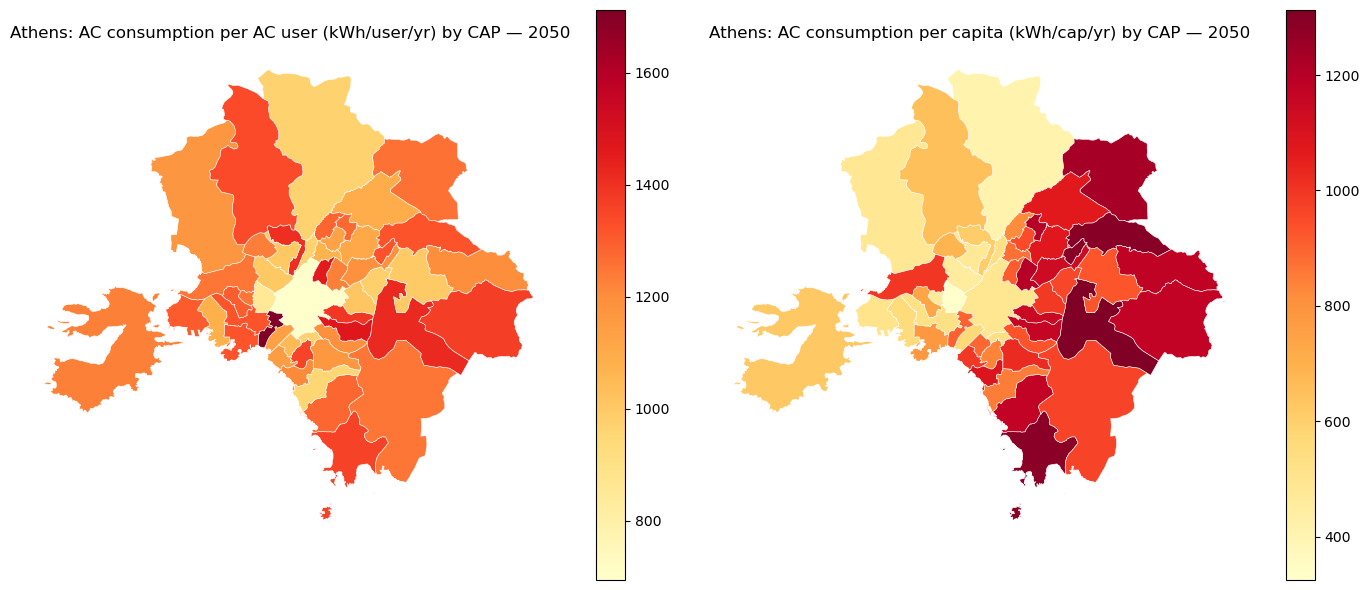


✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/athens_cap_ac_consumption_summary.csv
✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/athens_cap_ac_consumption_map.geojson


In [68]:
import matplotlib.pyplot as plt

years_maps = [2020, 2030, 2040, 2050]

def show_rank_cap(df, col, k=10, title=""):
    """Display top and bottom k zones by a given column."""
    cols = ["zone_id", "ac_share_cap", "kwh_per_user_cap", "pop_zone", "kwh_cap", "kwh_pc_overall", "year"]
    cols = [c for c in cols if c in df.columns]
    top = df[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} zones by {col} — {title}")
    display(top)
    print(f"Bottom {k} zones by {col} — {title}")
    display(bot)

all_zone_tbl = []
all_zone_map = []

for year_map in years_maps:
    print(f"\n{'='*60}")
    print(f"Zone-level results for year {year_map}")
    print('='*60)

    # Year-specific data
    pop_grid = POP_GRID.get(year_map, pop_on_ref)
    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]
    cap_per_user = zone_per_user_by_year[year_map]

    # Matched pixel universe
    ZONE_PIX = (CITY_MASK & (zone_ids > 0) &
               np.isfinite(pop_grid) &
               np.isfinite(coverage_map) &
               np.isfinite(kwh_tot_map))

    # Users and pop by CAP
    df_zone_base = pd.DataFrame({
        "zone_id": zone_ids[ZONE_PIX].ravel().astype(int),
        "pop": pop_grid[ZONE_PIX].ravel().astype(float),
        "users": (coverage_map[ZONE_PIX] * pop_grid[ZONE_PIX]).ravel().astype(float),
    })
    zone_pop_users = (df_zone_base.groupby("zone_id", as_index=False)
                     .agg(pop_zone=("pop", "sum"), users_zone=("users", "sum")))
    zone_pop_users["ac_share_cap"] = np.where(
        zone_pop_users["pop_zone"] > 0,
        zone_pop_users["users_zone"] / zone_pop_users["pop_zone"],
        np.nan
    )

    # Energy totals by CAP
    df_kwh = pd.DataFrame({
        "zone_id": zone_ids[ZONE_PIX].ravel().astype(int),
        "kwh": kwh_tot_map[ZONE_PIX].ravel().astype(float),
    })
    cap_energy = df_kwh.groupby("zone_id", as_index=False).agg(kwh_cap=("kwh", "sum"))

    # Merge and compute per-capita
    zone_tbl = (zone_pop_users
               .merge(cap_energy, on="zone_id", how="left")
               .merge(cap_per_user, on="zone_id", how="left"))
    zone_tbl["kwh_pc_overall"] = np.where(
        zone_tbl["pop_zone"] > 0,
        zone_tbl["kwh_cap"] / zone_tbl["pop_zone"],
        np.nan
    )
    zone_tbl["year"] = year_map
    all_zone_tbl.append(zone_tbl)

    # City diagnostics
    city_pop = float(np.nansum(pop_grid[ZONE_PIX]))
    city_users = float(np.nansum((coverage_map * pop_grid)[ZONE_PIX]))
    city_kwh_GWh = float(np.nansum(kwh_tot_map[ZONE_PIX])) / 1e6
    per_user_mean_city = float(
        np.nansum(zone_tbl["kwh_per_user_cap"] * zone_tbl["users_zone"]) / max(city_users, 1e-12)
    )
    print(f"City pop: {city_pop:,.0f}")
    print(f"City AC users: {city_users:,.0f} (AC share ≈ {city_users/city_pop:.3f})")
    print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
    print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.1f} kWh/user/yr")

    # Top/bottom tables
    show_rank_cap(zone_tbl, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank_cap(zone_tbl, "kwh_cap", k=10, title=f"Total kWh, {year_map}")

    # Join to CAP polygons for mapping
    zone_map = zone_4326.merge(zone_tbl, on="zone_id", how="left")
    zone_map["year"] = year_map
    zone_map_4326 = zone_map.to_crs("EPSG:4326")
    all_zone_map.append(zone_map_4326)

    # Maps
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    zone_map_4326.plot(ax=ax, column="kwh_per_user_cap", legend=True,
                      linewidth=0.4, edgecolor="white", cmap="YlOrRd")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) by CAP — {year_map}")
    ax.set_axis_off()

    ax = axes[1]
    zone_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True,
                      linewidth=0.4, edgecolor="white", cmap="YlOrRd")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) by CAP — {year_map}")
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_cap_ac_consumption_{year_map}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Save all years together
zone_tbl_all = pd.concat(all_zone_tbl, ignore_index=True)
zone_tbl_all["kwh_GWh"] = zone_tbl_all["kwh_cap"] / 1e6
zone_tbl_csv = OUT / f"{SLUG}_cap_ac_consumption_summary.csv"
zone_tbl_all.to_csv(zone_tbl_csv, index=False)

zone_map_all = gpd.GeoDataFrame(pd.concat(all_zone_map, ignore_index=True), crs="EPSG:4326")
cap_geojson = OUT / f"{SLUG}_cap_ac_consumption_map.geojson"
(zone_map_all[["zone_id", "geometry", "year", "kwh_per_user_cap", "ac_share_cap", "kwh_pc_overall", "kwh_cap"]]
 .to_file(cap_geojson, driver="GeoJSON"))

print(f"\n✓ Saved: {zone_tbl_csv}")
print(f"✓ Saved: {cap_geojson}")

### 6.5 Region-level analysis and maps

Region-level outputs use the same zone layer (Dimoi) rather than the raw zone table whenever policy reporting is meant to happen on the region layer.

The tables and maps below aggregate electricity consumption to the same zone layer (Dimoi).

**Why do the "per AC user" and "per capita" maps look different?**
The two maps use different denominators:
- **Per AC user**: `kWh / (population × AC share)`. This isolates intensity of use among AC users and therefore responds strongly to the hazard-based downscaling.
- **Per capita**: `kWh / population`. This combines both the intensity of use and the local AC penetration rate.


Region-level results for year 2020

Top 10 regions by kwh_pc_overall — kWh per capita, 2020


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,13,0.980,"1,193.488","29,617.584","34,641,264.613","1,169.618",2020
1,48,0.980,"1,191.679","38,372.247","44,812,844.517","1,167.845",2020
2,43,0.911,"1,278.719","26,383.227","30,742,056.372","1,165.212",2020
3,12,0.932,"1,225.149","28,334.756","32,363,769.787","1,142.193",2020
4,18,0.971,"1,134.741","1,741.646","1,919,723.387","1,102.246",2020
5,57,0.980,"1,108.618","32,600.267","35,418,418.674","1,086.446",2020
6,32,0.927,"1,151.444","34,056.208","36,344,617.578","1,067.195",2020
7,52,0.971,"1,084.911","1,790.946","1,886,815.476","1,053.530",2020
8,55,0.845,"1,232.935",311.979,"324,996.251","1,041.724",2020
9,16,0.901,"1,154.714","90,151.180","93,763,873.783","1,040.074",2020


Bottom 10 regions by kwh_pc_overall — kWh per capita, 2020


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,7,0.377,766.313,"65,347.371","18,865,958.312",288.703,2020
1,11,0.416,877.165,"94,086.899","34,362,954.185",365.226,2020
2,50,0.446,909.347,"140,988.639","57,169,593.750",405.491,2020
3,2,0.370,"1,127.103","23,553.096","9,818,259.917",416.856,2020
4,24,0.466,907.145,"82,691.742","34,941,028.759",422.546,2020
5,10,0.406,"1,058.145","27,136.164","11,666,028.070",429.907,2020
6,6,0.696,626.233,"619,508.634","270,121,493.847",436.025,2020
7,49,0.384,"1,176.935","26,224.822","11,850,432.569",451.878,2020
8,41,0.530,877.213,"46,067.534","21,399,875.287",464.533,2020
9,42,0.395,"1,190.617","111,435.279","52,402,521.463",470.251,2020


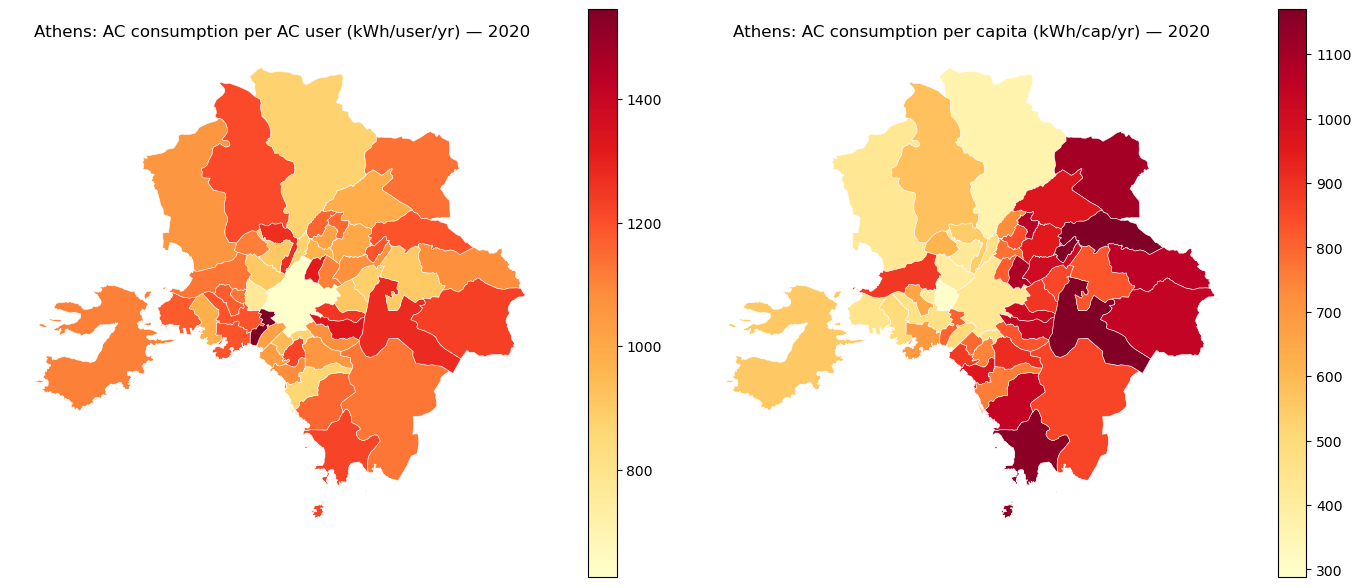


Region-level results for year 2030

Top 10 regions by kwh_pc_overall — kWh per capita, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,13,0.980,"1,191.843","29,142.506","34,038,617.418","1,168.006",2030
1,48,0.980,"1,189.927","37,017.281","43,166,916.689","1,166.129",2030
2,43,0.911,"1,276.780","25,895.926","30,128,509.380","1,163.446",2030
3,12,0.932,"1,223.266","28,400.368","32,388,876.292","1,140.439",2030
4,18,0.971,"1,132.607","1,715.630","1,887,490.817","1,100.174",2030
5,57,0.980,"1,106.419","31,394.441","34,040,695.179","1,084.291",2030
6,32,0.927,"1,149.151","32,915.799","35,057,636.340","1,065.070",2030
7,52,0.971,"1,082.761","1,810.565","1,903,703.712","1,051.442",2030
8,55,0.845,"1,230.867",305.040,"317,234.401","1,039.976",2030
9,16,0.901,"1,152.581","87,323.123","90,654,736.879","1,038.153",2030


Bottom 10 regions by kwh_pc_overall — kWh per capita, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,7,0.377,764.867,"57,873.147","16,676,604.499",288.158,2030
1,11,0.416,875.296,"90,156.572","32,857,310.721",364.447,2030
2,50,0.446,907.576,"128,905.300","52,168,067.126",404.701,2030
3,2,0.370,"1,124.860","23,470.078","9,764,177.789",416.027,2030
4,24,0.466,905.354,"79,059.227","33,340,147.863",421.711,2030
5,10,0.406,"1,055.991","26,414.174","11,332,524.444",429.032,2030
6,6,0.696,624.957,"579,173.226","252,019,749.278",435.137,2030
7,49,0.384,"1,174.653","26,131.190","11,785,230.299",451.002,2030
8,41,0.530,875.489,"43,357.937","20,101,581.610",463.619,2030
9,42,0.395,"1,188.357","104,413.022","49,007,106.345",469.358,2030


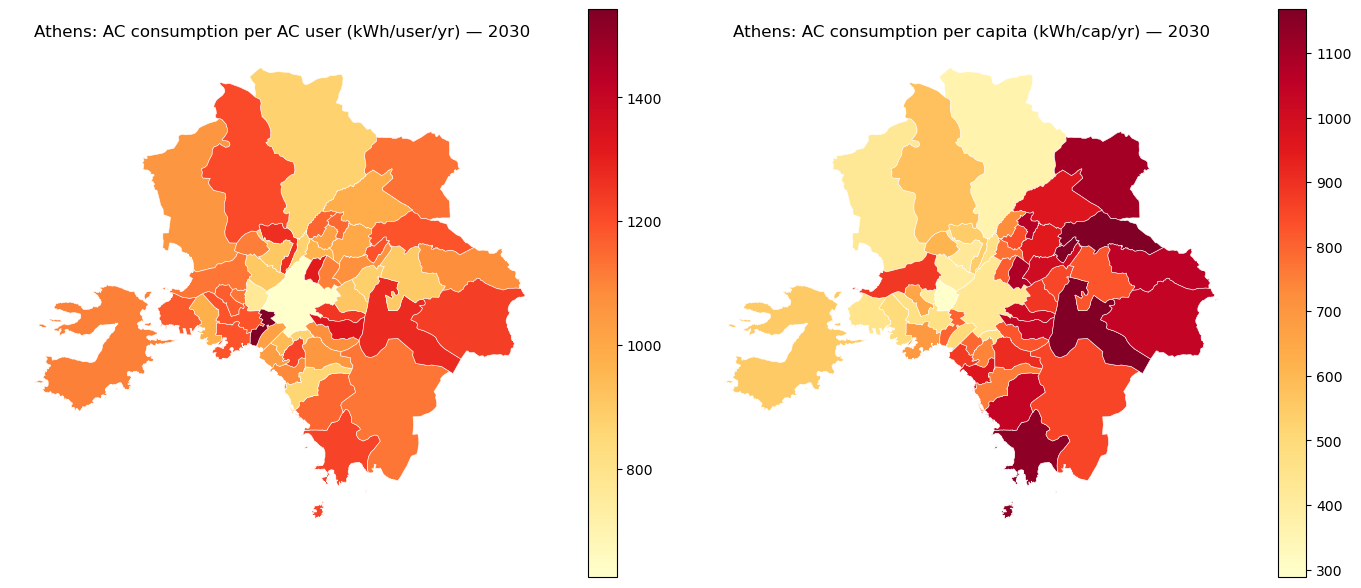


Region-level results for year 2040

Top 10 regions by kwh_pc_overall — kWh per capita, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,43,0.926,"1,277.506","25,001.855","29,575,265.349","1,182.923",2040
1,13,0.980,"1,192.595","28,123.714","32,869,405.645","1,168.743",2040
2,48,0.980,"1,190.645","35,839.587","41,818,786.316","1,166.832",2040
3,12,0.947,"1,223.976","27,513.140","31,903,362.832","1,159.568",2040
4,18,0.980,"1,133.166","1,653.190","1,835,872.967","1,110.503",2040
5,57,0.980,"1,106.938","31,019.657","33,650,087.793","1,084.799",2040
6,32,0.942,"1,149.674","31,930.700","34,574,383.820","1,082.794",2040
7,52,0.980,"1,083.275","1,751.952","1,859,889.673","1,061.610",2040
8,55,0.859,"1,231.517",296.042,"312,995.119","1,057.267",2040
9,16,0.915,"1,153.155","84,802.889","89,504,935.585","1,055.447",2040


Bottom 10 regions by kwh_pc_overall — kWh per capita, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,7,0.382,765.319,"56,368.776","16,493,756.947",292.604,2040
1,11,0.423,875.699,"85,948.997","31,809,860.685",370.102,2040
2,50,0.453,908.055,"124,897.840","51,340,864.298",411.063,2040
3,2,0.375,"1,125.384","22,790.120","9,626,006.982",422.376,2040
4,24,0.473,905.824,"76,302.912","32,685,973.484",428.371,2040
5,10,0.412,"1,056.484","25,239.565","10,996,103.214",435.669,2040
6,6,0.707,625.361,"565,508.390","250,141,577.565",442.330,2040
7,49,0.390,"1,175.207","25,144.038","11,514,125.674",457.927,2040
8,41,0.538,875.957,"42,212.008","19,884,029.022",471.051,2040
9,42,0.401,"1,188.930","101,340.307","48,298,636.432",476.598,2040


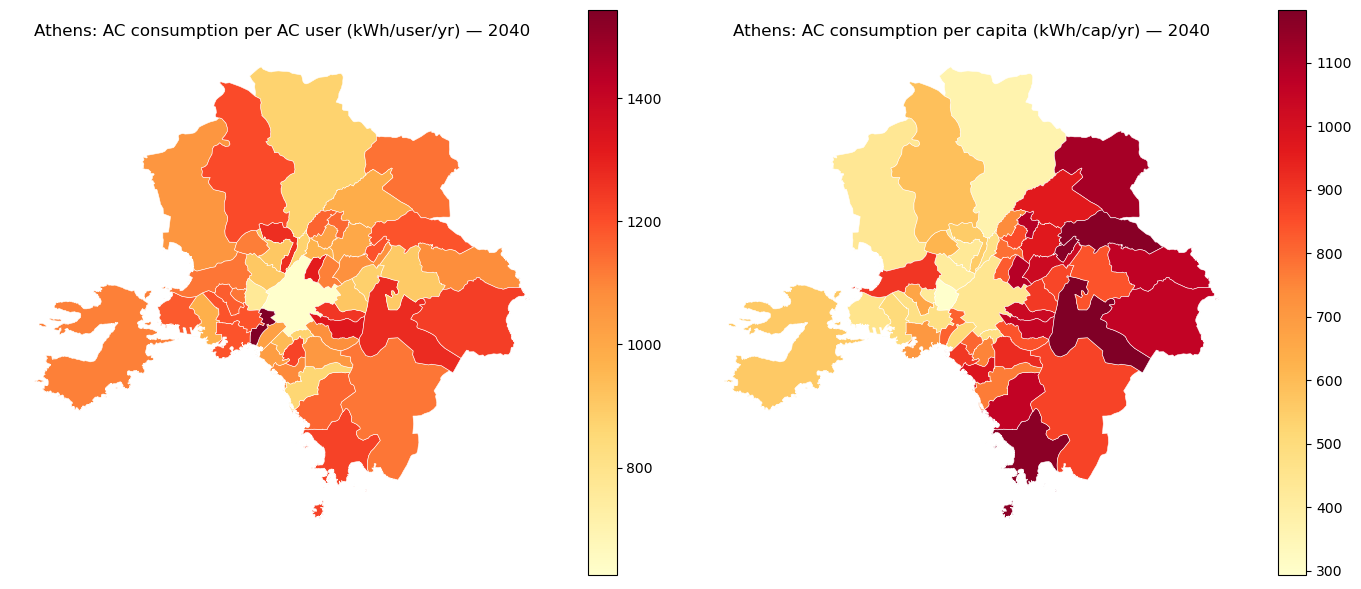


Region-level results for year 2050

Top 10 regions by kwh_pc_overall — kWh per capita, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,43,0.926,"1,417.845","24,341.661","31,957,466.594","1,312.871",2050
1,13,0.980,"1,323.765","27,350.300","35,481,265.482","1,297.290",2050
2,48,0.980,"1,321.525","34,956.558","45,272,040.718","1,295.094",2050
3,12,0.947,"1,358.447","26,836.790","34,537,946.146","1,286.963",2050
4,18,0.980,"1,257.436","1,607.219","1,980,555.256","1,232.287",2050
5,57,0.980,"1,228.266","30,729.452","36,989,065.683","1,203.701",2050
6,32,0.942,"1,275.655","31,174.347","37,454,323.032","1,201.447",2050
7,52,0.980,"1,202.023","1,709.461","2,013,715.306","1,177.983",2050
8,55,0.859,"1,366.688",289.596,"339,786.321","1,173.312",2050
9,16,0.915,"1,279.631","82,851.403","97,036,084.579","1,171.206",2050


Bottom 10 regions by kwh_pc_overall — kWh per capita, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,7,0.382,849.444,"55,105.741","17,896,574.996",324.768,2050
1,11,0.423,971.731,"82,819.637","34,013,050.259",410.688,2050
2,50,0.453,"1,007.722","121,734.323","55,532,822.234",456.180,2050
3,2,0.375,"1,248.716","22,267.063","10,435,789.931",468.665,2050
4,24,0.473,"1,005.234","74,201.512","35,274,132.589",475.383,2050
5,10,0.412,"1,172.272","24,394.825","11,792,886.316",483.418,2050
6,6,0.707,694.162,"553,665.008","271,846,595.528",490.995,2050
7,49,0.390,"1,304.012","24,378.103","12,386,912.490",508.116,2050
8,41,0.538,972.112,"41,297.976","21,588,900.286",522.759,2050
9,42,0.401,"1,319.262","98,906.358","52,306,033.151",528.844,2050


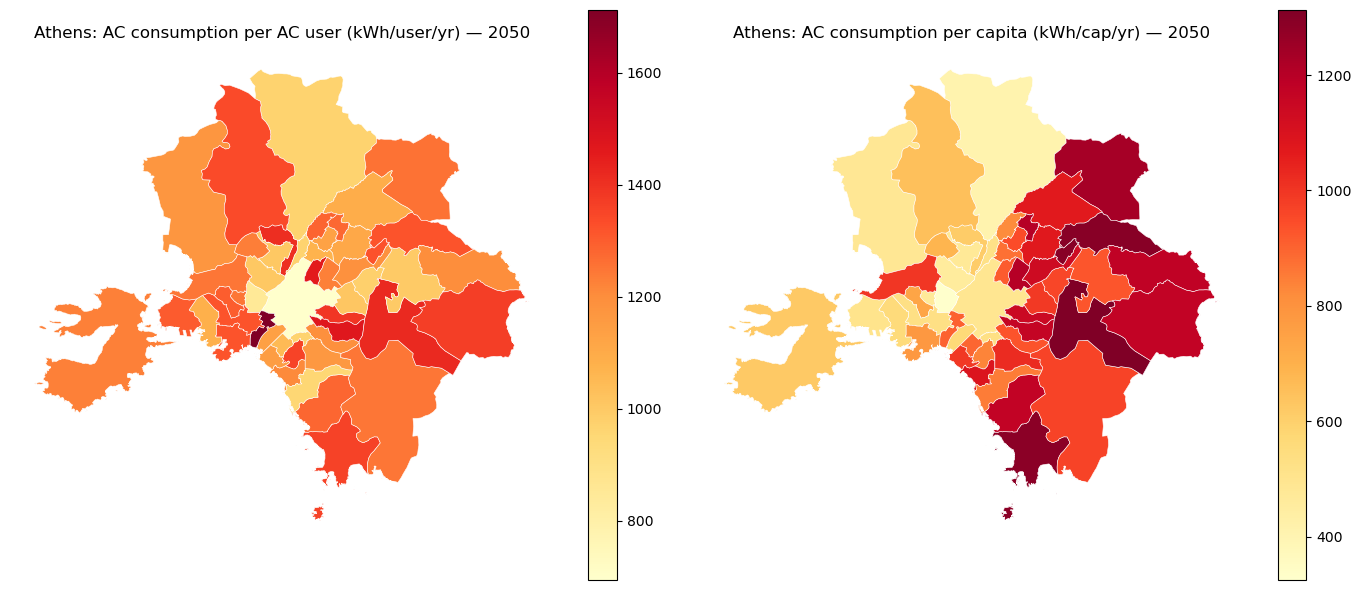


✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/athens_muni_ac_consumption_summary.csv


✓ Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/athens_muni_ac_consumption_map.geojson


In [69]:
years_maps = [2020, 2030, 2040, 2050]

# muni and muni_on_ref already loaded in Section 1.8
assert 'muni_on_ref' in globals(), "muni_on_ref missing — run Section 1.8"
assert 'muni' in globals() and isinstance(muni, gpd.GeoDataFrame), "muni GDF missing — run Section 1.8"

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

def show_rank_muni(df_in, col, k=10, title=""):
    """Display top and bottom k regions by a given column."""
    cols = ["muni_id", "ac_share_muni", "kwh_per_user_muni", "pop_muni", "kwh_muni", "kwh_pc_overall", "year"]
    cols = [c for c in cols if c in df_in.columns]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} regions by {col} — {title}")
    display(top)
    print(f"Bottom {k} regions by {col} — {title}")
    display(bot)

all_muni_tbl = []
all_muni_map = []

for year_map in years_maps:
    print(f"\n{'='*60}")
    print(f"Region-level results for year {year_map}")
    print('='*60)

    # Year-specific data
    pop_grid = POP_GRID.get(year_map, pop_on_ref)
    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]

    # Build pixel-to-region table
    valid_all = (MASK_POLICY &
                 np.isfinite(per_user_map) &
                 np.isfinite(kwh_tot_map) &
                 np.isfinite(pop_grid) &
                 np.isfinite(coverage_map))

    df = pd.DataFrame({
        "muni_id": muni_on_ref[valid_all].ravel().astype(int),
        "pop": pop_grid[valid_all].ravel().astype(float),
        "users": (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
        "kwh": kwh_tot_map[valid_all].ravel().astype(float),
        "per_user": per_user_map[valid_all].ravel().astype(float),
    })

    # Users-weighted per-user by region
    per_user_by_muni = (df.groupby("muni_id")
                        .apply(lambda g: _wavg(g["per_user"], g["users"]))
                        .reset_index(name="kwh_per_user_muni"))

    # Totals by region
    muni_tbl = (df.groupby("muni_id", as_index=False)
                .agg(pop_muni=("pop", "sum"), users_muni=("users", "sum"), kwh_muni=("kwh", "sum"))
                .merge(per_user_by_muni, on="muni_id", how="left"))

    # Rates
    muni_tbl["ac_share_muni"] = np.where(
        muni_tbl["pop_muni"] > 0,
        muni_tbl["users_muni"] / muni_tbl["pop_muni"],
        np.nan
    )
    muni_tbl["kwh_pc_overall"] = np.where(
        muni_tbl["pop_muni"] > 0,
        muni_tbl["kwh_muni"] / muni_tbl["pop_muni"],
        np.nan
    )
    muni_tbl["year"] = year_map
    all_muni_tbl.append(muni_tbl)

    # Tables for regions only (exclude id==0)
    muni_only = muni_tbl[muni_tbl["muni_id"] > 0].copy()
    show_rank_muni(muni_only, "kwh_pc_overall", k=10, title=f"kWh per capita, {year_map}")

    # Map join
    muni_cols = ["muni_id", "muni_name", "geometry"] if "muni_name" in muni.columns else ["muni_id", "geometry"]
    muni_map = muni[muni_cols].merge(muni_only, on="muni_id", how="left")
    muni_map["year"] = year_map
    muni_map_4326 = muni_map.to_crs("EPSG:4326")
    all_muni_map.append(muni_map_4326)

    # Maps
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    muni_map_4326.plot(ax=ax, column="kwh_per_user_muni", legend=True,
                       linewidth=0.4, edgecolor="white", cmap="YlOrRd")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) — {year_map}")
    ax.set_axis_off()

    ax = axes[1]
    muni_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True,
                       linewidth=0.4, edgecolor="white", cmap="YlOrRd")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) — {year_map}")
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_region_ac_consumption_{year_map}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Save all years together
muni_tbl_all_years = pd.concat(all_muni_tbl, ignore_index=True)
muni_csv = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
muni_tbl_all_years.to_csv(muni_csv, index=False)
print(f"\n✓ Saved: {muni_csv}")

# Save GeoJSON with all years
muni_map_all = gpd.GeoDataFrame(pd.concat(all_muni_map, ignore_index=True), crs="EPSG:4326")
muni_geo = OUT / f"{SLUG}_muni_ac_consumption_map.geojson"
(muni_map_all[["muni_id", "geometry", "year", "kwh_per_user_muni", "ac_share_muni", "kwh_pc_overall", "kwh_muni"]]
 .to_file(muni_geo, driver="GeoJSON"))
print(f"✓ Saved: {muni_geo}")

### 6.6 Cost inputs summary (for `NB08` CBA)

This block verifies the main exports needed by the CBA notebook: coverage trajectories, electricity demand, and the cost parameters attached to the AC policy. `NB08` will later combine these with discounting, waste-heat penalties, and the other adaptation options.

In [70]:
print("="*60)
print("COST INPUTS FOR NB8 CBA")
print("="*60)

# 1. AC Cost Parameters (will be used in NB8)
print("\n1. AC Cost Parameters:")
print(f"   CAPEX per user:     €{AC_CAPEX_PER_USER:,.0f}")
print(f"   Maintenance rate:   {AC_MAINT_RATE:.0%} of CAPEX/year")
print(f"   Lifetime:           {AC_LIFETIME_YEARS} years")
print(f"   Electricity tariff: €{TARIFF_EUR_PER_KWH:.2f}/kWh")

# 2. Verify Municipio coverage exports exist
muni_cov_path = OUT / f"{SLUG}_muni_cov_yearly.csv"
if muni_cov_path.exists():
    muni_cov_check = pd.read_csv(muni_cov_path)
    print(f"\n2. Municipio Coverage Trajectories:")
    print(f"   Found: {muni_cov_path.name}")
    print(f"   Years: {sorted(muni_cov_check['year'].unique())}")
    print(f"   Columns: {list(muni_cov_check.columns)}")
else:
    print(f"\n2. Municipio Coverage Trajectories:")
    print(f"   Missing: {muni_cov_path.name}")
    print(f"   Will be created from muni_cov DataFrame")

# 3. Verify electricity consumption exports exist
muni_elec_path = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
if muni_elec_path.exists():
    muni_elec_check = pd.read_csv(muni_elec_path)
    print(f"\n3. Municipio Electricity Consumption:")
    print(f"   Found: {muni_elec_path.name}")
    print(f"   Years: {sorted(muni_elec_check['year'].unique())}")
    print(f"   Avg kWh/user (2050): {muni_elec_check[muni_elec_check['year']==2050]['kwh_per_user_muni'].mean():,.0f}")
else:
    print(f"\n3. Municipio Electricity Consumption:")
    print(f"   Missing: {muni_elec_path.name}")

# 4. Summary of coverage trajectories (population-weighted)
print(f"\n4. Coverage Summary (citywide, population-weighted):")
for k, year in enumerate(YEARS_AC):
    m = CITY_MASK & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    pop_m = pop_on_ref[m]
    
    cov_base_m = coverage_base_3d[k][m]
    cov_base = float(np.sum(cov_base_m * pop_m) / np.sum(pop_m))
    
    if coverage_policy_3d is not None:
        cov_pol_m = coverage_policy_3d[k][m]
        cov_pol = float(np.sum(cov_pol_m * pop_m) / np.sum(pop_m))
        print(f"   {year}: Baseline {cov_base:.1%} → Policy {cov_pol:.1%} (Δ = {cov_pol-cov_base:.1%})")
    else:
        print(f"   {year}: Baseline {cov_base:.1%}")

# 5. Save cost parameters to JSON for NB8
ac_cost_params = {
    "capex_per_user": AC_CAPEX_PER_USER,
    "maint_rate": AC_MAINT_RATE,
    "lifetime_years": AC_LIFETIME_YEARS,
    "tariff_eur_per_kwh": TARIFF_EUR_PER_KWH,
    "maint_per_user_yr": maint_per_user_yr,
}

import json
with open(INT / f"ac_cost_params_{SLUG}.json", "w") as f:
    json.dump(ac_cost_params, f, indent=2)
print(f"\n5. Saved: ac_cost_params_{SLUG}.json")

print("\n" + "="*60)
print("Ready for NB8 CBA calculation")
print("="*60)
print("""
NB8 will compute:
- Time-varying users (baseline vs policy) per Municipio
- Cohort-based CAPEX with replacement cycles
- Incremental electricity costs per year
- Waste heat feedback on temperature
- Full PV of all cost streams
""")

COST INPUTS FOR NB8 CBA

1. AC Cost Parameters:
   CAPEX per user:     €500
   Maintenance rate:   5% of CAPEX/year
   Lifetime:           10 years
   Electricity tariff: €0.25/kWh

2. Municipio Coverage Trajectories:
   Found: athens_muni_cov_yearly.csv
   Years: [2020, 2030, 2040, 2050]
   Columns: ['muni_id', 'ac_base_muni', 'ac_policy_muni', 'ac_policy_uniform', 'pop_muni', 'year', 'region_name']

3. Municipio Electricity Consumption:
   Found: athens_muni_ac_consumption_summary.csv
   Years: [2020, 2030, 2040, 2050]
   Avg kWh/user (2050): 1,197

4. Coverage Summary (citywide, population-weighted):
   2020: Baseline nan% → Policy nan% (Δ = nan%)
   2030: Baseline nan% → Policy nan% (Δ = nan%)
   2040: Baseline nan% → Policy nan% (Δ = nan%)
   2050: Baseline nan% → Policy nan% (Δ = nan%)

5. Saved: ac_cost_params_athens.json

Ready for NB8 CBA calculation

NB8 will compute:
- Time-varying users (baseline vs policy) per Municipio
- Cohort-based CAPEX with replacement cycles
- Increm

## 7. AC feedback on temperature (waste-heat mechanism)

This section quantifies the negative externality of AC in three steps: estimate marginal deaths per `+1 °C`, map population-weighted AC penetration to ambient warming using the Salamanca lookup table, and convert that warming into a preliminary mortality penalty time series exported for `NB08`. Protection and waste heat are therefore kept separate until the CBA notebook nets them together.

### Conceptual setup

AC has two opposing effects on heat mortality:

1. **Protection**: the attenuation term `1 - efficacy × coverage` reduces the effective heat-mortality response for AC users.
2. **Waste heat**: higher AC penetration increases rejected heat outdoors, which can raise ambient temperature and create an additional mortality penalty.

The protective channel has already been included in the mortality calculations above. The feedback channel is handled here as an additional ambient `ΔT` that is later translated into extra deaths.

### 7.1 Marginal heat deaths per `+1 °C`

This first step estimates how many additional deaths would occur if outdoor temperature increased uniformly by `1 °C` under three AC states: no AC protection, current AC baseline, and policy AC. The result is the marginal death rate per degree that will later be combined with the waste-heat `ΔT` time series.

**7.1a - Helper functions**

The helper functions below rerun the mortality model on a perturbed hazard while keeping the relevant AC coverage scenario fixed.

In [71]:
# Helper functions for marginal deaths per +1°C under different AC states.
print("="*60)
print("SECTION 7: MARGINAL HEAT DEATHS PER +1°C")
print("="*60)

import copy

def hazard_add_deltaT_fast(H, deltaT: float):
    """Copy hazard and add uniform +deltaT (°C) to all intensity entries."""
    H2 = copy.copy(H)
    H2.intensity = H.intensity.copy()
    H2.intensity.data = H2.intensity.data + float(deltaT)
    return H2

def deaths_year_by_age_from_H(H_use, year, coverage_grid, eff_by_bucket, 
                               eff_base=None, age_ifs=None):
    """
    Compute deaths for a given year using a (possibly perturbed) hazard.
    
    NOTE: This function uses GLOBAL age_on_ref and pop_on_ref!
    """
    if age_ifs is None:
        age_ifs = get_age_ifs(year)
    
    dates = pd.to_datetime(H_use.date)
    idx = np.where(dates.year == int(year))[0]
    if idx.size == 0:
        return {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    # Uses GLOBAL pop_on_ref (must be set for correct year!)
    m_city = CITY_MASK & np.isfinite(pop_on_ref) & (pop_on_ref > 0)

    # Fill coverage holes with city pop-weighted mean
    cov = np.array(coverage_grid, dtype=float, copy=True)
    w = pop_on_ref[m_city].astype(float)
    x = np.nan_to_num(cov[m_city], nan=0.0).astype(float)
    mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
    cov = np.where(m_city & np.isfinite(cov), cov, mean_cov)

    out = {age_lbl: 0.0 for age_lbl in age_ifs.keys()}
    
    if eff_base is None:
        eff_base = EFF_DEFAULT

    for i_ev in idx:
        I_grid = _row_to_grid(H_use.intensity, i_ev, ref_data.shape)
        m = m_city & np.isfinite(I_grid)
        if not np.any(m):
            continue

        cov_m = np.where(m, cov, 0.0)

        for age_lbl, f in age_ifs.items():
            eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base)
            mdd = _interp_mdd(I_grid, f)
            mult = np.clip(1.0 - eff_a * cov_m, 0.0, 1.0)
            # Uses GLOBAL age_on_ref (must be set for correct year!)
            pop_a = np.nan_to_num(age_on_ref[age_lbl], 0.0)
            out[age_lbl] += float(np.nansum(pop_a[m] * mdd[m] * mult[m]))

    return out

SECTION 7: MARGINAL HEAT DEATHS PER +1°C


**7.1b - Marginal deaths calculation**

For each year, the notebook compares deaths at the original hazard and at `T + 1 °C`, then divides the difference by the imposed temperature increment.

In [72]:
# Compute annual deaths at T and T+ΔT so the marginal deaths per degree can be exported.
def annual_table_and_marginal_perC(H0, years, coverage_cube_or_none, 
                                    eff_buckets, eff_base, deltaT=1.0, label=""):
    """
    Compute deaths at base temperature and at +deltaT°C, return marginal.
    
    IMPORTANT: Updates global age_on_ref and pop_on_ref for each year!
    """
    global age_on_ref, pop_on_ref  # CRITICAL: Must declare global!
    
    H1 = hazard_add_deltaT_fast(H0, deltaT)
    
    rows = []
    for y in years:
        # Update GLOBAL grids for this year
        age_on_ref = AGE_GRID.get(int(y), age_on_ref_base)
        pop_on_ref = POP_GRID.get(int(y), pop_on_ref_base)
        
        # Get coverage for this year
        if coverage_cube_or_none is None:
            cov = np.zeros(ref_data.shape, dtype=float)
        else:
            cov = coverage_cube_or_none[year_to_index[int(y)]].astype(float)
        
        # Deaths at original temperature
        d0 = deaths_year_by_age_from_H(H0, int(y), cov, eff_buckets, eff_base=eff_base)
        deaths_T = sum(d0.values())
        
        # Deaths at +deltaT°C
        d1 = deaths_year_by_age_from_H(H1, int(y), cov, eff_buckets, eff_base=eff_base)
        deaths_T_plus = sum(d1.values())
        
        # Marginal deaths per °C
        marginal = deaths_T_plus - deaths_T
        
        rows.append({
            "year": int(y),
            "deaths_T": deaths_T,
            "deaths_T_plus_dT": deaths_T_plus,
            "marginal_per_C": marginal / deltaT,
            **{f"{k}": v for k, v in d0.items()},  # Age breakdown at base T
        })
        
        if label:
            print(f"  {label} {y}: {deaths_T:.1f} deaths → {deaths_T_plus:.1f} at +{deltaT}°C "
                  f"(marginal: {marginal/deltaT:.1f}/°C)")
    
    return pd.DataFrame(rows)

**7.1c - Run for all scenarios**

The three AC states are run in parallel so the feedback penalty can later be attached to the appropriate baseline or policy scenario.

In [73]:
# Run the marginal-death calculations for generic, current-AC, and policy-AC scenarios.
years_marginal = list(YEARS_AC)

# Scenario 1: Generic ("no" AC protection)
print("\n1. Generic (no AC):")
marginal_generic = annual_table_and_marginal_perC(
    H, years_marginal,
    coverage_cube_or_none=None,
    eff_buckets=EFF_BUCKETS,
    eff_base=0.0,
    label="generic"
)

# Scenario 2: Current AC (baseline coverage)
print("\n2. Current AC (baseline):")
marginal_current = annual_table_and_marginal_perC(
    H, years_marginal,
    coverage_cube_or_none=coverage_base_3d,
    eff_buckets=EFF_BUCKETS,
    eff_base=EFF_DEFAULT,
    label="currentAC"
)

# Scenario 3: Policy AC
print("\n3. Policy AC:")
marginal_policy = annual_table_and_marginal_perC(
    H, years_marginal,
    coverage_cube_or_none=coverage_policy_3d,
    eff_buckets=EFF_BUCKETS,
    eff_base=EFF_DEFAULT,
    label="policyAC"
)


1. Generic (no AC):


  generic 2020: 1832.5 deaths → 2537.6 at +1.0°C (marginal: 705.1/°C)


  generic 2030: 1969.1 deaths → 2710.5 at +1.0°C (marginal: 741.4/°C)


  generic 2040: 2055.9 deaths → 2819.0 at +1.0°C (marginal: 763.1/°C)


  generic 2050: 2310.2 deaths → 3148.6 at +1.0°C (marginal: 838.4/°C)

2. Current AC (baseline):


...

  currentAC 2050: 1689.4 deaths → 2302.1 at +1.0°C (marginal: 612.7/°C)

3. Policy AC:


  policyAC 2020: 1297.6 deaths → 1797.5 at +1.0°C (marginal: 499.9/°C)


  policyAC 2030: 1388.9 deaths → 1912.4 at +1.0°C (marginal: 523.5/°C)


  policyAC 2040: 1440.1 deaths → 1974.8 at +1.0°C (marginal: 534.8/°C)


  policyAC 2050: 1613.5 deaths → 2198.9 at +1.0°C (marginal: 585.4/°C)


In [74]:
marginal_generic.to_csv(INT / f"marginal_heat_deaths_perC_generic_{SLUG}.csv", index=False)
marginal_current.to_csv(INT / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv", index=False)
marginal_policy.to_csv(INT / f"marginal_heat_deaths_perC_policyAC_{SLUG}.csv", index=False)

# Also save baseline annual deaths for reference
baseline_annual = marginal_current[["year", "deaths_T"]].rename(columns={"deaths_T": "deaths_annual"})
baseline_annual.to_csv(INT / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv", index=False)

print(f"\n✓ Saved marginal death tables to {INT}/")


✓ Saved marginal death tables to /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/


### 7.2 Waste-heat warming (Salamanca et al. 2014)

### 7.2.1 Salamanca et al. (2014) lookup table

The configured lookup table maps citywide AC penetration to nighttime outdoor warming. The notebook then converts nighttime warming to daily-mean warming using a configurable factor and optionally applies a first-order COP-degradation amplification from the waste-heat config.

In [75]:
# Translate AC penetration into waste-heat warming using the Salamanca LUT plus optional COP-degradation amplification.
# Waste-heat feedback parameters from the city config.
# Load from config (city-agnostic) with hardcoded fallbacks

wh_cfg = cfg.get("ac", {}).get("waste_heat", {})

USE_AC_FEEDBACK = wh_cfg.get("enabled", True)

# LUT case (low / central / high)
DELTA_T_CASE = wh_cfg.get("lut_case_default", "central")

# Daily-mean = fraction × nighttime warming
DAILYMEAN_FROM_NIGHT = float(wh_cfg.get("dailymean_from_night_default", 0.50))

# Salamanca et al. (2014) LUT: penetration → nighttime ΔT (°C)
_lut_raw = wh_cfg.get("lut", {
    0.00: {"low": 0.00, "central": 0.00, "high": 0.00},
    0.35: {"low": 0.25, "central": 0.375, "high": 0.50},
    0.65: {"low": 0.50, "central": 0.750, "high": 1.00},
    1.00: {"low": 1.00, "central": 1.250, "high": 1.50},
})
AC_WASTEHEAT_LUT = {float(k): v for k, v in _lut_raw.items()}

# COP degradation feedback (Kou et al. 2026)
cop_cfg = wh_cfg.get("cop_degradation", {})
COP_DEGRADATION_ENABLED = cop_cfg.get("enabled", True)
COP_SENSITIVITY_DICT = cop_cfg.get("sensitivity_per_C", {"low": 0.04, "central": 0.065, "high": 0.09})
COP_REF = float(cop_cfg.get("cop_ref", 3.0))

def dT_night_from_penetration(pen, case="central"):
    """
    Interpolate nighttime warming from AC penetration using Salamanca et al. (2014).
    
    Parameters
    ----------
    pen : float or array
        AC penetration in [0, 1]
    case : str
        "low", "central", or "high"
    
    Returns
    -------
    Nighttime temperature increase (°C)
    """
    pen_points = np.array(sorted(AC_WASTEHEAT_LUT.keys()))
    dT_points = np.array([AC_WASTEHEAT_LUT[p][case] for p in pen_points])
    pen_clipped = np.clip(pen, 0.0, 1.0)
    return np.interp(pen_clipped, pen_points, dT_points)

def cop_amplification_factor(dT_night, cop_sensitivity, cop_ref=3.0):
    """
    First-order COP degradation correction (Kou et al. 2026).
    
    Waste heat warms outdoor air by dT_night → COP drops → AC rejects
    more heat → additional warming. Closed-form first-order correction:
    
        corrected_dT = dT_night × (1 + α)
        α = cop_sensitivity × dT_night × (1 + 1/COP_ref) / COP_ref
    
    For typical values (dT=0.75°C, sens=0.065, COP=3.0):
        α ≈ 0.065 × 0.75 × 1.33/3 ≈ 0.022 → ~2% amplification
    """
    alpha = cop_sensitivity * np.asarray(dT_night) * (1.0 + 1.0/cop_ref) / cop_ref
    return 1.0 + alpha

def dT_dailymean_from_penetration(pen, case="central"):
    """Daily-mean ΔT from AC penetration, with optional COP correction."""
    dT_night_raw = dT_night_from_penetration(pen, case)
    if COP_DEGRADATION_ENABLED:
        cop_sens = COP_SENSITIVITY_DICT.get(case, COP_SENSITIVITY_DICT.get("central", 0.065))
        amp = cop_amplification_factor(dT_night_raw, cop_sens, COP_REF)
        dT_night = dT_night_raw * amp
    else:
        dT_night = dT_night_raw
    return DAILYMEAN_FROM_NIGHT * dT_night

print(f"Waste heat feedback: {'ON' if USE_AC_FEEDBACK else 'OFF'}")
print(f"LUT case: {DELTA_T_CASE} (Salamanca et al. 2014)")
print(f"Daily-mean factor: {DAILYMEAN_FROM_NIGHT} × nighttime")
print(f"COP degradation: {'ON' if COP_DEGRADATION_ENABLED else 'OFF'}"
      f" (sensitivity={COP_SENSITIVITY_DICT}, COP_ref={COP_REF})")

# Show example amplification at 65% penetration
_ex_dT = dT_night_from_penetration(0.65, DELTA_T_CASE)
if COP_DEGRADATION_ENABLED:
    _ex_cop_sens = COP_SENSITIVITY_DICT.get(DELTA_T_CASE, 0.065)
    _ex_amp = cop_amplification_factor(_ex_dT, _ex_cop_sens, COP_REF)
    print(f"  Example: pen=65%, nighttime ΔT={_ex_dT:.3f}°C, "
          f"COP amplification={_ex_amp:.4f} (+{(_ex_amp-1)*100:.1f}%)")


Waste heat feedback: ON
LUT case: central (Salamanca et al. 2014)
Daily-mean factor: 0.5 × nighttime
COP degradation: ON (sensitivity={'low': 0.04, 'central': 0.065, 'high': 0.09}, COP_ref=3.0)
  Example: pen=65%, nighttime ΔT=0.750°C, COP amplification=1.0217 (+2.2%)


### 7.2.2 Build 25-year penetration time series (population-weighted)

The feedback calculation is based on citywide penetration trajectories rather than on single anchor years. Users and population are aggregated from the region coverage outputs, then interpolated across a 25-year horizon to create baseline and policy penetration paths that `NB08` can discount over time.

In [76]:
# Interpolate anchor-year penetration to a 25-year citywide time series.
print("\n" + "-"*60)
print("Building 25-year penetration time series...")
print("-"*60)

# Load municipio coverage data (saved earlier in Section 3)
muni_cov_path = OUT / f"{SLUG}_muni_cov_yearly.csv"
muni_cov_yearly = pd.read_csv(muni_cov_path)
print(f"✓ Loaded: {muni_cov_path.name}")
print(f"  Columns: {list(muni_cov_yearly.columns)}")
print(f"  Years: {sorted(muni_cov_yearly['year'].unique())}")

# Define time horizon (must match NB8)
T = 25
START_YEAR = int(muni_cov_yearly["year"].min())
YEARS_ALL = np.arange(START_YEAR, START_YEAR + T, dtype=int)

# Compute citywide users and population per year
# users = pop × coverage (penetration)
def compute_users_by_year(df, coverage_col):
    """Compute total AC users per year = sum(pop × coverage)"""
    df = df.copy()
    df["users"] = df["pop_muni"] * df[coverage_col]
    return df.groupby("year")["users"].sum()

def compute_pop_by_year(df):
    """Compute total population per year"""
    return df.groupby("year")["pop_muni"].sum()

# Get anchor year values
users_base_anchor = compute_users_by_year(muni_cov_yearly, "ac_base_muni")
users_policy_anchor = compute_users_by_year(muni_cov_yearly, "ac_policy_muni")
pop_anchor = compute_pop_by_year(muni_cov_yearly)

# Interpolate to full 25-year horizon
def interpolate_to_horizon(series, target_years):
    """Interpolate from anchor years to full horizon with edge clamping."""
    known_years = series.index.to_numpy(dtype=int)
    known_vals = series.to_numpy(dtype=float)
    out = np.interp(target_years, known_years, known_vals)
    out[target_years <= known_years[0]] = known_vals[0]
    out[target_years >= known_years[-1]] = known_vals[-1]
    return out

users_base_t = interpolate_to_horizon(users_base_anchor, YEARS_ALL)
users_policy_t = interpolate_to_horizon(users_policy_anchor, YEARS_ALL)
pop_total_t = interpolate_to_horizon(pop_anchor, YEARS_ALL)

# Compute penetration = users / population
pen_base_t = users_base_t / pop_total_t
pen_pol_t = users_policy_t / pop_total_t

print(f"\nPenetration time series (population-weighted):")
print(f"  Baseline: {pen_base_t[0]:.1%} ({YEARS_ALL[0]}) → {pen_base_t[-1]:.1%} ({YEARS_ALL[-1]})")
print(f"  Policy:   {pen_pol_t[0]:.1%} ({YEARS_ALL[0]}) → {pen_pol_t[-1]:.1%} ({YEARS_ALL[-1]})")

# Show anchor year values for verification
print(f"\nAnchor year penetration:")
for yr in sorted(users_base_anchor.index):
    idx = np.where(YEARS_ALL == yr)[0]
    if len(idx) > 0:
        i = idx[0]
        print(f"  {yr}: baseline={pen_base_t[i]:.1%}, policy={pen_pol_t[i]:.1%}")


------------------------------------------------------------
Building 25-year penetration time series...
------------------------------------------------------------
✓ Loaded: athens_muni_cov_yearly.csv
  Columns: ['muni_id', 'ac_base_muni', 'ac_policy_muni', 'ac_policy_uniform', 'pop_muni', 'year', 'region_name']
  Years: [2020, 2030, 2040, 2050]

Penetration time series (population-weighted):
  Baseline: 68.6% (2020) → 69.9% (2044)
  Policy:   77.3% (2020) → 78.1% (2044)

Anchor year penetration:
  2020: baseline=68.6%, policy=77.3%
  2030: baseline=68.8%, policy=77.4%
  2040: baseline=69.9%, policy=78.1%


### 7.2.3 Compute waste-heat `ΔT` (25-year time series)

Baseline and policy penetration trajectories are transformed into nighttime and daily-mean warming series. The incremental feedback is the difference between the policy and baseline warming paths, not the total policy warming alone.

In [77]:
# Convert the penetration paths into nighttime and daily-mean waste-heat warming.
print("\n" + "-"*60)
print("Computing waste heat warming (with COP degradation)...")
print("-"*60)

# Nighttime warming (raw, from Salamanca LUT)
dT_night_base_raw = dT_night_from_penetration(pen_base_t, case=DELTA_T_CASE)
dT_night_pol_raw = dT_night_from_penetration(pen_pol_t, case=DELTA_T_CASE)

# Apply COP degradation amplification (Kou et al. 2026)
if COP_DEGRADATION_ENABLED:
    cop_sens = COP_SENSITIVITY_DICT.get(DELTA_T_CASE, COP_SENSITIVITY_DICT.get("central", 0.065))
    amp_base = cop_amplification_factor(dT_night_base_raw, cop_sens, COP_REF)
    amp_pol = cop_amplification_factor(dT_night_pol_raw, cop_sens, COP_REF)
    dT_night_base_t = dT_night_base_raw * amp_base
    dT_night_pol_t = dT_night_pol_raw * amp_pol
    print(f"COP amplification: baseline max={amp_base.max():.4f} (+{(amp_base.max()-1)*100:.2f}%), "
          f"policy max={amp_pol.max():.4f} (+{(amp_pol.max()-1)*100:.2f}%)")
else:
    dT_night_base_t = dT_night_base_raw
    dT_night_pol_t = dT_night_pol_raw

dT_night_inc_t = dT_night_pol_t - dT_night_base_t

# Daily-mean warming (fraction of nighttime)
dT_dm_base_t = DAILYMEAN_FROM_NIGHT * dT_night_base_t
dT_dm_pol_t = DAILYMEAN_FROM_NIGHT * dT_night_pol_t
dT_dm_inc_t = DAILYMEAN_FROM_NIGHT * dT_night_inc_t

print(f"\nWaste heat ΔT (daily mean, {DELTA_T_CASE} case):")
print(f"  Baseline: {dT_dm_base_t.min():.3f}°C → {dT_dm_base_t.max():.3f}°C")
print(f"  Policy:   {dT_dm_pol_t.min():.3f}°C → {dT_dm_pol_t.max():.3f}°C")
print(f"  Incremental max: {dT_dm_inc_t.max():.3f}°C")



------------------------------------------------------------
Computing waste heat warming (with COP degradation)...
------------------------------------------------------------
COP amplification: baseline max=1.0237 (+2.37%), policy max=1.0271 (+2.71%)

Waste heat ΔT (daily mean, central case):
  Baseline: 0.410°C → 0.420°C
  Policy:   0.475°C → 0.481°C
  Incremental max: 0.065°C


### 7.2.4 Compute waste-heat penalty (extra deaths from warming)

The warming time series is converted into extra deaths by multiplying `ΔT` by the marginal deaths per degree estimated above. The notebook records both the total penalty under baseline and policy AC and the incremental penalty attributable to the policy expansion.

In [78]:
# Convert waste-heat warming into a mortality penalty using the marginal deaths per degree.
print("\n" + "-"*60)
print("Computing waste heat penalty...")
print("-"*60)

# Load marginal deaths per °C.
# Use the current-AC marginal as the main penalty input.
M1 = marginal_current.set_index("year")

# Interpolate marginal deaths to full horizon
marginal_total_perC_t = interpolate_to_horizon(M1["marginal_per_C"], YEARS_ALL)

print(f"Marginal deaths per °C (from current AC scenario):")
print(f"  Range: {marginal_total_perC_t.min():.1f} → {marginal_total_perC_t.max():.1f} deaths/°C")

if USE_AC_FEEDBACK:
    # Incremental penalty (policy warming minus baseline warming)
    dT_eff_inc_t = np.maximum(dT_dm_inc_t, 0.0)
    warming_penalty_t = marginal_total_perC_t * dT_eff_inc_t
    
    # Total penalty under each scenario (vs no outdoor AC at all)
    dT_eff_base_t = np.maximum(dT_dm_base_t, 0.0)
    dT_eff_pol_t = np.maximum(dT_dm_pol_t, 0.0)
    penalty_base_t = marginal_total_perC_t * dT_eff_base_t
    penalty_pol_t = marginal_total_perC_t * dT_eff_pol_t
    
    print(f"\nWaste heat penalty (extra deaths):")
    print(f"  Final year ({YEARS_ALL[-1]}):")
    print(f"    Under baseline AC: {penalty_base_t[-1]:.1f} deaths/year")
    print(f"    Under policy AC:   {penalty_pol_t[-1]:.1f} deaths/year")
    print(f"    Incremental:       {warming_penalty_t[-1]:.1f} deaths/year")
    print(f"\n  25-year cumulative:")
    print(f"    Under baseline AC: {penalty_base_t.sum():.1f} deaths")
    print(f"    Under policy AC:   {penalty_pol_t.sum():.1f} deaths")
    print(f"    Incremental:       {warming_penalty_t.sum():.1f} deaths")
else:
    warming_penalty_t = np.zeros(T)
    penalty_base_t = np.zeros(T)
    penalty_pol_t = np.zeros(T)
    print("\n⚠ Waste heat feedback is OFF - penalty set to zero")


------------------------------------------------------------
Computing waste heat penalty...
------------------------------------------------------------
Marginal deaths per °C (from current AC scenario):
  Range: 523.4 → 580.7 deaths/°C

Waste heat penalty (extra deaths):
  Final year (2044):
    Under baseline AC: 243.6 deaths/year
    Under policy AC:   279.6 deaths/year
    Incremental:       36.0 deaths/year

  25-year cumulative:
    Under baseline AC: 5687.6 deaths
    Under policy AC:   6563.6 deaths
    Incremental:       876.0 deaths


### 7.2.5 Save all outputs for `NB08`

These exports are the bridge to the CBA notebook: full time series, parameter metadata, and summary penalty measures.

In [79]:
# Save the waste-heat time series and metadata consumed later in NB08.
print("\n" + "-"*60)
print("Saving outputs for NB8...")
print("-"*60)

# Save waste heat time series (full 25-year data)
wasteheat_df = pd.DataFrame({
    "year": YEARS_ALL,
    "pen_base": pen_base_t,
    "pen_policy": pen_pol_t,
    "dT_night_base": dT_night_base_t,
    "dT_night_policy": dT_night_pol_t,
    "dT_night_incremental": dT_night_inc_t,
    "dT_dm_base": dT_dm_base_t,
    "dT_dm_policy": dT_dm_pol_t,
    "dT_dm_incremental": dT_dm_inc_t,
    "marginal_perC": marginal_total_perC_t,
    "penalty_base": penalty_base_t,
    "penalty_policy": penalty_pol_t,
    "penalty_incremental": warming_penalty_t,
})

wasteheat_csv = INT / f"ac_wasteheat_timeseries_{SLUG}.csv"
wasteheat_df.to_csv(wasteheat_csv, index=False)
print(f" Saved: {wasteheat_csv.name}")

# Save waste heat parameters (enriched for NB8 consumption)
wasteheat_params = {
    "use_feedback": USE_AC_FEEDBACK,
    "lut_case": DELTA_T_CASE,
    "dailymean_from_night": DAILYMEAN_FROM_NIGHT,
    "lut": {str(k): v for k, v in AC_WASTEHEAT_LUT.items()},
    "lut_source": "Salamanca et al. 2014 (Phoenix WRF+BEM)",
    # COP degradation (Kou et al. 2026)
    "cop_degradation_enabled": COP_DEGRADATION_ENABLED,
    "cop_sensitivity": COP_SENSITIVITY_DICT,
    "cop_ref": COP_REF,
    "cop_source": "Kou et al. 2026 (Science Bulletin)",
    # Horizon
    "T": T,
    "start_year": int(START_YEAR),
    # Summary stats
    "pen_base_final": float(pen_base_t[-1]),
    "pen_policy_final": float(pen_pol_t[-1]),
    "dT_dm_base_max": float(dT_dm_base_t.max()),
    "dT_dm_policy_max": float(dT_dm_pol_t.max()),
    "dT_dm_incremental_max": float(dT_dm_inc_t.max()),
    "penalty_incremental_cumulative": float(warming_penalty_t.sum()),
}

wasteheat_json = INT / f"wasteheat_params_{SLUG}.json"
with open(wasteheat_json, "w") as f:
    json.dump(wasteheat_params, f, indent=2)
print(f" Saved: {wasteheat_json.name}")



------------------------------------------------------------
Saving outputs for NB8...
------------------------------------------------------------
 Saved: ac_wasteheat_timeseries_athens.csv
 Saved: wasteheat_params_athens.json


### 7.3 Feedback summary for CBA

In [80]:
print("="*70)
print("FEEDBACK SUMMARY FOR CBA")
print("="*70)

# Final year values
yr_final = YEARS_ALL[-1]  # 2044
pen_baseline_final = pen_base_t[-1]
pen_policy_final = pen_pol_t[-1]
dT_baseline = dT_dm_base_t[-1]
dT_policy = dT_dm_pol_t[-1]
dT_incremental = dT_dm_inc_t[-1]
marginal_current_final = marginal_total_perC_t[-1]

# Use policy AC marginal for policy scenario
# NOTE: marginal_policy only has anchor years, so use the last available anchor year
marginal_policy_indexed = marginal_policy.set_index("year")
last_anchor_year = marginal_policy_indexed.index.max()  # 2050 or last available
marginal_policy_final = marginal_policy_indexed.loc[last_anchor_year, "marginal_per_C"]

print(f"\nFinal year ({yr_final}):")

print(f"\n  Penetration (population-weighted):")
print(f"    Baseline: {pen_baseline_final:.1%}")
print(f"    Policy:   {pen_policy_final:.1%}")
print(f"    Delta:    {pen_policy_final - pen_baseline_final:.1%}")

print(f"\n  Marginal deaths per +1°C:")
print(f"    Current AC: {marginal_current_final:.1f} deaths/°C")
print(f"    Policy AC:  {marginal_policy_final:.1f} deaths/°C (from anchor year {last_anchor_year})")

print(f"\n  Waste heat ΔT (daily-mean):")
print(f"    Baseline:    {dT_baseline:.3f}°C")
print(f"    Policy:      {dT_policy:.3f}°C")
print(f"    Incremental: {dT_incremental:.3f}°C")

# Compute feedback deaths
feedback_baseline = marginal_current_final * dT_baseline
feedback_policy = marginal_policy_final * dT_policy
feedback_incremental = marginal_policy_final * dT_incremental

print(f"\n  Feedback deaths (= marginal × ΔT):")
print(f"    Under baseline AC: {feedback_baseline:.1f} deaths/year")
print(f"    Under policy AC:   {feedback_policy:.1f} deaths/year")
print(f"    Incremental:       {feedback_incremental:.1f} deaths/year")

print(f"\n  25-year cumulative penalty: {warming_penalty_t.sum():.1f} extra deaths")

# Summary table
feedback_summary = pd.DataFrame([
    {"Scenario": "Baseline AC",
     "Penetration": f"{pen_baseline_final:.1%}",
     "Marginal (deaths/°C)": marginal_current_final,
     "Waste heat ΔT (°C)": dT_baseline,
     "Feedback deaths/yr": feedback_baseline},
    {"Scenario": "Policy AC",
     "Penetration": f"{pen_policy_final:.1%}",
     "Marginal (deaths/°C)": marginal_policy_final,
     "Waste heat ΔT (°C)": dT_policy,
     "Feedback deaths/yr": feedback_policy},
    {"Scenario": "Incremental",
     "Penetration": f"+{pen_policy_final - pen_baseline_final:.1%}",
     "Marginal (deaths/°C)": marginal_policy_final,
     "Waste heat ΔT (°C)": dT_incremental,
     "Feedback deaths/yr": feedback_incremental},
])

display(feedback_summary)

# Save summary
feedback_summary.to_csv(INT / f"feedback_summary_{SLUG}.csv", index=False)
print(f"\n✓ Saved: feedback_summary_{SLUG}.csv")

FEEDBACK SUMMARY FOR CBA

Final year (2044):

  Penetration (population-weighted):
    Baseline: 69.9%
    Policy:   78.1%
    Delta:    8.3%

  Marginal deaths per +1°C:
    Current AC: 580.7 deaths/°C
    Policy AC:  585.4 deaths/°C (from anchor year 2050)

  Waste heat ΔT (daily-mean):
    Baseline:    0.420°C
    Policy:      0.481°C
    Incremental: 0.062°C

  Feedback deaths (= marginal × ΔT):
    Under baseline AC: 243.6 deaths/year
    Under policy AC:   281.9 deaths/year
    Incremental:       36.3 deaths/year

  25-year cumulative penalty: 876.0 extra deaths


,Scenario,Penetration,Marginal (deaths/°C),Waste heat ΔT (°C),Feedback deaths/yr
0,Baseline AC,69.9%,580.740,0.420,243.622
1,Policy AC,78.1%,585.429,0.481,281.883
2,Incremental,+8.3%,585.429,0.062,36.294



✓ Saved: feedback_summary_athens.csv


### 7.4 Visualisation

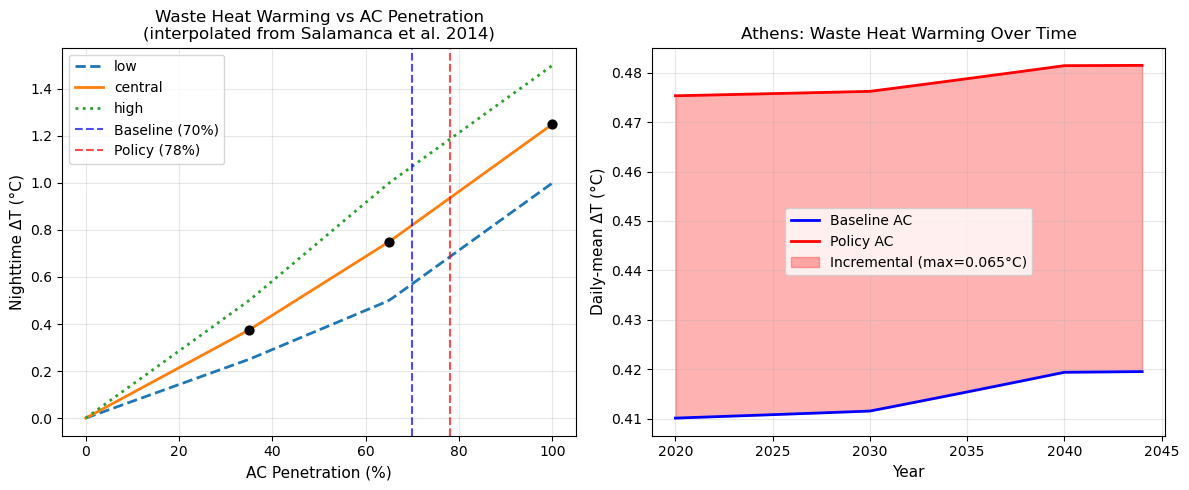

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/athens_wasteheat_timeseries.png


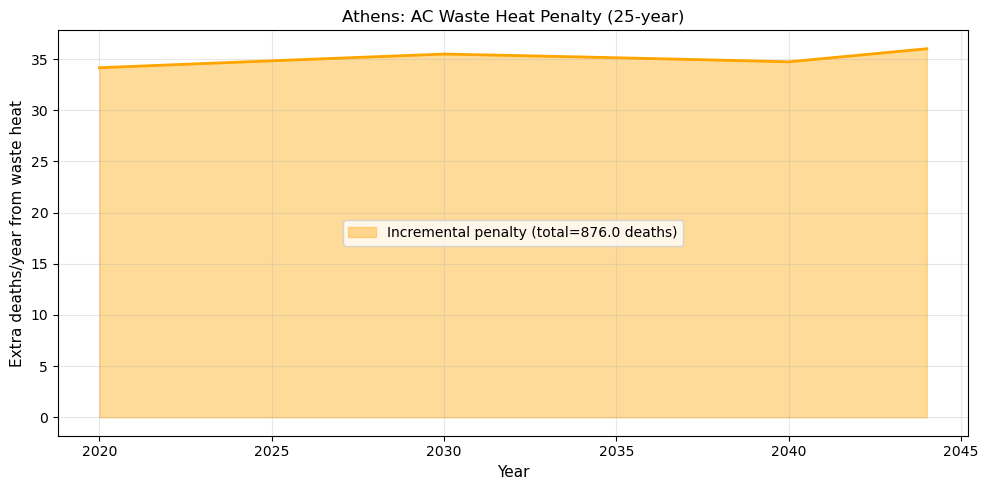

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/athens_wasteheat_penalty.png


In [81]:
# Plot 1: Waste heat warming vs AC penetration (Salamanca curve)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Interpolation curve
ax = axes[0]
pen_range = np.linspace(0, 1, 100)
for case, ls in [("low", "--"), ("central", "-"), ("high", ":")]:
    dT = dT_night_from_penetration(pen_range, case=case)
    ax.plot(pen_range * 100, dT, ls=ls, lw=2, label=case)

# Mark LUT points
for pen, vals in AC_WASTEHEAT_LUT.items():
    if pen > 0:
        ax.scatter([pen*100], [vals["central"]], color="black", s=40, zorder=5)

# Mark city baseline/policy
ax.axvline(pen_base_t[-1]*100, color="blue", ls="--", alpha=0.7, label=f"Baseline ({pen_base_t[-1]:.0%})")
ax.axvline(pen_pol_t[-1]*100, color="red", ls="--", alpha=0.7, label=f"Policy ({pen_pol_t[-1]:.0%})")

ax.set_xlabel("AC Penetration (%)", fontsize=11)
ax.set_ylabel("Nighttime ΔT (°C)", fontsize=11)
ax.set_title("Waste Heat Warming vs AC Penetration\n(interpolated from Salamanca et al. 2014)")
ax.legend()
ax.grid(alpha=0.3)

# Right: Time series
ax = axes[1]
ax.plot(YEARS_ALL, dT_dm_base_t, label="Baseline AC", color="blue", lw=2)
ax.plot(YEARS_ALL, dT_dm_pol_t, label="Policy AC", color="red", lw=2)
ax.fill_between(YEARS_ALL, dT_dm_base_t, dT_dm_pol_t, alpha=0.3, color="red",
                label=f"Incremental (max={dT_dm_inc_t.max():.3f}°C)")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Daily-mean ΔT (°C)", fontsize=11)
ax.set_title(f"{SLUG.title()}: Waste Heat Warming Over Time")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_wasteheat_timeseries.png", dpi=150)
plt.show()
print(f"Saved: {OUT / f'{SLUG}_wasteheat_timeseries.png'}")

# %%
# Plot 2: Penalty time series
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(YEARS_ALL, 0, warming_penalty_t, alpha=0.4, color="orange",
                label=f"Incremental penalty (total={warming_penalty_t.sum():.1f} deaths)")
ax.plot(YEARS_ALL, warming_penalty_t, color="orange", lw=2)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Extra deaths/year from waste heat", fontsize=11)
ax.set_title(f"{SLUG.title()}: AC Waste Heat Penalty (25-year)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_wasteheat_penalty.png", dpi=150)
plt.show()
print(f"Saved: {OUT / f'{SLUG}_wasteheat_penalty.png'}")

## 8. Cost-effectiveness (summary metrics, policy comparison)

This section assembles a compact AC-only summary: avoided deaths, coverage, electricity, cost inputs, and a simple undiscounted cost-effectiveness ratio. The full discounted comparison with EWS and trees is done in `NB08`.

### 8.1 Summary Metrics

In [82]:
print("="*70)
print("AVOIDED DEATHS SUMMARY")
print("="*70)

avoided_deaths_rows = []

# 1. Income-targeted policy from tab_ac
if 'tab_ac' in dir() and isinstance(tab_ac, pd.DataFrame):
    print("\n[Income-targeted policy] from tab_ac:")
    
    for year in tab_ac.index:
        if "overall" in tab_ac.columns:
            avoided = float(tab_ac.loc[year, "overall"])
        else:
            avoided = float(tab_ac.loc[year].sum())
        
        avoided_deaths_rows.append({
            "year": int(year),
            "policy": "income-targeted",
            "avoided_deaths": avoided,
        })
        print(f"    {year}: {avoided:.1f} avoided deaths")

# 2. Uniform policy
if 'rows_uniform' in dir() and isinstance(rows_uniform, list) and len(rows_uniform) > 0:
    print("\n[Uniform policy] from rows_uniform:")
    df_uniform = pd.DataFrame(rows_uniform)
    
    # finding the avoided deaths column
    avoided_col = None
    for col in ["avoided_uniform_vs_citycurrAC", "avoided_policy_vs_citycurrAC", "avoided"]:
        if col in df_uniform.columns:
            avoided_col = col
            break
    
    if avoided_col and "year" in df_uniform.columns:
        for year in YEARS_AC:
            sub = df_uniform[df_uniform["year"] == year]
            if len(sub) > 0:
                avoided = float(sub[avoided_col].sum())
                avoided_deaths_rows.append({
                    "year": int(year),
                    "policy": "uniform",
                    "avoided_deaths": avoided,
                })
                print(f"    {year}: {avoided:.1f} avoided deaths")

# display summary
if avoided_deaths_rows:
    avoided_df = pd.DataFrame(avoided_deaths_rows)
    
    print("\n" + "-"*50)
    avoided_pivot = avoided_df.pivot(index="year", columns="policy", values="avoided_deaths")
    display(avoided_pivot.round(1))
    
    print("\nCumulative avoided deaths (sum over anchor years):")
    for pol in avoided_df["policy"].unique():
        total = avoided_df[avoided_df["policy"] == pol]["avoided_deaths"].sum()
        print(f"  {pol}: {total:.1f} deaths")
    
    avoided_df.to_csv(OUT / f"{SLUG}_avoided_deaths_summary.csv", index=False)
    print(f"\n✓ Saved: {SLUG}_avoided_deaths_summary.csv")
else:
    print("\n No avoided deaths data found. Check Section 4.")

AVOIDED DEATHS SUMMARY

[Income-targeted policy] from tab_ac:
    2020: 61.9 avoided deaths
    2030: 66.6 avoided deaths
    2040: 67.3 avoided deaths
    2050: 75.9 avoided deaths

[Uniform policy] from rows_uniform:
    2020: 65.8 avoided deaths
    2030: 71.1 avoided deaths
    2040: 72.8 avoided deaths
    2050: 82.3 avoided deaths

--------------------------------------------------


policy,income-targeted,uniform
year,,
2020,61.900,65.800
2030,66.600,71.100
2040,67.300,72.800
2050,75.900,82.300



Cumulative avoided deaths (sum over anchor years):
  income-targeted: 271.6 deaths
  uniform: 292.0 deaths

✓ Saved: athens_avoided_deaths_summary.csv


### 8.2 Cost Parameters Summary


In [83]:
print("="*70)
print("COST PARAMETERS SUMMARY")
print("="*70)

print("\n1. AC Equipment Costs:")
print(f"   CAPEX per user:     €{AC_CAPEX_PER_USER:,.0f}")
print(f"   Maintenance:        {AC_MAINT_RATE:.0%} of CAPEX/year = €{maint_per_user_yr:.0f}/user/year")
print(f"   Lifetime:           {AC_LIFETIME_YEARS} years")

print("\n2. Electricity Costs:")
print(f"   Tariff:             €{TARIFF_EUR_PER_KWH:.2f}/kWh")

if 'per_user_city_by_year' in dir():
    print("\n   kWh per AC user (city-level):")
    for y in sorted(per_user_city_by_year.keys()):
        print(f"     {y}: {per_user_city_by_year[y]:,.0f} kWh/user/year")

print("\n3. CBA Parameters (for NB8):")
cba_cfg = cfg.get("cba", {})
R = cba_cfg.get("discount_rate", 0.03)
T = cba_cfg.get("horizon_years", 25)
print(f"   Discount rate:      {R:.1%}")
print(f"   Horizon:            {T} years")

COST PARAMETERS SUMMARY

1. AC Equipment Costs:
   CAPEX per user:     €500
   Maintenance:        5% of CAPEX/year = €25/user/year
   Lifetime:           10 years

2. Electricity Costs:
   Tariff:             €0.25/kWh

   kWh per AC user (city-level):
     2020: 988 kWh/user/year
     2030: 988 kWh/user/year
     2040: 988 kWh/user/year
     2050: 1,096 kWh/user/year

3. CBA Parameters (for NB8):
   Discount rate:      3.0%
   Horizon:            25 years


### 8.3 Policy Coverage Summary

In [84]:
print("="*70)
print("POLICY COVERAGE SUMMARY")
print("="*70)

coverage_rows = []

for k, year in enumerate(YEARS_AC):
    pop_grid = POP_GRID.get(year, pop_on_ref)
    m = CITY_MASK & np.isfinite(pop_grid) & (pop_grid > 0)
    
    def pwmean(arr):
        if arr is None:
            return np.nan
        valid = m & np.isfinite(arr)
        if not np.any(valid):
            return np.nan
        return float(np.average(arr[valid], weights=pop_grid[valid]))
    
    cov_base = coverage_base_3d[k] if coverage_base_3d is not None else None
    cov_pol = coverage_policy_3d[k] if coverage_policy_3d is not None else None
    cov_unif = coverage_uniform_3d[k] if 'coverage_uniform_3d' in dir() and coverage_uniform_3d is not None else None
    
    coverage_rows.append({
        "year": year,
        "baseline": pwmean(cov_base),
        "income-targeted": pwmean(cov_pol),
        "uniform": pwmean(cov_unif) if cov_unif is not None else np.nan,
    })

cov_df = pd.DataFrame(coverage_rows).set_index("year")

# Format as percentages for display
cov_display = cov_df.map(lambda x: f"{x:.1%}" if not pd.isna(x) else "-")
print("\nAC Coverage by Year:\n")
display(cov_display)

# Added users per year (for NB8 CBA)
print(f"\nAdded users by year (policy - baseline):")
for k, year in enumerate(YEARS_AC):
    pop_y = POP_GRID.get(year, pop_on_ref)
    m = CITY_MASK & np.isfinite(pop_y)
    
    base_users_y = float(np.nansum(coverage_base_3d[k][m] * pop_y[m]))
    pol_users_y = float(np.nansum(coverage_policy_3d[k][m] * pop_y[m]))
    added_y = pol_users_y - base_users_y
    
    print(f"  {year}: Baseline {base_users_y:,.0f} → Policy {pol_users_y:,.0f} (Δ = {added_y:,.0f})")

POLICY COVERAGE SUMMARY

AC Coverage by Year:



,baseline,income-targeted,uniform
year,,,
2020,68.6%,77.3%,77.3%
2030,68.8%,77.4%,77.5%
2040,69.9%,78.1%,78.2%
2050,69.9%,78.1%,78.2%



Added users by year (policy - baseline):
  2020: Baseline 2,347,432 → Policy 2,645,115 (Δ = 297,684)
  2030: Baseline 2,239,237 → Policy 2,520,099 (Δ = 280,862)
  2040: Baseline 2,209,496 → Policy 2,471,104 (Δ = 261,608)
  2050: Baseline 2,160,143 → Policy 2,414,900 (Δ = 254,756)


These user and cost summaries are not identical to the earlier policy-design diagnostics because they now use the year-specific population and coverage maps. That matters for CBA: capital costs are paid when users actually receive AC, maintenance follows the installed stock, and electricity use depends on the realized number and location of users in each year.

### 8.4 Preliminary cost-effectiveness

This is a simplified AC-only metric. `NB08` performs the full present-value calculation, includes waste-heat penalties, and compares AC against the other adaptation options on a common footing.

In [85]:
print("="*70)
print("PRELIMINARY COST-EFFECTIVENESS")
print("="*70)

if 'avoided_df' in dir() and len(avoided_df) > 0 and 'added_users' in dir():
    # using income-targeted policy
    income_data = avoided_df[avoided_df["policy"] == "income-targeted"]
    total_avoided = income_data["avoided_deaths"].sum()
    
    if total_avoided > 0:
        # simple annualized cost estimate
        capex_annual = (AC_CAPEX_PER_USER / AC_LIFETIME_YEARS) * added_users
        maint_annual = maint_per_user_yr * added_users
        avg_kwh = np.mean(list(per_user_city_by_year.values()))
        elec_annual = avg_kwh * TARIFF_EUR_PER_KWH * added_users
        total_annual = capex_annual + maint_annual + elec_annual
        
        avg_avoided_per_year = total_avoided / len(YEARS_AC)
        cost_per_death = total_annual / avg_avoided_per_year
        
        print("\nSimplified Annual Cost Estimate:")
        print(f"  Added users:           {added_users:,.0f}")
        print(f"  CAPEX (annualized):    €{capex_annual:,.0f}/year")
        print(f"  Maintenance:           €{maint_annual:,.0f}/year")
        print(f"  Electricity:           €{elec_annual:,.0f}/year")
        print(f"  ─────────────────────────────────")
        print(f"  Total annual:          €{total_annual:,.0f}/year")
        
        print(f"\nSimplified Effectiveness:")
        print(f"  Total avoided:         {total_avoided:.1f} deaths (over {len(YEARS_AC)} anchor years)")
        print(f"  Avg per year:          {avg_avoided_per_year:.1f} deaths/year")
        print(f"  Cost per death:        €{cost_per_death:,.0f}/death")
        
        print("\n Note: See NB8 for full PV calculation with:")
        print("   - 25-year horizon with dynamic coverage")
        print("   - Cohort-based CAPEX with replacement")
        print("   - Waste heat feedback penalty")
else:
    print("\n Cannot compute: avoided_df or added_users not available.")

PRELIMINARY COST-EFFECTIVENESS

 Cannot compute: avoided_df or added_users not available.


## 9. Outputs and exports (coverage maps, tables, diagnostics)

The final block checks that the main products needed by later notebooks and manuscript figures exist and, when necessary, writes any missing files.

### 9.1 Output file checklist

In [86]:
print("="*70)
print("OUTPUT FILE CHECKLIST")
print("="*70)

def check_file(path, desc):
    """Check if file exists and print status."""
    exists = path.exists() if hasattr(path, 'exists') else False
    status = "yes" if exists else "no"
    print(f"  {status} {desc}")
    if not exists:
        print(f"      Missing: {path}")
    return exists

all_ok = True

print("\n1. COVERAGE MAPS:")
all_ok &= check_file(OUT / f"ac_coverage_maps_{SLUG}.npz", "Coverage 3D arrays")
all_ok &= check_file(OUT / f"{SLUG}_muni_cov_yearly.csv", "Municipio coverage by year")

print("\n2. AVOIDED DEATHS:")
all_ok &= check_file(INT / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv", "Income-targeted avoided")
all_ok &= check_file(OUT / f"{SLUG}_avoided_deaths_summary.csv", "Summary table")

print("\n3. ELECTRICITY CONSUMPTION:")
all_ok &= check_file(INT / f"ac_per_user_city_{SLUG}.csv", "City-level kWh/user")
all_ok &= check_file(OUT / f"{SLUG}_cap_ac_consumption_summary.csv", "CAP consumption")
all_ok &= check_file(OUT / f"{SLUG}_cap_ac_consumption_map.geojson", "CAP GeoJSON")
all_ok &= check_file(OUT / f"{SLUG}_muni_ac_consumption_summary.csv", "Municipio consumption")
all_ok &= check_file(OUT / f"{SLUG}_muni_ac_consumption_map.geojson", "Municipio GeoJSON")

print("\n4. FEEDBACK PARAMETERS:")
all_ok &= check_file(INT / f"marginal_heat_deaths_perC_generic_{SLUG}.csv", "Marginal deaths (no AC)")
all_ok &= check_file(INT / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv", "Marginal deaths (current)")
all_ok &= check_file(INT / f"marginal_heat_deaths_perC_policyAC_{SLUG}.csv", "Marginal deaths (policy)")
all_ok &= check_file(INT / f"wasteheat_params_{SLUG}.json", "Waste heat params")
all_ok &= check_file(INT / f"feedback_summary_{SLUG}.csv", "Feedback summary")

print("\n5. COST PARAMETERS:")
all_ok &= check_file(INT / f"ac_cost_params_{SLUG}.json", "AC cost params")

OUTPUT FILE CHECKLIST

1. COVERAGE MAPS:
  yes Coverage 3D arrays
  yes Municipio coverage by year

2. AVOIDED DEATHS:
  yes Income-targeted avoided
  yes Summary table

3. ELECTRICITY CONSUMPTION:
  yes City-level kWh/user
  yes CAP consumption
  yes CAP GeoJSON
  yes Municipio consumption
  yes Municipio GeoJSON

4. FEEDBACK PARAMETERS:
  yes Marginal deaths (no AC)
  yes Marginal deaths (current)
  yes Marginal deaths (policy)
  yes Waste heat params
  yes Feedback summary

5. COST PARAMETERS:
  yes AC cost params


### 9.2 Save missing files

In [87]:
print("\n" + "="*70)
print("SAVING MISSING FILES")
print("="*70)

# Coverage maps + AC efficacy metadata for downstream notebooks.
coverage_path = OUT / f"ac_coverage_maps_{SLUG}.npz"
save_dict = {
    "years": np.array(YEARS_AC, dtype=int),
    "coverage_base_3d": coverage_base_3d,
    "EFF_DEFAULT": np.array([float(EFF_DEFAULT)], dtype="float32"),
    "EFF_BUCKETS_LT15": np.array([float(EFF_BUCKETS.get("<15", EFF_DEFAULT))], dtype="float32"),
    "EFF_BUCKETS_15_64": np.array([float(EFF_BUCKETS.get("15-64", EFF_DEFAULT))], dtype="float32"),
    "EFF_BUCKETS_65P": np.array([float(EFF_BUCKETS.get("65+", EFF_DEFAULT))], dtype="float32"),
}
if coverage_policy_3d is not None:
    save_dict["coverage_policy_3d"] = coverage_policy_3d
if 'coverage_uniform_3d' in dir() and coverage_uniform_3d is not None:
    save_dict["coverage_uniform_3d"] = coverage_uniform_3d
np.savez_compressed(coverage_path, **save_dict)
print(f" Refreshed: {coverage_path.name}")

# AC cost params
cost_params_path = INT / f"ac_cost_params_{SLUG}.json"
if not cost_params_path.exists():
    import json
    ac_cost_params = {
        "capex_per_user": AC_CAPEX_PER_USER,
        "maint_rate": AC_MAINT_RATE,
        "lifetime_years": AC_LIFETIME_YEARS,
        "tariff_eur_per_kwh": TARIFF_EUR_PER_KWH,
        "maint_per_user_yr": maint_per_user_yr,
    }
    with open(cost_params_path, "w") as f:
        json.dump(ac_cost_params, f, indent=2)
    print(f" Saved: {cost_params_path.name}")



SAVING MISSING FILES


 Refreshed: ac_coverage_maps_athens.npz


### 9.3 Final summary

In [88]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n1. POLICY SCENARIOS:")
print(f"   Baseline AC coverage")
print(f"   Income-targeted policy")
if 'coverage_uniform_3d' in dir() and coverage_uniform_3d is not None:
    print(f"   Uniform policy")

print(f"\n2. YEARS ANALYZED: {YEARS_AC}")

print(f"\n3. KEY RESULTS:")
# Coverage
if coverage_policy_3d is not None:
    cov_base = float(np.nanmean(coverage_base_3d[-1][CITY_MASK]))
    cov_pol = float(np.nanmean(coverage_policy_3d[-1][CITY_MASK]))
    print(f"   AC coverage ({YEARS_AC[-1]}): {cov_base:.1%} → {cov_pol:.1%}")

# Avoided deaths
if 'avoided_df' in dir() and len(avoided_df) > 0:
    total = avoided_df[avoided_df["policy"] == "income-targeted"]["avoided_deaths"].sum()
    print(f"   Avoided deaths (income-targeted): {total:.1f} (sum over anchor years)")

# Electricity
if 'city_summary' in dir() and isinstance(city_summary, pd.DataFrame):
    row = city_summary[city_summary["year"] == YEARS_AC[-1]]
    if len(row) > 0:
        gwh = row["city_total_GWh"].iloc[0]
        print(f"   City electricity ({YEARS_AC[-1]}): {gwh:.1f} GWh/year")

# Waste heat
if 'wasteheat_params' in dir() and isinstance(wasteheat_params, dict):
    dT = wasteheat_params.get('dT_incremental_dailymean', 0)
    print(f"   Waste heat ΔT (incremental): {dT:.3f}°C")

print(f"\n4. READY FOR NB8 (CBA): {'Okay, All files present' if all_ok else ' Problem: Some files missing'}")

print("\n" + "="*70)
print("NOTEBOOK 5 COMPLETE: AC Adaptation Policy")
print("="*70)


FINAL SUMMARY

1. POLICY SCENARIOS:
   Baseline AC coverage
   Income-targeted policy
   Uniform policy

2. YEARS ANALYZED: [2020, 2030, 2040, 2050]

3. KEY RESULTS:
   AC coverage (2050): 71.4% → 80.7%
   Avoided deaths (income-targeted): 271.6 (sum over anchor years)
   City electricity (2050): 2368.5 GWh/year
   Waste heat ΔT (incremental): 0.000°C

4. READY FOR NB8 (CBA): Okay, All files present

NOTEBOOK 5 COMPLETE: AC Adaptation Policy


### 9.4 Final mask consistency check

In [89]:
# Final region-mask consistency check.
# For Lisbon, muni_on_ref == zone_on_ref (no separate Municipi layer)
muni_on_ref_chk = muni_on_ref.copy()
muni_cov_chk = (muni_on_ref_chk > 0)
analysis_chk = CITY_MASK & muni_cov_chk

assert muni_on_ref_chk.shape == CITY_MASK.shape
assert muni_cov_chk.shape == CITY_MASK.shape
assert analysis_chk.shape == CITY_MASK.shape

assert not np.any((muni_on_ref_chk > 0) & (~muni_cov_chk)), "Leakage: labels outside muni_cov"
assert np.all(muni_on_ref_chk[analysis_chk] > 0), "Unlabeled pixels inside analysis mask"

print("✓ Region masks OK:",
      "unique IDs:", sorted(np.unique(muni_on_ref_chk[analysis_chk]))[:5], "...",
      "| analysis pixels:", int(analysis_chk.sum()))

✓ Region masks OK: unique IDs: [2, 3, 4, 5, 6] ... | analysis pixels: 60551
